# Experiment 1: one-dimensional double well

This notebook studies a symmetric quartic Gibbs target in the low-temperature
regime.  It compares local Langevin, kinetic Langevin, a raw compound-Poisson
jump process, and the Levy-score corrected compound-Poisson process.  The raw
jump process is a target-bias control; the corrected jump is the target-
compatible nonlocal method.

The central numerical result is an epsilon sweep.  As epsilon decreases,
ordinary Langevin becomes increasingly barrier limited, while the corrected
jump channel is designed to preserve the target well masses and maintain
inter-well communication.  Direct well-TV, distributional errors, weak
observables, form gaps, and generator diagnostics are reported.


## Scientific workflow and outputs

The notebook computes the potential, high-resolution target quadrature,
two-well masses, jump support, raw and corrected samplers, direct error
metrics, the low-temperature epsilon sweep, and output provenance.  Tables and
PDF figures are written under the four-experiment manuscript release tree.


In [1]:
import os, math, time, warnings, sys
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Callable

import numpy as np
import pandas as pd
import matplotlib
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import sparse
from scipy.linalg import eigh
from scipy.special import logsumexp
from scipy.stats import wasserstein_distance
try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except Exception:
    HAS_JOBLIB = False

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 350,
    "font.size": 9.5,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

PROFILE = os.environ.get("LEVY_PROFILE", "paperlite").lower()
assert PROFILE in {"smoke", "paperlite", "paper"}
print("LEVY_PROFILE =", PROFILE)

GLOBAL_SEED = 20260430

# NumPy 1.x / 2.x compatible trapezoidal rule helper.
_trapz = getattr(np, "trapezoid", np.trapz)


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def find_project_root(start=None):
    path = Path.cwd() if start is None else Path(start).resolve()
    while path.name != "levy-score-sampling-project" and path.parent != path:
        path = path.parent
    if path.name != "levy-score-sampling-project":
        raise RuntimeError("Could not locate levy-score-sampling-project from current working directory")
    return path

PROJECT_ROOT = find_project_root()
RELEASE_ROOT = ensure_dir(PROJECT_ROOT / "manuscript_clean_active" / "numerics" / "four_experiment_release")
RELEASE_TABLE_DIR = ensure_dir(RELEASE_ROOT / "tables")
RELEASE_LOG_DIR = ensure_dir(RELEASE_ROOT / "logs")
RELEASE_FIG_ROOT = ensure_dir(PROJECT_ROOT / "manuscript_clean_active" / "figures" / "four_experiment_release")
MAIN_FIG_DIR = ensure_dir(RELEASE_FIG_ROOT / "main_candidates")
APPENDIX_FIG_DIR = ensure_dir(RELEASE_FIG_ROOT / "appendix_candidates")
DIAGNOSTIC_FIG_DIR = ensure_dir(RELEASE_FIG_ROOT / "diagnostics")
MANUSCRIPT_FIG_DIR = DIAGNOSTIC_FIG_DIR
CANDIDATE_RESULT_DIR = RELEASE_ROOT
COMMON_DIR = RELEASE_ROOT / "common"
if str(COMMON_DIR) not in sys.path:
    sys.path.insert(0, str(COMMON_DIR))
from levy.one_d_density import (
# Canonical plotting and spectral-reference helpers are imported below.
    DensityDiagnosticConfig,
    binned_gaussian_kde_on_grid,
    binned_gaussian_kde_on_grid_with_diagnostics,
    central_interval_from_cdf,
    density_errors_on_grid,
    density_metric_bundle,
    estimate_kde_bias_floor,
    kde_histogram_bin_mass_l1,
    normalize_mixture_weights,
    summarize_density_diagnostics,
    target_local_scott_bandwidth,
)
def savefig(fig, outdir, name):
    outdir = ensure_dir(outdir)
    try:
        fig.tight_layout()
    except Exception:
        pass
    stem = str(name)
    if not stem.startswith(FIG_PREFIX):
        stem = FIG_PREFIX + stem
    pdf = outdir / f"{stem}.pdf"
    fig.savefig(pdf, bbox_inches="tight")
    print("saved", pdf.relative_to(PROJECT_ROOT))
    return pdf
def trapz_weights(x):
    x = np.asarray(x)
    w = np.empty_like(x, dtype=float)
    dx = np.diff(x)
    w[1:-1] = 0.5*(dx[:-1] + dx[1:])
    w[0] = 0.5*dx[0]
    w[-1] = 0.5*dx[-1]
    return w

def normalize_pdf_grid(x, logp):
    w = trapz_weights(x)
    lp = logp - np.max(logp)
    raw = np.exp(lp)
    Z = np.sum(raw*w)
    p = raw/Z
    return p, w, Z

def empirical_pdf_1d(samples, grid, clip_range=None):
    if clip_range is None:
        clip_range = (grid[0], grid[-1])
    hist, edges = np.histogram(samples, bins=len(grid)-1, range=clip_range, density=True)
    centers = 0.5*(edges[:-1]+edges[1:])
    return centers, hist

def empirical_cdf_on_grid(samples, grid):
    s = np.sort(samples)
    return np.searchsorted(s, grid, side='right') / max(1, len(s))

def cdf_from_pdf(x, p):
    w = trapz_weights(x)
    c = np.cumsum(p*w)
    c = c / c[-1]
    return c

def mmd_rbf_1d(x, y, bandwidth=0.7, max_points=1200, rng=None, block_size=128):
    rng = np.random.default_rng(123) if rng is None else rng
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    if len(x) > max_points:
        x = rng.choice(x, size=max_points, replace=False)
    if len(y) > max_points:
        y = rng.choice(y, size=max_points, replace=False)

    def kernel_mean(a, b):
        total = 0.0
        count = 0
        for i in range(0, len(a), block_size):
            aa = a[i:i+block_size, None]
            for j in range(0, len(b), block_size):
                bb = b[None, j:j+block_size]
                block = np.exp(-0.5*((aa-bb)/bandwidth)**2)
                total += float(block.sum())
                count += block.size
        return total / max(count, 1)

    return float(kernel_mean(x, x) + kernel_mean(y, y) - 2.0*kernel_mean(x, y))

def weighted_choice_indices(rng, probs, size):
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    return rng.choice(len(probs), size=size, p=probs)

def w1_empirical_to_target_cdf(samples, target_grid, target_cdf):
    """Approximate 1D W1 between empirical samples and the target CDF.

    This avoids an additional Monte Carlo reference-subsampling noise source.
    The target CDF is linearly interpolated on target_grid and extended by
    constants outside the displayed/grid interval.
    """
    samples = np.asarray(samples, dtype=float)
    grid = np.asarray(target_grid, dtype=float)
    cdf = np.asarray(target_cdf, dtype=float)
    if samples.size == 0:
        return np.nan
    pts = np.unique(np.concatenate([grid, samples[np.isfinite(samples)]]))
    if pts.size < 2:
        return 0.0
    F_emp = np.searchsorted(np.sort(samples), pts, side="right") / max(1, samples.size)
    F_tar = np.interp(pts, grid, cdf, left=0.0, right=1.0)
    return float(_trapz(np.abs(F_emp - F_tar), pts))

plt.rcParams.update({
    "figure.dpi": 135,
    "savefig.dpi": 300,
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.22,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def panel_label(ax, label, x=-0.12, y=1.06):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=12, fontweight="bold",
            va="top", ha="left")

def clean_axes(ax, grid=True):
    if grid:
        ax.grid(alpha=0.22, lw=0.55)
    ax.tick_params(length=3, width=0.7)
    return ax



from levy.plot_style import (
    METHOD_STYLES as CANONICAL_METHOD_STYLES,
    apply_plot_style,
    method_color as canonical_method_color,
    method_marker as canonical_method_marker,
)
from levy.spectral_references import add_spectral_reference_lines, write_reference_registry
apply_plot_style(plt)


LEVY_PROFILE = paperlite


In [2]:
# -------------------------------
# Plotting and statistical helpers
# -------------------------------
METHOD_ORDER = [
    "Langevin", "Kinetic-Langevin", "LSC-CP", "CP",
    "LSC-adjacent", "LSC-overlong", "CP-overlong",
    "LSC-connected", "LSC-disconnected", "LSC-wrong",
]
METHOD_COLORS = {name: style.color for name, style in CANONICAL_METHOD_STYLES.items()}
METHOD_MARKERS = {name: style.marker for name, style in CANONICAL_METHOD_STYLES.items()}
FIGSIZE_ROW = (13.2, 4.2)
FIGSIZE_GRID = (15.2, 8.6)
FIGSIZE_DIAGNOSTIC = (14.5, 4.2)

def method_color(method):
    return canonical_method_color(str(method))

def method_marker(method):
    return canonical_method_marker(str(method))

def mean_se_by_time(df, method, metric):
    sub = df[df.method == method].groupby("time")[metric].agg(["mean", "std", "count"])
    sub["std"] = sub["std"].fillna(0.0)
    sub["se"] = sub["std"] / np.sqrt(np.maximum(sub["count"], 1))
    return sub

def plot_metric_with_ci(ax, df, method, metric, *, logy=True, marker=None, lw=1.5, label=None, color=None, alpha_fill=0.12):
    sub = mean_se_by_time(df, method, metric)
    if len(sub) == 0:
        return None
    y = np.asarray(sub["mean"], dtype=float)
    lo = np.asarray(sub["mean"] - 2*sub["se"], dtype=float)
    hi = np.asarray(sub["mean"] + 2*sub["se"], dtype=float)
    c = color or method_color(method)
    mk = marker or method_marker(method)
    if logy:
        floor = max(1e-12, 1e-6*np.nanmax(np.abs(y)) if np.nanmax(np.abs(y)) > 0 else 1e-12)
        y = np.maximum(y, floor)
        lo = np.maximum(lo, floor)
        hi = np.maximum(hi, floor)
        ax.set_yscale("log")
    ax.plot(sub.index, y, marker=mk, ms=3, lw=lw, color=c, label=label or method)
    ax.fill_between(sub.index, lo, hi, alpha=alpha_fill, color=c, linewidth=0)
    return sub


SPECTRAL_REFERENCE_RECORDS = []
SPECTRAL_REFERENCE_EXPERIMENT = "double-well"


SPECTRAL_REFERENCE_RECORDS = []
SPECTRAL_REFERENCE_EXPERIMENT = "double-well"


SPECTRAL_REFERENCE_RECORDS = []
SPECTRAL_REFERENCE_EXPERIMENT = "double-well"

def add_rate_reference_lines(ax, df, metric, method, *, form_rate=None, abscissa_rate=None, tmax=None, logy=True):
    return add_spectral_reference_lines(
        ax,
        df,
        metric,
        method,
        form_rate=form_rate,
        abscissa_rate=abscissa_rate,
        records=SPECTRAL_REFERENCE_RECORDS,
        experiment=SPECTRAL_REFERENCE_EXPERIMENT,
        figure=f"{SPECTRAL_REFERENCE_EXPERIMENT}:{metric}:time-decay",
        tmax=tmax,
        logy=logy,
    )

def fit_observed_decay_rates(df, methods, metrics, *, t_min_frac=0.25, t_max_frac=0.85, min_points=4, floor_rel=1e-5):
    rows = []
    t0 = float(df.time.min())
    t1 = float(df.time.max())
    lo_t = t0 + t_min_frac*(t1-t0)
    hi_t = t0 + t_max_frac*(t1-t0)
    for method in methods:
        for metric in metrics:
            sub = mean_se_by_time(df, method, metric)
            if len(sub) == 0:
                rows.append(dict(method=method, metric=metric, r_obs=np.nan, r_obs_se=np.nan, n_fit=0, t_min=np.nan, t_max=np.nan))
                continue
            times = np.asarray(sub.index, dtype=float)
            y = np.asarray(sub["mean"], dtype=float)
            y_floor = max(1e-14, floor_rel*np.nanmax(np.abs(y)) if np.nanmax(np.abs(y)) > 0 else 1e-14)
            mask = (times >= lo_t) & (times <= hi_t) & np.isfinite(y) & (y > y_floor)
            if np.sum(mask) < min_points:
                mask = (times > t0) & np.isfinite(y) & (y > y_floor)
            if np.sum(mask) < min_points:
                rows.append(dict(method=method, metric=metric, r_obs=np.nan, r_obs_se=np.nan, n_fit=int(np.sum(mask)), t_min=np.nan, t_max=np.nan))
                continue
            x = times[mask]
            z = np.log(np.maximum(y[mask], y_floor))
            slope, intercept = np.polyfit(x, z, 1)
            resid = z - (slope*x + intercept)
            sxx = np.sum((x - x.mean())**2)
            sigma2 = np.sum(resid**2) / max(1, len(x)-2)
            slope_se = np.sqrt(sigma2 / max(sxx, 1e-300))
            rows.append(dict(method=method, metric=metric, r_obs=float(-slope), r_obs_se=float(slope_se),
                             n_fit=int(len(x)), t_min=float(x.min()), t_max=float(x.max())))
    return pd.DataFrame(rows)



def fit_seed_level_decay_rates(df, methods, metrics, *, t_min_frac=0.25, t_max_frac=0.85, min_points=4, floor_rel=1e-5):
    """Fit log-linear decay separately for each seed, then summarize across seeds.

    The ordinary curve-level fit treats time points as independent.  This seed-level
    summary is a more honest uncertainty diagnostic for finite-seed Monte Carlo curves.
    """
    seed_rows = []
    summary_rows = []
    t0 = float(df.time.min())
    t1 = float(df.time.max())
    lo_t = t0 + t_min_frac*(t1-t0)
    hi_t = t0 + t_max_frac*(t1-t0)
    for method in methods:
        method_df = df[df.method == method]
        for metric in metrics:
            per_rates = []
            for seed, sub_seed in method_df.groupby("seed"):
                sub_seed = sub_seed.sort_values("time")
                times = np.asarray(sub_seed["time"], dtype=float)
                y = np.asarray(sub_seed[metric], dtype=float)
                if len(times) == 0 or not np.any(np.isfinite(y)):
                    seed_rows.append(dict(method=method, metric=metric, seed=seed, r_obs_seed=np.nan,
                                          n_fit=0, t_min=np.nan, t_max=np.nan))
                    continue
                y_floor = max(1e-14, floor_rel*np.nanmax(np.abs(y)) if np.nanmax(np.abs(y)) > 0 else 1e-14)
                mask = (times >= lo_t) & (times <= hi_t) & np.isfinite(y) & (y > y_floor)
                if np.sum(mask) < min_points:
                    mask = (times > t0) & np.isfinite(y) & (y > y_floor)
                if np.sum(mask) < min_points:
                    seed_rows.append(dict(method=method, metric=metric, seed=seed, r_obs_seed=np.nan,
                                          n_fit=int(np.sum(mask)), t_min=np.nan, t_max=np.nan))
                    continue
                x = times[mask]
                z = np.log(np.maximum(y[mask], y_floor))
                slope, intercept = np.polyfit(x, z, 1)
                r_seed = float(-slope)
                per_rates.append(r_seed)
                seed_rows.append(dict(method=method, metric=metric, seed=seed, r_obs_seed=r_seed,
                                      n_fit=int(len(x)), t_min=float(x.min()), t_max=float(x.max())))
            rates = np.asarray([r for r in per_rates if np.isfinite(r)], dtype=float)
            if rates.size == 0:
                summary_rows.append(dict(method=method, metric=metric, r_obs=np.nan, r_obs_se=np.nan,
                                         r_obs_seed_std=np.nan, n_seed_fit=0, t_min=lo_t, t_max=hi_t))
            else:
                seed_std = float(np.std(rates, ddof=1)) if rates.size > 1 else np.nan
                seed_se = float(seed_std/np.sqrt(rates.size)) if rates.size > 1 else np.nan
                summary_rows.append(dict(method=method, metric=metric, r_obs=float(np.mean(rates)),
                                         r_obs_se=seed_se, r_obs_seed_std=seed_std,
                                         n_seed_fit=int(rates.size), t_min=lo_t, t_max=hi_t))
    return pd.DataFrame(summary_rows), pd.DataFrame(seed_rows)

def make_rng_seed(*items):
    ss = np.random.SeedSequence([int(abs(x)) % (2**32-1) for x in items])
    return int(ss.generate_state(1)[0])


# Canonical method styles are supplied by levy.plot_style.


## Numerical protocol

The numerical protocol is organized around the Dirichlet-form gap.  In this notebook it is used as a conservative $$L^2(\mu)$$ reference rate for the symmetric diagonal form.  It is not claimed to be the exact finite-time rate of Wasserstein, CDF, mode-TV, weak-error, or other empirical metrics.

The generator abscissa is a finite-dimensional diagnostic for the discretized nonreversible generator.  It is reported together with row-sum error, stationary residual, stationary bias, negative-mass diagnostics for the stationary vector, and domain/grid sensitivity.  It should be read as a numerical diagnostic, not as a theorem-level continuous-generator rate.

The observed rate is a finite-time, metric-dependent Monte Carlo summary from a log-linear fit.  Its reported standard error is a regression diagnostic, not a full Monte Carlo confidence interval.  The shaded metric curves remain the main seed-level uncertainty visualization.

Reference lines on empirical curves are visual comparisons only: they start from the same empirical initial value as the plotted metric and should not be read as rigorous upper or lower bounds for that empirical metric.


### Interpretation guardrails

The numerical protocol is organized around the Dirichlet-form gap, which is used as a conservative $$L^2(\mu)$$ reference rate for the diagonal form.  It is not asserted to be the exact finite-time decay rate of Wasserstein, CDF, mode-TV, weak-error, or any prescribed initial cloud.

The finite-dimensional generator abscissa is a diagnostic for the discretized nonreversible pseudo-generator.  It should be interpreted only together with the stationary residual, stationary-bias, negative-mass, grid, and domain diagnostics.

The fitted observed rate is metric-dependent and finite-time.  Its standard error in the compact comparison table is computed across seed-level fitted slopes when available; it is not a theorem-level confidence interval for the Markov semigroup.


In [3]:
# -------------------------------
# 1D jump law, Levy score, gap
# -------------------------------
@dataclass
class ShellJump1D:
    a: float
    h: float
    lam: float
    quad_r: int = 7
    name: str = "shell"

    def atoms(self):
        # Gauss--Legendre quadrature for the two shell intervals.
        z, w = np.polynomial.legendre.leggauss(self.quad_r)
        pos = self.a + self.h * z
        neg = -self.a + self.h * z
        # Each interval has mass 1/2; GL weights sum to 2.
        rs = np.concatenate([pos, neg])
        ws = np.concatenate([0.25*w, 0.25*w])
        ws = ws / ws.sum()
        return rs.astype(float), ws.astype(float)

    def density_on_grid(self, rgrid):
        r = np.asarray(rgrid)
        return ((np.abs(np.abs(r) - self.a) <= self.h).astype(float) / (4*self.h))

    def sample_jumps(self, rng, size):
        # Exact shell sampling, not quadrature sampling.
        signs = rng.choice(np.array([-1.0, 1.0]), size=size)
        mags = rng.uniform(self.a-self.h, self.a+self.h, size=size)
        return signs*mags

def levy_score_1d_grid(xgrid, logp_fn, jump: ShellJump1D, theta_n=24, log_clip=None, score_clip=None):
    """Evaluate the 1D Levy-score correction on a grid.

    log_clip=None applies only the floating-point overflow guard.  Passing a
    smaller log_clip is score-changing truncation and is recorded explicitly.
    """
    x = np.asarray(xgrid)
    zt, wt = np.polynomial.legendre.leggauss(theta_n)
    theta = 0.5*(zt+1.0); wt=0.5*wt
    rs, wr = jump.atoms()
    lp_x = logp_fn(x)
    S = np.zeros_like(x)
    score_changing_clip_count = 0
    overflow_guard_clip_count = 0
    total_count = 0
    max_log_ratio = 0.0
    float_log_clip = float(np.log(np.finfo(float).max) - 2.0)
    effective_log_clip = float_log_clip if log_clip is None else min(float(log_clip), float_log_clip)
    for r, pr in zip(rs, wr):
        acc = np.zeros_like(x)
        for th, wth in zip(theta, wt):
            dlog = logp_fn(x - th*r) - lp_x
            max_log_ratio = max(max_log_ratio, float(np.max(np.abs(dlog))))
            if log_clip is not None:
                score_changing_clip_count += int(np.sum(np.abs(dlog) > effective_log_clip))
            overflow_guard_clip_count += int(np.sum(np.abs(dlog) > float_log_clip))
            total_count += dlog.size
            ratio = np.exp(np.clip(dlog, -effective_log_clip, effective_log_clip))
            acc += wth * r * ratio
        S += pr*acc
    rawS = -jump.lam*S
    if score_clip is None:
        S = rawS
        clip_fraction = 0.0
    else:
        S = np.clip(rawS, -score_clip, score_clip)
        clip_fraction = float(np.mean(np.abs(rawS) > score_clip))
    logratio_clip_fraction = score_changing_clip_count/max(1,total_count)
    overflow_fraction = overflow_guard_clip_count/max(1,total_count)
    return S, {"score_clip_fraction": clip_fraction,
               "logratio_clip_fraction": logratio_clip_fraction,
               "score_changing_logratio_clip_fraction": logratio_clip_fraction,
               "overflow_guard_logratio_clip_fraction": overflow_fraction,
               "effective_log_clip": float(effective_log_clip),
               "max_score_abs": float(np.max(np.abs(rawS))) if rawS.size else 0.0,
               "max_log_ratio": float(max_log_ratio),
               "score_clipping_warning": bool(clip_fraction > 1e-3),
               "logratio_clipping_warning": bool(logratio_clip_fraction > 1e-3)}

def interp_shift_matrix_1d(x, r):
    """
    Sparse matrix T_r such that (T_r f)_i approximates f(x_i + r)
    by linear interpolation. Values outside the computational interval
    are clamped to the nearest boundary. The interval is chosen so that
    boundary mass is negligible; boundary diagnostics are reported.
    """
    x = np.asarray(x)
    n = len(x)
    y = x + r
    idx = np.searchsorted(x, y) - 1
    idx = np.clip(idx, 0, n-2)
    x0 = x[idx]; x1 = x[idx+1]
    t = np.clip((y-x0)/(x1-x0), 0.0, 1.0)
    rows = np.repeat(np.arange(n), 2)
    cols = np.ravel(np.column_stack([idx, idx+1]))
    data = np.ravel(np.column_stack([1-t, t]))
    return sparse.csr_matrix((data, (rows, cols)), shape=(n,n))

def full_gap_1d_form(logp_fn, eps, x_min, x_max, N=360, jump: Optional[ShellJump1D]=None, tail_trim=1e-10):
    """
    Compute full 1D form gap using H = M^{-1/2} K M^{-1/2}.
    Returns lambda_2, diagnostics, eigenvalues.
    """
    x_full = np.linspace(x_min, x_max, N)
    p_full, dxw_full, _ = normalize_pdf_grid(x_full, logp_fn(x_full))
    mu_full = p_full * dxw_full
    cdf = np.cumsum(mu_full); cdf /= cdf[-1]
    keep = (cdf >= tail_trim/2) & (cdf <= 1-tail_trim/2)
    if keep.sum() < 0.8*N:
        keep = mu_full > (np.max(mu_full)*1e-13)
    if keep.sum() < 20:
        keep = np.ones_like(mu_full, dtype=bool)
    x = x_full[keep]
    p, dxw, _ = normalize_pdf_grid(x, logp_fn(x))
    mu = p*dxw
    n = len(x)
    h = np.diff(x)
    K = sparse.csr_matrix((n,n), dtype=float)

    # Diffusion stiffness: eps int |f'|^2 p dx.
    diag = np.zeros(n); off = np.zeros(n-1)
    pmid = 0.5*(p[:-1]+p[1:])
    c = eps * pmid / h
    diag[:-1] += c; diag[1:] += c; off -= c
    Kdiff = sparse.diags([off, diag, off], offsets=[-1,0,1], format="csr")
    K = K + Kdiff

    boundary_jump_mass = 0.0
    if jump is not None and jump.lam > 0:
        rs, wr = jump.atoms()
        I = sparse.identity(n, format="csr")
        Mdiag = sparse.diags(mu, format="csr")
        for r, pr in zip(rs, wr):
            y = x + r
            boundary_jump_mass += float(pr * np.sum(mu[(y < x[0]) | (y > x[-1])]))
            T = interp_shift_matrix_1d(x, r)
            D = T - I
            K = K + (0.5*jump.lam*pr) * (D.T @ Mdiag @ D)

    invsqrt = 1/np.sqrt(np.maximum(mu, 1e-300))
    H = sparse.diags(invsqrt) @ K @ sparse.diags(invsqrt)
    H = 0.5*(H + H.T)
    Hd = H.toarray()
    evals, evecs = eigh(Hd)
    evals = np.maximum(evals, 0.0)
    gap = float(evals[1])
    z = evecs[:,1]
    rq = float(z @ (Hd @ z) / (z @ z))
    resid = float(np.linalg.norm(Hd @ z - gap*z) / max(1.0, abs(gap)))
    diag = {
        "N_input": N, "N_active": n,
        "x_min_active": float(x[0]), "x_max_active": float(x[-1]),
        "retained_mass_before_renorm": float(mu_full[keep].sum()),
        "boundary_jump_mass_proxy": boundary_jump_mass,
        "gap": gap, "rayleigh": rq, "residual": resid,
        "lambda0": float(evals[0]), "lambda2": gap, "lambda3": float(evals[2]) if len(evals)>2 else np.nan,
        "lambda4": float(evals[3]) if len(evals)>3 else np.nan,
        "lambda5": float(evals[4]) if len(evals)>4 else np.nan,
        "ratio32": float(evals[2]/evals[1]) if len(evals)>2 and evals[1] > 0 else np.nan,
        "ratio43": float(evals[3]/evals[2]) if len(evals)>3 and evals[2] > 0 else np.nan,
        "ratio54": float(evals[4]/evals[3]) if len(evals)>4 and evals[3] > 0 else np.nan,
    }
    return gap, diag, evals[:8], x, mu

def run_gap_convergence(logp_fn, eps, interval, Ns, jump_map):
    rows = []
    for name, jump in jump_map.items():
        for N in Ns:
            t0=time.time()
            gap, diag, evals, _, _ = full_gap_1d_form(logp_fn, eps, interval[0], interval[1], N=N, jump=jump)
            diag.update({"method": name, "elapsed_sec": time.time()-t0})
            rows.append(diag)
    return pd.DataFrame(rows)

def choose_main_gaps(gap_df):
    # Robust: no float filtering, no empty slices. Choose largest N available for each method.
    out = {}
    for method, sub in gap_df.groupby("method"):
        sub = sub.dropna(subset=["gap"]).sort_values(["N_input"])
        if len(sub)==0:
            out[method] = np.nan
        else:
            out[method] = float(sub.iloc[-1]["gap"])
    return out

def make_initial_cloud_1d(rng, center, scale, n, clip):
    x0 = center + scale*rng.standard_normal(n)
    return np.clip(x0, clip[0], clip[1])

def apply_compound_poisson_jumps_1d(x, jump, rng, dt):
    """Vectorized compound-Poisson jump accumulation for 1D particles.

    This is algebraically identical to looping over particles and summing their
    independent jumps, but avoids the Python-level per-particle loop.
    """
    nj = rng.poisson(jump.lam * dt, size=x.shape[0])
    total = int(nj.sum())
    if total <= 0:
        return x, nj
    owners = np.repeat(np.arange(x.shape[0]), nj)
    jumps = jump.sample_jumps(rng, total)
    incr = np.bincount(owners, weights=jumps, minlength=x.shape[0])
    return x + incr, nj

def safety_clip_1d(x, method, clip):
    """Safety clip for explicit discretizations.

    The returned fraction is a diagnostic of whether the computational
    domain is wide enough. In reported runs it should be essentially zero.
    """
    y = np.clip(x, *clip)
    return y, float(np.mean(y != x))


In [4]:
OUTDIR = ensure_dir(CANDIDATE_RESULT_DIR / "doublewell")
FIGDIR = MANUSCRIPT_FIG_DIR
FIG_PREFIX = "doublewell_"
TABDIR = ensure_dir(RELEASE_TABLE_DIR / "01_double_well")

if PROFILE == "smoke":
    CFG = dict(n_particles=40, n_steps=20, dt=0.0035, n_seeds=1, record_every=5,
               gap_Ns=[30], gap_interval=(-5.0,5.0), grid_N=100, theta_n=4, quad_r=3, kinetic_gamma=1.3, kinetic_mass=0.02, n_jobs=1)
elif PROFILE == "paperlite":
    CFG = dict(n_particles=2200, n_steps=1600, dt=0.003, n_seeds=4, record_every=20,
               gap_Ns=[180,260,360], gap_interval=(-5.0,5.0), grid_N=900, theta_n=20, quad_r=7, kinetic_gamma=1.3, kinetic_mass=0.02, n_jobs=1)
else:
    CFG = dict(n_particles=9000, n_steps=5000, dt=0.0025, n_seeds=8, record_every=25,
               gap_Ns=[240,360,520,700], gap_interval=(-6.0,6.0), grid_N=1600, theta_n=32, quad_r=9, kinetic_gamma=1.3, kinetic_mass=0.02, n_jobs=min(6, os.cpu_count() or 1))

sigma = 0.50
eps = sigma**2/2
x_clip = (-6.0, 6.0)
target_grid = np.linspace(x_clip[0], x_clip[1], CFG["grid_N"])

def V(x):
    x = np.asarray(x)
    return 0.25*x**4 - 0.5*x**2

def dV(x):
    x = np.asarray(x)
    return x**3 - x

def logp(x):
    """Unnormalized log density; additive constants cancel in ratios and grid normalization."""
    return -V(np.asarray(x))/eps

def grad_logp(x):
    return -dV(np.asarray(x))/eps

p_grid, dxw_grid, _ = normalize_pdf_grid(target_grid, logp(target_grid))
cdf_grid = cdf_from_pdf(target_grid, p_grid)
assert np.isclose(np.sum(p_grid * dxw_grid), 1.0, atol=2e-6)
assert np.all(np.diff(cdf_grid) >= -1e-12)
assert np.isclose(cdf_grid[-1], 1.0, atol=1e-12)
pd.DataFrame([dict(experiment="double-well", target_integral=float(np.sum(p_grid * dxw_grid)),
                   cdf_endpoint=float(cdf_grid[-1]), grid_left=float(target_grid[0]),
                   grid_right=float(target_grid[-1]), grid_N=int(len(target_grid)))]).to_csv(
    TABDIR / "doublewell_target_density_checks.csv", index=False
)
target_sampler_rng = np.random.default_rng(GLOBAL_SEED+7)
target_samples = target_grid[weighted_choice_indices(target_sampler_rng, p_grid*dxw_grid, 200000 if PROFILE!="smoke" else 20000)]

# Main jump law: shell centered at well distance D=2.
jump_main = ShellJump1D(a=2.0, h=0.22, lam=1.0, quad_r=CFG["quad_r"], name="LSC shell a=2")
print("eps=",eps, "jump_main=", jump_main)

eps= 0.125 jump_main= ShellJump1D(a=2.0, h=0.22, lam=1.0, quad_r=7, name='LSC shell a=2')


## 1. Target density, CDF, and jump measure visualization

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig01_target_cdf_nu.pdf


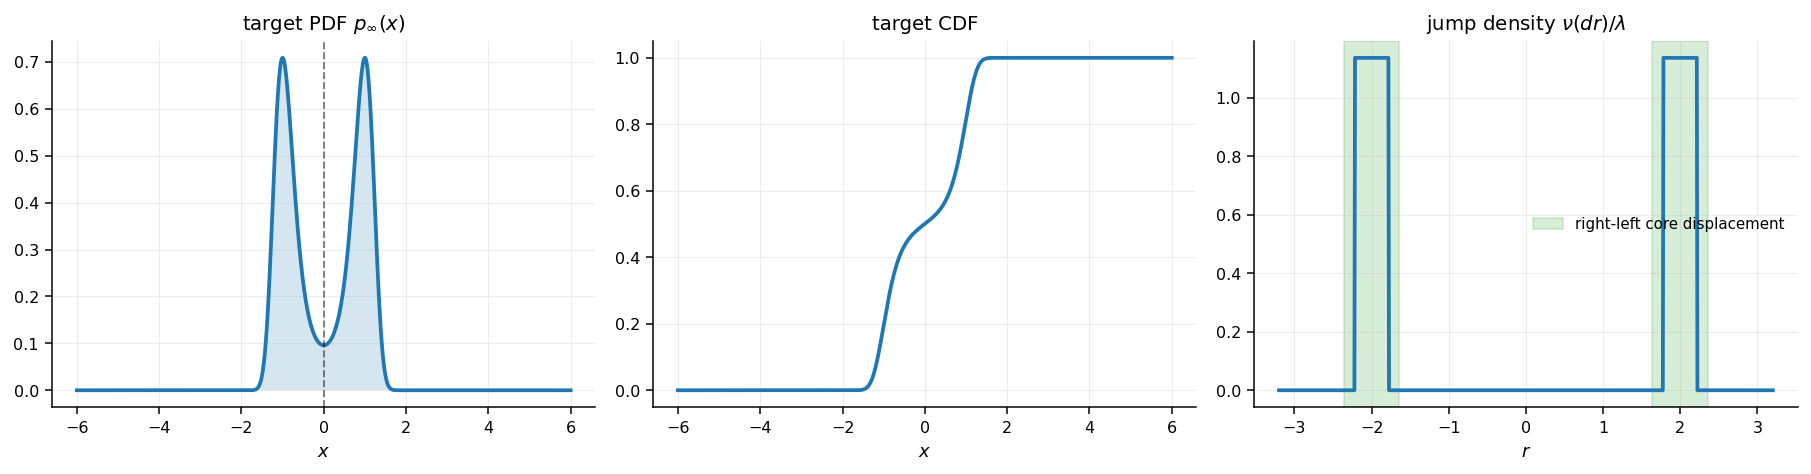

In [5]:
rgrid = np.linspace(-3.2,3.2,800)
fig, ax = plt.subplots(1,3,figsize=(13.5,3.6))
ax[0].plot(target_grid, p_grid, lw=2)
ax[0].fill_between(target_grid, 0, p_grid, alpha=0.18)
ax[0].axvline(0, color="k", lw=1, ls="--", alpha=0.5)
ax[0].set_title("target PDF $p_\\infty(x)$")
ax[0].set_xlabel("$x$")

ax[1].plot(target_grid, cdf_grid, lw=2)
ax[1].set_title("target CDF")
ax[1].set_xlabel("$x$")

ax[2].plot(rgrid, jump_main.density_on_grid(rgrid), lw=2)
# core displacement interval for r_c=0.18
rc = 0.18
ax[2].axvspan(2-2*rc, 2+2*rc, color="tab:green", alpha=0.18, label="right-left core displacement")
ax[2].axvspan(-2-2*rc, -2+2*rc, color="tab:green", alpha=0.18)
ax[2].set_title(r"jump density $\nu(dr)/\lambda$")
ax[2].set_xlabel("$r$")
ax[2].legend(fontsize=8)
savefig(fig, FIGDIR, "fig01_target_cdf_nu")
plt.show()

## 2. Full form spectral gaps: convergence and diagnostics

,method,N_input,N_active,gap,rayleigh,residual,retained_mass_before_renorm,boundary_jump_mass_proxy,elapsed_sec
0,Langevin,180,78,0.056997,0.056997,6.990610e-14,1.0,0.000000,0.007204
1,Langevin,260,114,0.056904,0.056904,1.475529e-13,1.0,0.000000,0.001914
2,Langevin,360,158,0.056863,0.056863,2.796138e-13,1.0,0.000000,0.004190
3,LSC-CP,180,78,1.002184,1.002185,1.033409e-04,1.0,0.483808,0.006778
4,LSC-CP,260,114,1.001465,1.001443,1.486866e-04,1.0,0.480856,0.008014
5,LSC-CP,360,158,1.001094,1.001200,9.754222e-04,1.0,0.479687,0.012652


Main gaps: {'LSC-CP': 1.0010940096629284, 'Langevin': 0.056862783488933345}


,method,N_previous,N_finest,gap_previous,gap_finest,gap_relative_change_last_two
0,LSC-CP,260,360,1.001465,1.001094,0.000371
1,Langevin,260,360,0.056904,0.056863,0.000720


,method,x_min,x_max,N_input,N_active,gap,residual,boundary_jump_mass_proxy
0,Langevin,-4.5,4.5,360,176,0.056854,3.116905e-13,0.000000
1,LSC-CP,-4.5,4.5,360,176,1.000887,2.989512e-03,0.479445
2,Langevin,-5.0,5.0,360,158,0.056863,2.796138e-13,0.000000
3,LSC-CP,-5.0,5.0,360,158,1.001094,9.754222e-04,0.479687
4,Langevin,-6.0,6.0,360,132,0.056882,1.583649e-13,0.000000
5,LSC-CP,-6.0,6.0,360,132,1.001406,4.901252e-04,0.479228


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig02c_form_gap_domain_sensitivity.pdf


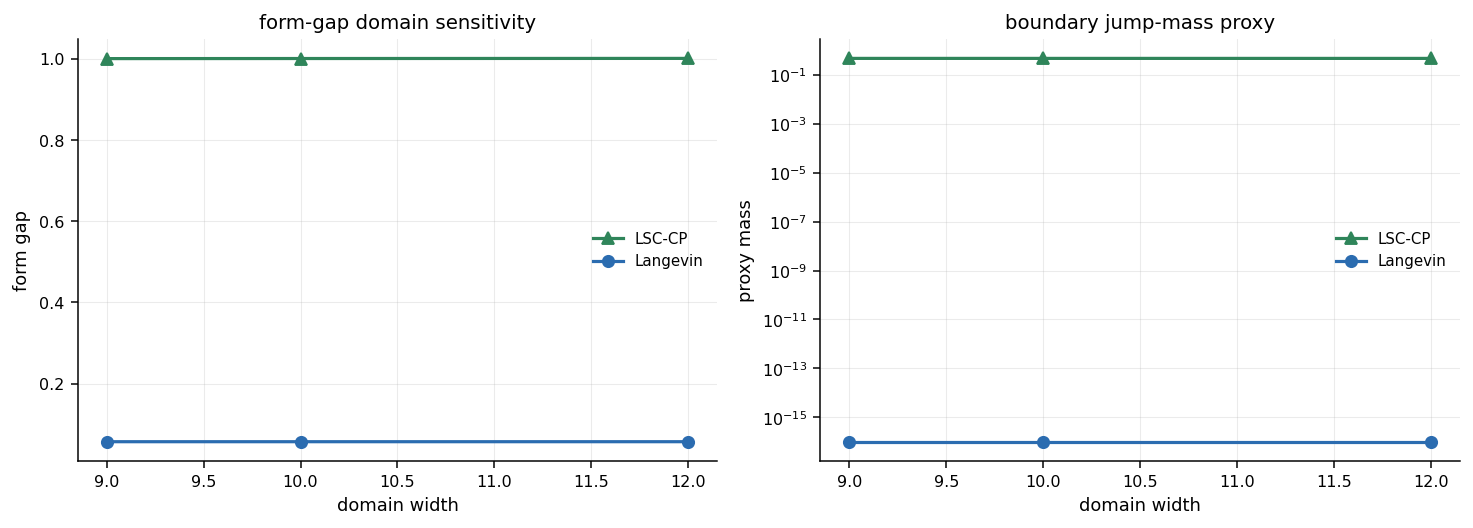

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig02_gap_convergence.pdf


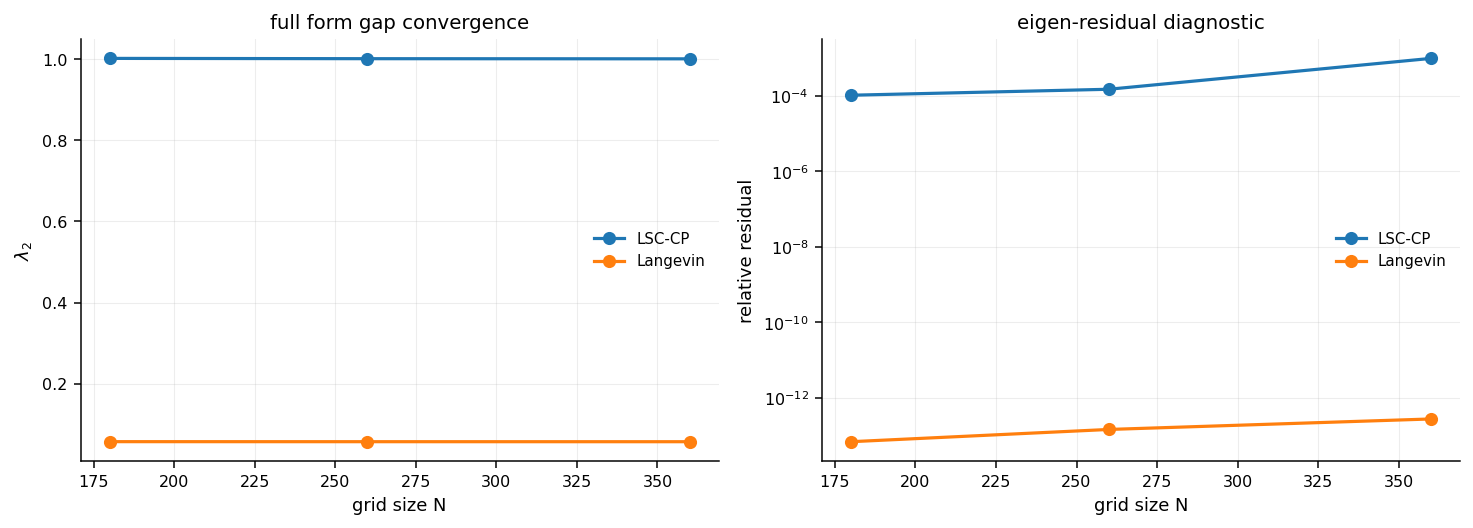

In [6]:
gap_conv = run_gap_convergence(
    logp_fn=logp, eps=eps, interval=CFG["gap_interval"], Ns=CFG["gap_Ns"],
    jump_map={"Langevin": None, "LSC-CP": jump_main}
)
gap_conv.to_csv(TABDIR/"doublewell_gap_convergence.csv", index=False)
display(gap_conv[["method","N_input","N_active","gap","rayleigh","residual","retained_mass_before_renorm","boundary_jump_mass_proxy","elapsed_sec"]])
gap_main = choose_main_gaps(gap_conv)
print("Main gaps:", gap_main)

# Last-two-grid relative change table: a lightweight discretization self-consistency check.
def gap_last_two_relative_change(gap_df):
    rows = []
    for method, sub in gap_df.groupby("method"):
        sub = sub.dropna(subset=["gap"]).sort_values("N_input")
        if len(sub) >= 2:
            prev = float(sub.iloc[-2]["gap"])
            finest = float(sub.iloc[-1]["gap"])
            rel = abs(finest - prev) / max(abs(finest), 1e-14)
            rows.append(dict(method=method, N_previous=int(sub.iloc[-2]["N_input"]),
                             N_finest=int(sub.iloc[-1]["N_input"]),
                             gap_previous=prev, gap_finest=finest,
                             gap_relative_change_last_two=float(rel)))
        elif len(sub) == 1:
            rows.append(dict(method=method, N_previous=np.nan, N_finest=int(sub.iloc[-1]["N_input"]),
                             gap_previous=np.nan, gap_finest=float(sub.iloc[-1]["gap"]),
                             gap_relative_change_last_two=np.nan))
    return pd.DataFrame(rows)

gap_self_consistency = gap_last_two_relative_change(gap_conv)
gap_self_consistency.to_csv(TABDIR / "doublewell_gap_last_two_relative_change.csv", index=False)
display(gap_self_consistency)



def run_form_gap_domain_sensitivity(label_prefix, logp_fn, eps, domain_list, N, jump_map):
    rows = []
    for domain in domain_list:
        for method, jump in jump_map.items():
            gap, diag, *_ = full_gap_1d_form(logp_fn, eps, domain[0], domain[1], N=int(N), jump=jump)
            row = dict(diag)
            row.update(dict(method=method, x_min=float(domain[0]), x_max=float(domain[1]), N=int(N), gap=float(gap)))
            rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(TABDIR / f"{label_prefix}form_gap_domain_sensitivity.csv", index=False)
    display(df[["method", "x_min", "x_max", "N_input", "N_active", "gap", "residual", "boundary_jump_mass_proxy"]])
    return df

if PROFILE == "smoke":
    gap_domain_list = [CFG["gap_interval"]]
else:
    gap_domain_list = [(-4.5, 4.5), (-5.0, 5.0), (-6.0, 6.0)]

gap_domain_sensitivity = run_form_gap_domain_sensitivity(
    "doublewell_", logp, eps, gap_domain_list, max(CFG["gap_Ns"]),
    {"Langevin": None, "LSC-CP": jump_main}
)



def plot_form_gap_domain_sensitivity(df, label_prefix):
    """Appendix-style visualization of the form-gap domain sensitivity table."""
    if df is None or len(df) == 0:
        return
    d = df.copy()
    d["domain_width"] = d["x_max"] - d["x_min"]
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for method, sub in d.groupby("method"):
        sub = sub.sort_values("domain_width")
        ax[0].plot(sub["domain_width"], sub["gap"], marker=method_marker(method), color=method_color(method), label=method)
        if "boundary_jump_mass_proxy" in sub.columns:
            ax[1].semilogy(sub["domain_width"], np.maximum(sub["boundary_jump_mass_proxy"], 1e-16), marker=method_marker(method), color=method_color(method), label=method)
    ax[0].set_title("form-gap domain sensitivity")
    ax[0].set_xlabel("domain width")
    ax[0].set_ylabel("form gap")
    ax[1].set_title("boundary jump-mass proxy")
    ax[1].set_xlabel("domain width")
    ax[1].set_ylabel("proxy mass")
    for a in ax:
        a.grid(True, alpha=0.25)
        a.legend(fontsize=8)
    savefig(fig, FIGDIR, f"{label_prefix}fig02c_form_gap_domain_sensitivity")
    plt.show()

plot_form_gap_domain_sensitivity(gap_domain_sensitivity, "doublewell_")


fig, ax = plt.subplots(1,2,figsize=(11,4))
for method, sub in gap_conv.groupby("method"):
    sub = sub.sort_values("N_input")
    ax[0].plot(sub.N_input, sub.gap, marker="o", label=method)
    ax[1].semilogy(sub.N_input, np.maximum(sub.residual,1e-16), marker="o", label=method)
ax[0].set_title("full form gap convergence")
ax[0].set_xlabel("grid size N")
ax[0].set_ylabel(r"$\lambda_2$")
ax[1].set_title("eigen-residual diagnostic")
ax[1].set_xlabel("grid size N")
ax[1].set_ylabel("relative residual")
for a in ax: a.legend()
savefig(fig, FIGDIR, "fig02_gap_convergence")
plt.show()


## 2b. Full generator abscissa and stationarity diagnostics

This cell computes a finite-dimensional diagnostic generator, its spectral abscissa, and stationarity checks needed to interpret that abscissa.  The form gap remains the theorem-facing object.  The abscissa is a diagnostic for this finite-dimensional discretized generator and must be read together with stationary residual, stationary bias, negative-mass diagnostics, and domain/grid sensitivity.


,method,x_min,x_max,N,generator_abscissa,row_sum_inf,stationary_residual_l1,stationary_residual_linf,stationary_bias_l1,stationary_bias_l1_projected,zero_eval_abs,stationary_vector_min,stationary_vector_negative_mass,stationary_vector_warning,score_clip_fraction,logratio_clip_fraction
6,Langevin,-6.0,6.0,140,0.069358,2.273737e-13,0.642279,0.100163,0.056130,0.056130,5.517605e-14,-1.824156e-15,1.247948e-14,False,0.0,0.0
7,LSC-CP,-6.0,6.0,140,1.176482,1.886491e-12,1.544579,0.218183,0.053886,0.053886,3.527825e-13,5.635939e-10,0.000000e+00,False,0.0,0.0


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig02b_abscissa_stationarity_sensitivity.pdf


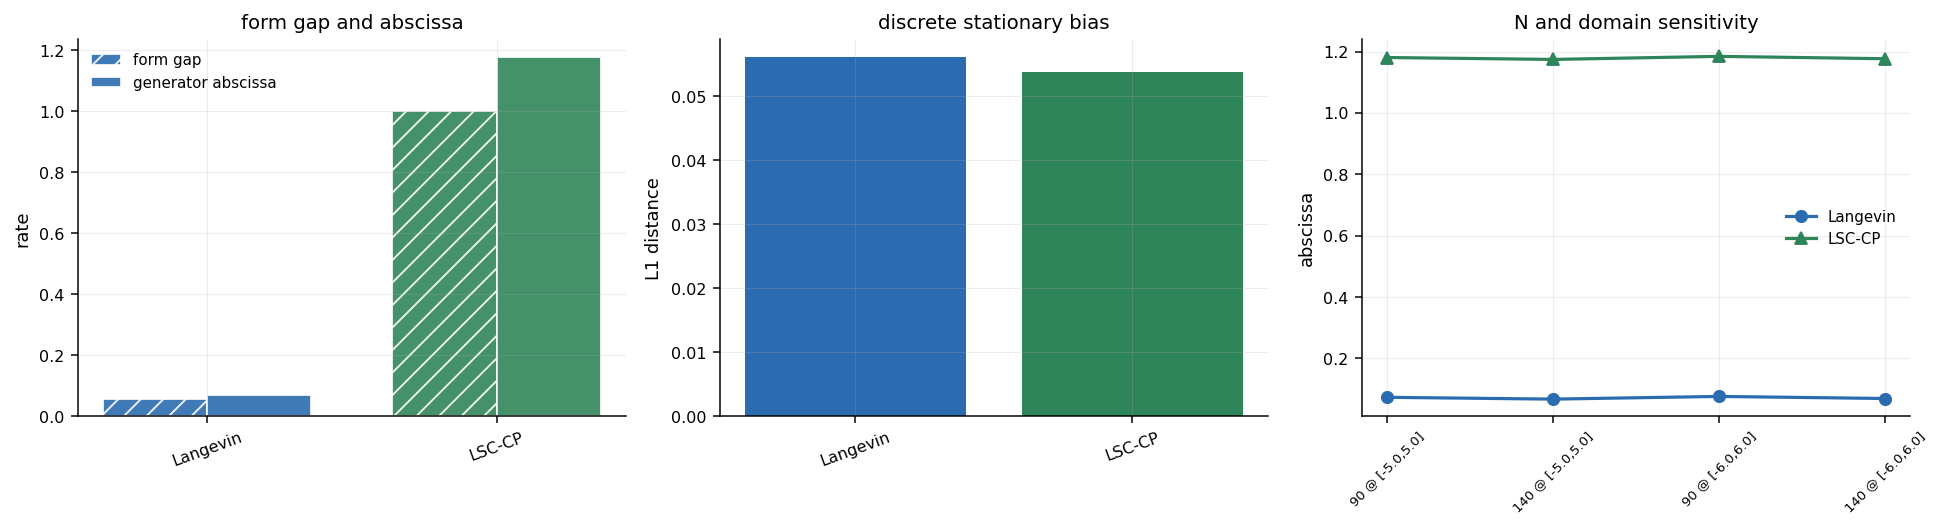

Main generator abscissae: {'Langevin': 0.06935752938751538, 'LSC-CP': 1.1764824318166955}


In [7]:
from scipy.linalg import eig

def gaussian_mass_on_grid(x, dxw, center, scale):
    z = np.exp(-0.5*((x-center)/scale)**2)
    z = z / np.sum(z*dxw)
    return z*dxw

def build_fd_generator_1d(logp_fn, grad_logp_fn, eps, x_min, x_max, N, jump=None,
                          theta_n=12, drift_abs_cap=300.0):
    """Diagnostic backward generator on a finite interval.

    This finite-dimensional generator is used only for abscissa and stationarity diagnostics.
    It matches the notebook convention that outside-domain jump evaluations are clamped to the
    nearest boundary.  Therefore the reported abscissa should be interpreted together with the
    stationarity residual and stationary bias.
    """
    x = np.linspace(float(x_min), float(x_max), int(N))
    p_density, dxw, _ = normalize_pdf_grid(x, logp_fn(x))
    mu = p_density * dxw
    n = len(x)
    dx = x[1] - x[0]
    A = np.zeros((n, n), dtype=float)

    # Diffusion as reflecting nearest-neighbor CTMC.
    rate_diff = eps/(dx*dx)
    for i in range(n):
        if i == 0:
            A[i, i+1] += 2*rate_diff; A[i, i] -= 2*rate_diff
        elif i == n-1:
            A[i, i-1] += 2*rate_diff; A[i, i] -= 2*rate_diff
        else:
            A[i, i-1] += rate_diff; A[i, i+1] += rate_diff; A[i, i] -= 2*rate_diff

    # Upwind drift.  The LSC score is recomputed for the given jump law.
    b = eps * grad_logp_fn(x)
    score_diag = {}
    if jump is not None:
        Sscore, score_diag = levy_score_1d_grid(
            x, logp_fn, jump, theta_n=theta_n, log_clip=None, score_clip=None
        )
        b = b + Sscore
    b = np.clip(b, -drift_abs_cap, drift_abs_cap)
    for i, bi in enumerate(b):
        if bi > 0 and i < n-1:
            r = bi/dx; A[i, i+1] += r; A[i, i] -= r
        elif bi < 0 and i > 0:
            r = -bi/dx; A[i, i-1] += r; A[i, i] -= r

    # Jump operator: lambda E[f(x+r)-f(x)] with clamped interpolation at the finite boundary.
    if jump is not None:
        rs, wr = jump.atoms()
        I = sparse.eye(n, format="csr")
        for r, pr in zip(rs, wr):
            T = interp_shift_matrix_1d(x, float(r))
            A += jump.lam * float(pr) * (T - I).toarray()

    return A, x, mu, dxw, score_diag

def stationary_bias_from_generator(A, mu, neg_tol=1e-8):
    vals, vecs = eig(A.T)
    idx = int(np.argmin(np.abs(vals)))
    v = np.real(vecs[:, idx])
    if np.sum(v) < 0:
        v = -v
    min_entry = float(np.min(v))
    negative_mass = float(np.sum(np.abs(v[v < 0])))
    warning = bool(min_entry < -neg_tol)
    # Do not silently take abs(v): negative mass is a diagnostic of a suspect
    # discrete generator/eigenvector.  We keep a projected debug bias, but the
    # main stationary_bias_l1 is set to NaN whenever the warning triggers.
    v_projected = np.maximum(v, 0.0)
    if np.sum(v_projected) <= 0:
        v_projected = np.ones_like(mu)
        warning = True
    ptilde = v_projected / np.sum(v_projected)
    projected_bias = float(np.sum(np.abs(ptilde - mu)))
    main_bias = np.nan if warning else projected_bias
    diag = {
        "stationary_vector_min": min_entry,
        "stationary_vector_negative_mass": negative_mass,
        "stationary_vector_warning": warning,
        "stationary_bias_l1_projected": projected_bias,
    }
    return ptilde, main_bias, vals[idx], diag


def generator_abscissa_from_A(A, tol=1e-8):
    vals = eig(A, left=False, right=False)
    rates = sorted([-np.real(v) for v in vals if abs(v) > tol and -np.real(v) > tol])
    return float(rates[0]) if rates else np.nan, vals

def run_generator_diagnostics_1d(method_jump_map, domains, Ns, *, label_prefix, init_center, init_scale):
    rows = []
    spectra = {}
    for domain in domains:
        for N in Ns:
            for method, jump in method_jump_map.items():
                A, xg, mug, dxwg, score_diag = build_fd_generator_1d(
                    logp, grad_logp, eps, domain[0], domain[1], int(N), jump=jump,
                    theta_n=max(4, min(CFG.get("theta_n", 12), 14))
                )
                abscissa, vals = generator_abscissa_from_A(A)
                ptilde, bias_l1, zero_eval, stat_diag = stationary_bias_from_generator(A, mug)
                rows.append(dict(
                    method=method, x_min=domain[0], x_max=domain[1], N=int(N),
                    generator_abscissa=abscissa,
                    row_sum_inf=float(np.max(np.abs(A.sum(axis=1)))),
                    stationary_residual_l1=float(np.sum(np.abs(mug @ A))),
                    stationary_residual_linf=float(np.max(np.abs(mug @ A))),
                    stationary_bias_l1=bias_l1,
                    stationary_bias_l1_projected=float(stat_diag.get("stationary_bias_l1_projected", np.nan)),
                    zero_eval_abs=float(abs(zero_eval)),
                    stationary_vector_min=float(stat_diag["stationary_vector_min"]),
                    stationary_vector_negative_mass=float(stat_diag["stationary_vector_negative_mass"]),
                    stationary_vector_warning=bool(stat_diag["stationary_vector_warning"]),
                    score_clip_fraction=float(score_diag.get("score_clip_fraction", 0.0)),
                    logratio_clip_fraction=float(score_diag.get("logratio_clip_fraction", 0.0)),
                ))
                spectra[(method, domain, int(N))] = vals
    gen_df = pd.DataFrame(rows)
    gen_df.to_csv(TABDIR / f"{label_prefix}generator_stationarity_sensitivity.csv", index=False)

    # Main values: largest N on the widest domain in the sweep.
    main_domain = domains[-1]
    main_N = max(Ns)
    main_df = gen_df[(gen_df.N == main_N) & (gen_df.x_min == main_domain[0]) & (gen_df.x_max == main_domain[1])].copy()
    main_df.to_csv(TABDIR / f"{label_prefix}generator_main_diagnostics.csv", index=False)
    display(main_df)

    abscissa = main_df.set_index("method")["generator_abscissa"].to_dict()

    fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.0))
    labels = list(method_jump_map.keys())
    xloc = np.arange(len(labels))
    form_vals = [gap_main.get(m, np.nan) for m in labels]
    abs_vals = [abscissa.get(m, np.nan) for m in labels]
    w = 0.36
    ax[0].bar(xloc-w/2, form_vals, width=w, color=[method_color(m) for m in labels], alpha=0.9, hatch="//", edgecolor="white", label="form gap")
    ax[0].bar(xloc+w/2, abs_vals, width=w, color=[method_color(m) for m in labels], alpha=0.9, edgecolor="white", label="generator abscissa")
    ax[0].set_xticks(xloc); ax[0].set_xticklabels(labels, rotation=20)
    ax[0].set_title("form gap and abscissa")
    ax[0].set_ylabel("rate")
    ax[0].legend(fontsize=8)

    ax[1].bar(main_df.method, main_df.stationary_bias_l1, color=[method_color(m) for m in main_df.method])
    ax[1].set_title("discrete stationary bias")
    ax[1].set_ylabel("L1 distance")
    ax[1].tick_params(axis="x", rotation=20)

    for method in labels:
        sub = gen_df[gen_df.method == method].sort_values(["x_max", "N"])
        ax[2].plot(sub.N.astype(str) + " @ [" + sub.x_min.astype(str) + "," + sub.x_max.astype(str) + "]",
                   sub.generator_abscissa, marker=method_marker(method), color=method_color(method), label=method)
    ax[2].set_title("N and domain sensitivity")
    ax[2].set_ylabel("abscissa")
    ax[2].tick_params(axis="x", rotation=45, labelsize=7)
    ax[2].legend(fontsize=8)
    savefig(fig, FIGDIR, f"{label_prefix}fig02b_abscissa_stationarity_sensitivity")
    plt.show()

    return gen_df, main_df, abscissa



# Main diagnostic generator: Langevin and LSC-CP only.
if PROFILE == "smoke":
    GEN_NS = [45]
    GEN_DOMAINS = [(-6.0, 6.0)]
elif PROFILE == "paperlite":
    GEN_NS = [90, 140]
    GEN_DOMAINS = [(-5.0, 5.0), (-6.0, 6.0)]
else:
    GEN_NS = [120, 180, 260]
    GEN_DOMAINS = [(-5.0, 5.0), (-6.0, 6.0), (-7.0, 7.0)]

generator_diag_df, generator_main_df, abscissa_main = run_generator_diagnostics_1d(
    {"Langevin": None, "LSC-CP": jump_main},
    GEN_DOMAINS, GEN_NS, label_prefix="doublewell_", init_center=-1.0, init_scale=0.08
)
print("Main generator abscissae:", abscissa_main)

## 3. Samplers: same initial distribution for all methods

The initial cloud is intentionally core-localized.  This probes inter-well exploration from a metastable initial condition.  Early-time local relaxation of the cloud should not be interpreted as inter-well mixing.



In [8]:
def kinetic_langevin_step_1d(x, p, dt, rng, gamma=0.65, mass=0.02):
    """BAOAB kinetic Langevin step for 1D targets with mass-scaled velocity."""
    force = eps * grad_logp(x)
    p = p + 0.5 * dt * force
    x = x + 0.5 * dt * (p / mass)
    a = math.exp(-gamma * dt)
    p = a * p + math.sqrt(eps * mass * (1.0 - a*a)) * rng.standard_normal(p.shape)
    x = x + 0.5 * dt * (p / mass)
    force = eps * grad_logp(x)
    p = p + 0.5 * dt * force
    return x, p

# Cache Levy score once per jump law.  This avoids recomputing the same quadrature in every seed.
score_cache = {}
_lsc_score_grid = np.linspace(x_clip[0], x_clip[1], 1200 if PROFILE != "smoke" else 420)
_lsc_score_vals, _lsc_score_diag = levy_score_1d_grid(
    _lsc_score_grid, logp, jump_main, theta_n=CFG["theta_n"], log_clip=None, score_clip=None
)
score_cache["LSC-CP"] = (_lsc_score_grid, _lsc_score_vals, _lsc_score_diag)
print("cached 1D LSC score diagnostics:", _lsc_score_diag)

def simulate_method(method, rng_seed, x0, seed_id=None, jump=jump_main, *, score_cache=None,
                    dt_override=None, n_steps_override=None, rec_override=None):
    rng = np.random.default_rng(rng_seed)
    dt = CFG["dt"] if dt_override is None else float(dt_override)
    n_steps = CFG["n_steps"] if n_steps_override is None else int(n_steps_override)
    rec = CFG["record_every"] if rec_override is None else int(rec_override)
    x = x0.copy()
    kin_mass = CFG.get("kinetic_mass", 0.02)
    p = math.sqrt(eps * kin_mass) * rng.standard_normal(x.shape) if method == "Kinetic-Langevin" else None
    times=[]; samples=[]; accs=[]; clip_sum=0.0; clip_max=0.0; clip_count=0
    score_grid = None
    if method == "LSC-CP":
        if score_cache is not None and method in score_cache:
            score_grid = score_cache[method]
        else:
            sg = np.linspace(x_clip[0], x_clip[1], 1200 if PROFILE!="smoke" else 420)
            score_vals, score_diag = levy_score_1d_grid(
                sg, logp, jump, theta_n=CFG["theta_n"], log_clip=None, score_clip=None
            )
            score_grid = (sg, score_vals, score_diag)
    for k in range(n_steps+1):
        if k % rec == 0:
            times.append(k*dt); samples.append(x.copy())
        if k == n_steps: break
        if method == "Langevin":
            drift = eps*grad_logp(x)
            x = x + dt*drift + np.sqrt(2*eps*dt)*rng.standard_normal(x.shape)
        elif method == "Kinetic-Langevin":
            x, p = kinetic_langevin_step_1d(x, p, dt, rng, gamma=CFG.get("kinetic_gamma", 0.65), mass=CFG.get("kinetic_mass", 0.02))
        elif method == "CP":
            drift = eps*grad_logp(x)
            x = x + dt*drift + np.sqrt(2*eps*dt)*rng.standard_normal(x.shape)
            x, nj = apply_compound_poisson_jumps_1d(x, jump, rng, dt)
        elif method == "LSC-CP":
            sg, sv, sdiag = score_grid
            S = np.interp(np.clip(x, sg[0], sg[-1]), sg, sv)
            drift = eps*grad_logp(x) + S
            x = x + dt*drift/(1+dt*np.abs(drift)) + np.sqrt(2*eps*dt)*rng.standard_normal(x.shape)
            x, nj = apply_compound_poisson_jumps_1d(x, jump, rng, dt)
        else:
            raise ValueError(method)
        x, _clip_fraction = safety_clip_1d(x, method, x_clip)
        clip_sum += float(_clip_fraction); clip_max = max(clip_max, float(_clip_fraction)); clip_count += 1
    return {"method":method, "seed": seed_id if seed_id is not None else rng_seed, "rng_seed": rng_seed, "times":np.array(times), "samples":samples,
            "accept":np.nan,
            "score_diag": score_grid[2] if score_grid is not None else {},
            "safety_clip_fraction": float(clip_sum/max(1, clip_count)),
            "safety_clip_fraction_max": float(clip_max)}

methods = ["Langevin","Kinetic-Langevin","LSC-CP","CP"]
base_rng = np.random.default_rng(GLOBAL_SEED)
tasks = []
for s in range(CFG["n_seeds"]):
    x0 = make_initial_cloud_1d(base_rng, center=-1.0, scale=0.075, n=CFG["n_particles"], clip=x_clip)
    for mi, m in enumerate(methods):
        tasks.append((m, GLOBAL_SEED+1000*s+mi, x0.copy(), s))

if HAS_JOBLIB and CFG.get("n_jobs", 1) > 1:
    all_runs = Parallel(n_jobs=CFG["n_jobs"], backend="loky")(
        delayed(simulate_method)(m, rs, x0, seed_id=sid, jump=jump_main, score_cache=score_cache)
        for (m, rs, x0, sid) in tasks
    )
else:
    all_runs = [simulate_method(m, rs, x0, seed_id=sid, jump=jump_main, score_cache=score_cache)
                for (m, rs, x0, sid) in tasks]
print("completed runs:", len(all_runs), "n_jobs:", CFG.get("n_jobs", 1))
print("Kinetic-Langevin gamma/mass:", CFG.get("kinetic_gamma", 0.65), CFG.get("kinetic_mass", 0.02))
print("LSC score diagnostics:", [r["score_diag"] for r in all_runs if r["method"]=="LSC-CP"][:1])


cached 1D LSC score diagnostics: {'score_clip_fraction': 0.0, 'logratio_clip_fraction': 0.0, 'score_changing_logratio_clip_fraction': 0.0, 'overflow_guard_logratio_clip_fraction': 0.2084702380952381, 'effective_log_clip': 707.782712893384, 'max_score_abs': 1.857701812579846e+307, 'max_log_ratio': 6330.75577313185, 'score_clipping_warning': False, 'logratio_clipping_warning': False}


completed runs: 16 n_jobs: 1
Kinetic-Langevin gamma/mass: 1.3 0.02
LSC score diagnostics: [{'score_clip_fraction': 0.0, 'logratio_clip_fraction': 0.0, 'score_changing_logratio_clip_fraction': 0.0, 'overflow_guard_logratio_clip_fraction': 0.2084702380952381, 'effective_log_clip': 707.782712893384, 'max_score_abs': 1.857701812579846e+307, 'max_log_ratio': 6330.75577313185, 'score_clipping_warning': False, 'logratio_clipping_warning': False}]


## 4. Metrics, gap-predicted decay, and final density/CDF figures

target well masses: [0.5 0.5]


,method,seed,mean,std,left_mass
0,Langevin,0,-0.997718,0.074991,1.0
1,Kinetic-Langevin,0,-0.997718,0.074991,1.0
2,LSC-CP,0,-0.997718,0.074991,1.0
3,CP,0,-0.997718,0.074991,1.0
4,Langevin,1,-0.998106,0.076619,1.0
5,Kinetic-Langevin,1,-0.998106,0.076619,1.0
6,LSC-CP,1,-0.998106,0.076619,1.0
7,CP,1,-0.998106,0.076619,1.0
8,Langevin,2,-1.001504,0.075306,1.0
9,Kinetic-Langevin,2,-1.001504,0.075306,1.0


max within-seed spread of initial left-mass across methods: 0.0


CDF_sup                                             W1  \
method        CP Kinetic-Langevin    LSC-CP  Langevin        CP   
seed                                                              
0       0.681987         0.681987  0.681987  0.681987  1.019114   
1       0.676850         0.676850  0.676850  0.676850  1.018562   
2       0.684260         0.684260  0.684260  0.684260  1.021632   
3       0.681850         0.681850  0.681850  0.681850  1.020251   

                                            well_TV                          \
method Kinetic-Langevin    LSC-CP  Langevin      CP Kinetic-Langevin LSC-CP   
seed                                                                          
0              1.019114  1.019114  1.019114     0.5              0.5    0.5   
1              1.018562  1.018562  1.018562     0.5              0.5    0.5   
2              1.021632  1.021632  1.021632     0.5              0.5    0.5   
3              1.020251  1.020251  1.020251     0.5              0.5    0.5   

                 
method Langevin  
seed             
0           0.5  
1           0.5  
2           0.5  
3           0.5

max within-seed spread of initial W1 across methods: 0.0
max within-seed spread of initial well_TV across methods: 0.0
max within-seed spread of initial CDF_sup across methods: 0.0


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig03_mixing_with_form_and_abscissa_references.pdf


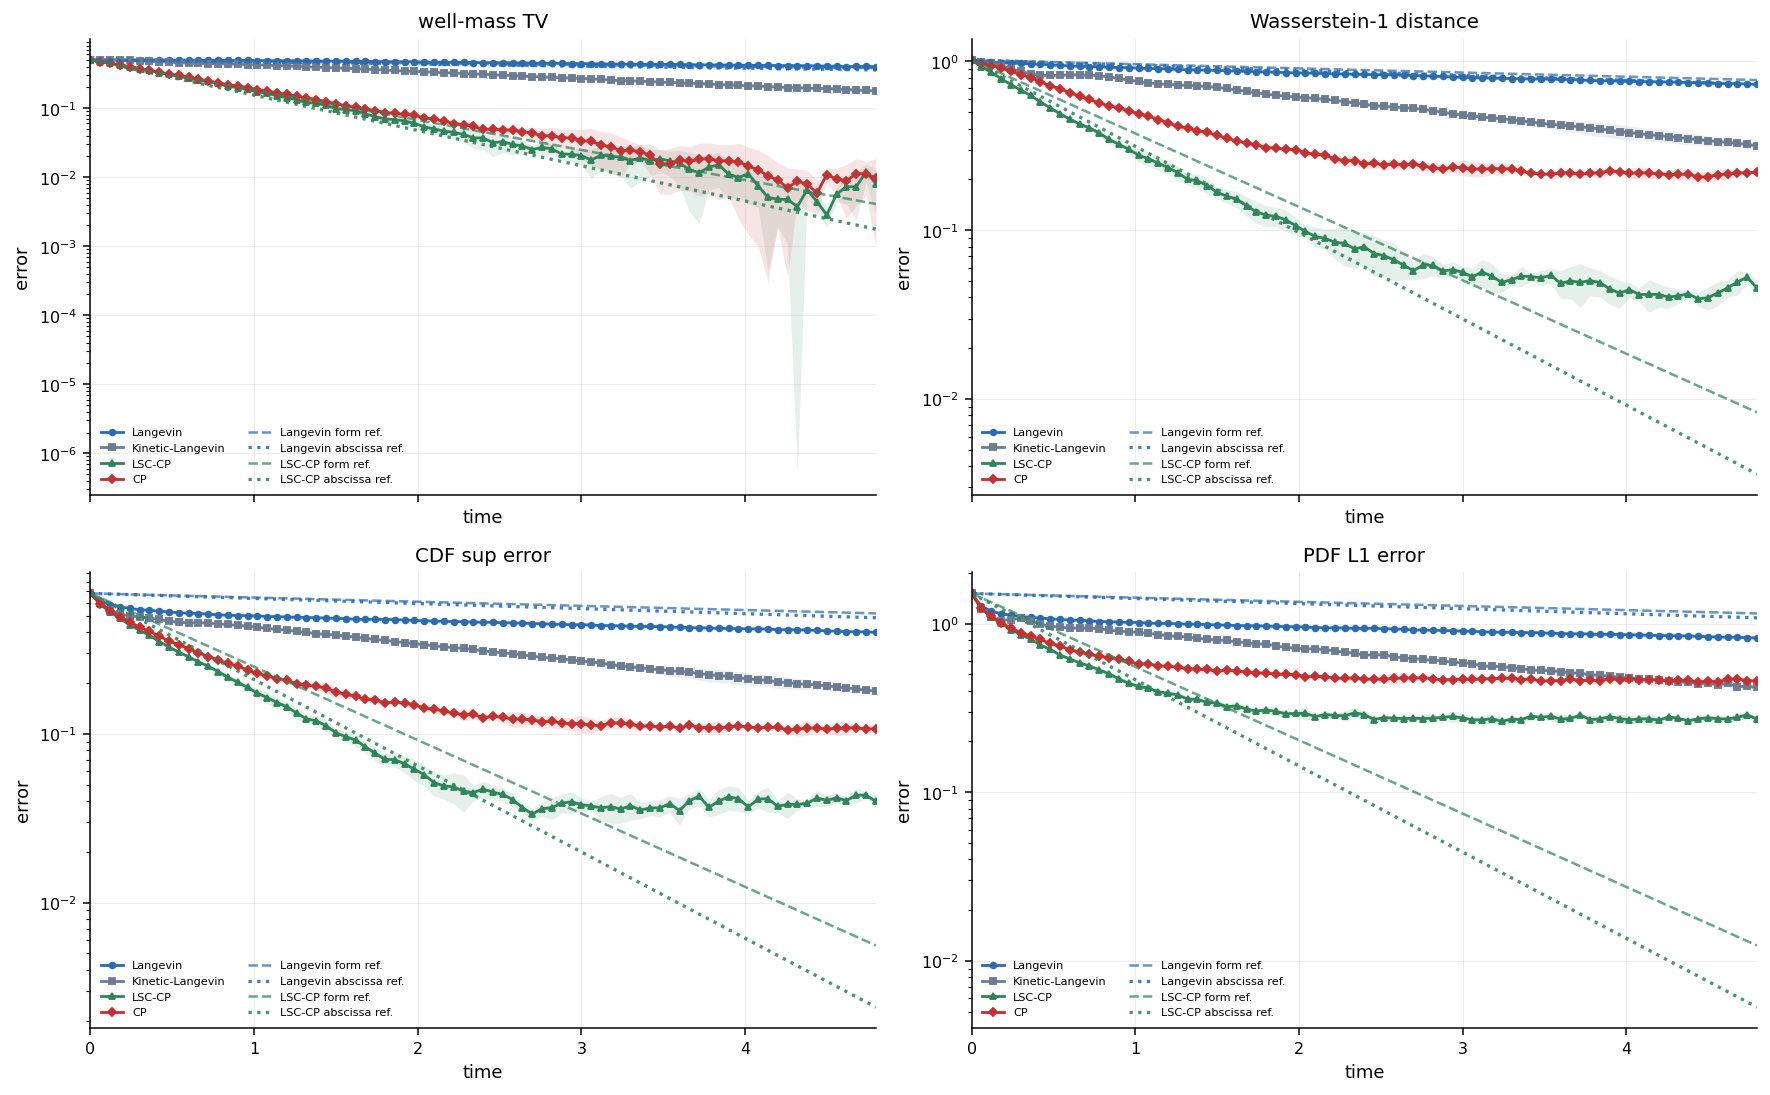

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig04_final_pdf_cdf_metrics_particles.pdf


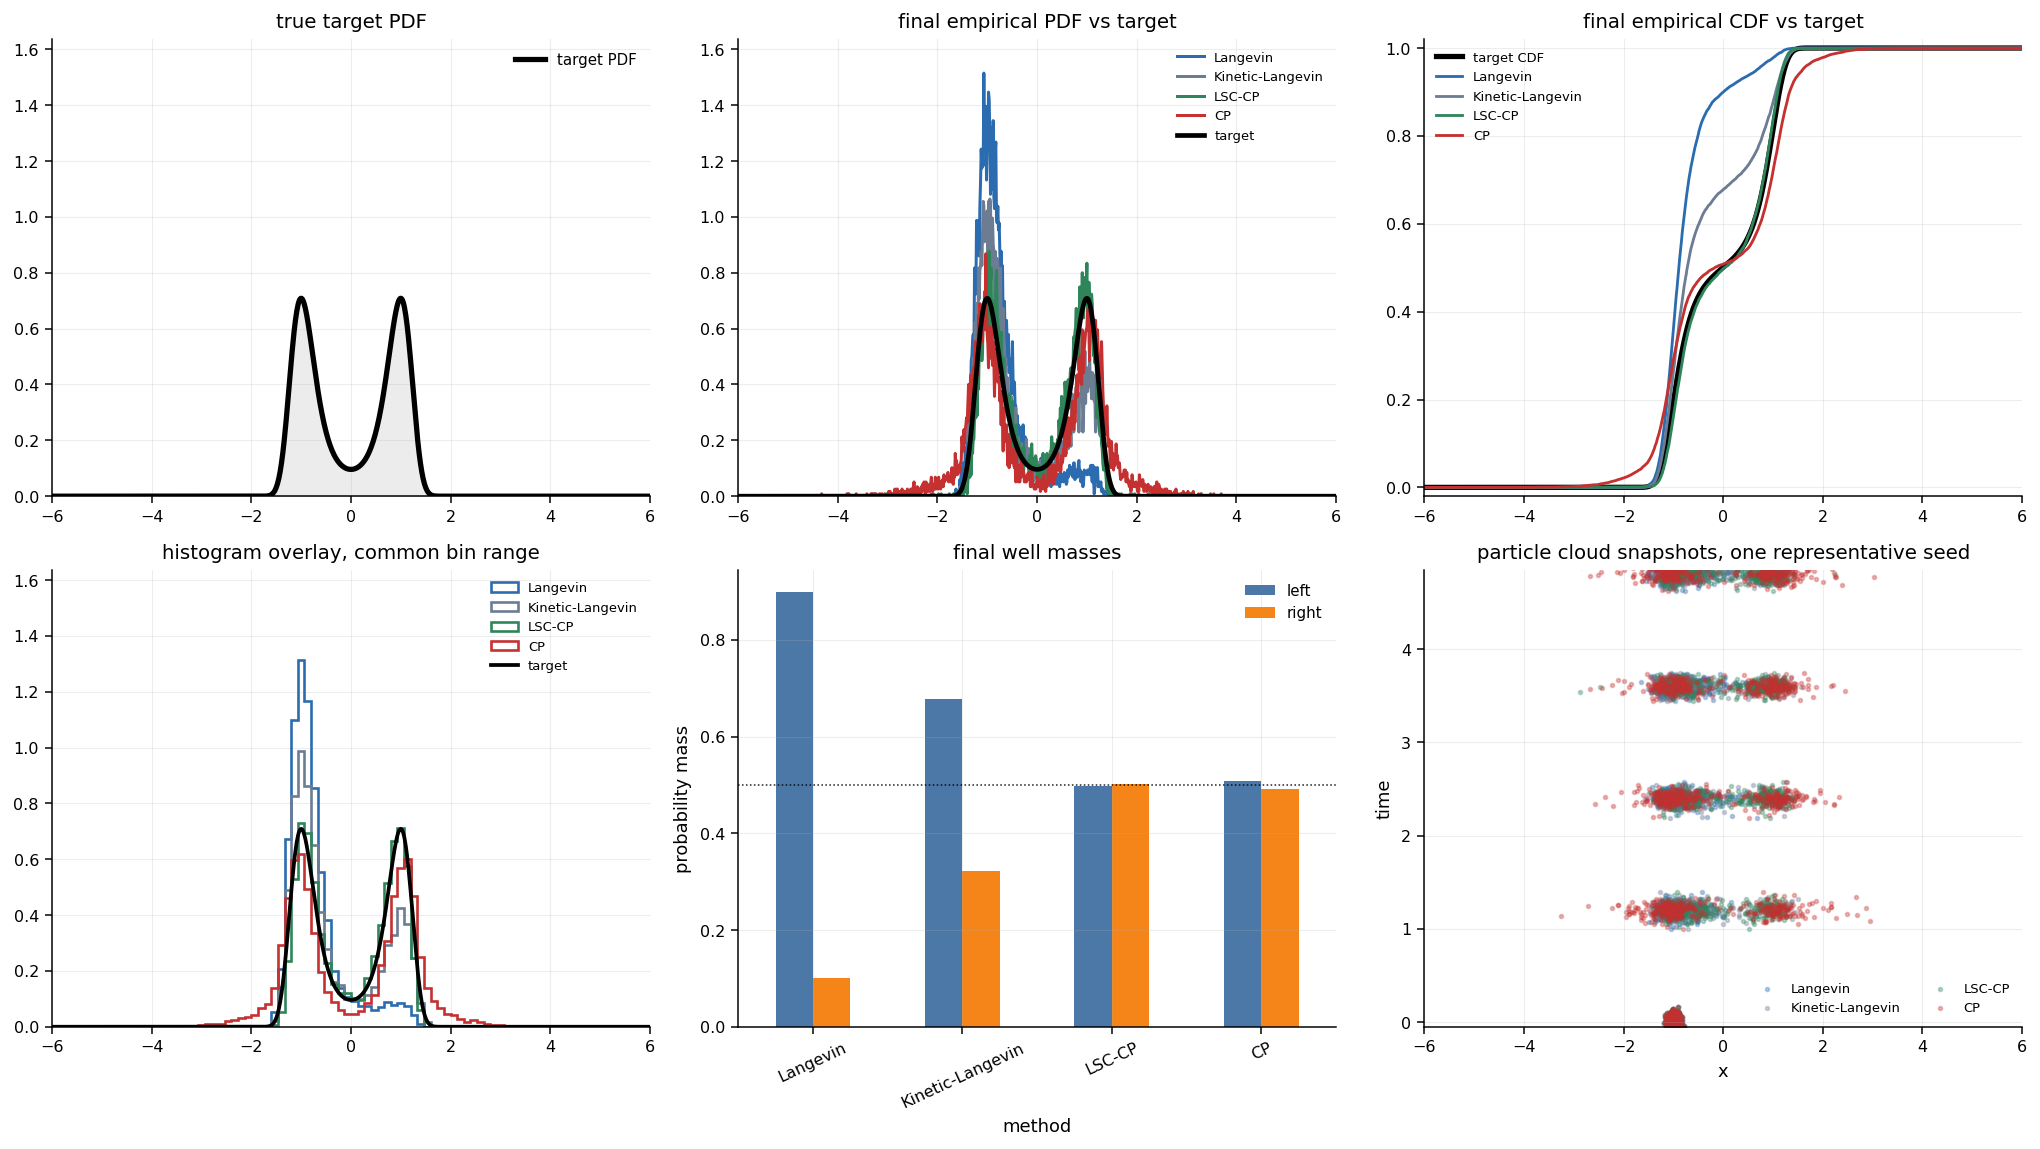

,method,W1_mean,W1_std,CDF_sup_mean,CDF_sup_std,well_TV_mean,well_TV_std,L1_pdf_mean,L1_pdf_std
0,CP,0.220360,0.006331,0.107728,0.005983,0.009773,0.008794,0.456995,0.005490
1,Kinetic-Langevin,0.316993,0.014057,0.179807,0.008803,0.177500,0.008857,0.418134,0.010743
2,LSC-CP,0.045355,0.005237,0.039807,0.003575,0.008068,0.005201,0.271536,0.009482
3,Langevin,0.732692,0.006450,0.400722,0.005726,0.399659,0.005849,0.822836,0.011006


In [9]:

def well_masses_2well(samples):
    return np.array([np.mean(samples < 0), np.mean(samples >= 0)])

target_well = np.array([
    np.sum((target_grid < 0) * p_grid * dxw_grid),
    np.sum((target_grid >= 0) * p_grid * dxw_grid),
])
target_left = target_well[0]
print("target well masses:", target_well)

# Fairness diagnostic: the four methods must start from the same cloud for each seed.
init_rows = []
for r in all_runs:
    xs0 = r["samples"][0]
    init_rows.append(dict(method=r["method"], seed=r["seed"],
                          mean=float(np.mean(xs0)), std=float(np.std(xs0)),
                          left_mass=float(np.mean(xs0 < 0))))
init_df = pd.DataFrame(init_rows)
init_pivot = init_df.pivot(index="seed", columns="method", values="left_mass")
display(init_df)
print("max within-seed spread of initial left-mass across methods:",
      float(init_pivot.max(axis=1).sub(init_pivot.min(axis=1)).max()))

metric_rows = []
for r in all_runs:
    for t, xs in zip(r["times"], r["samples"]):
        centers, hp = empirical_pdf_1d(xs, target_grid, clip_range=(target_grid[0], target_grid[-1]))
        p_interp = np.interp(centers, target_grid, p_grid)
        l1_pdf = _trapz(np.abs(hp - p_interp), centers)
        ecdf = empirical_cdf_on_grid(xs, target_grid)
        cdf_sup = np.max(np.abs(ecdf - cdf_grid))
        wm = well_masses_2well(xs)
        well_tv = 0.5 * np.sum(np.abs(wm - target_well))
        w1 = w1_empirical_to_target_cdf(xs, target_grid, cdf_grid)
        metric_rows.append(dict(method=r["method"], seed=r["seed"], time=t, W1=w1, L1_pdf=l1_pdf,
                                CDF_sup=cdf_sup, well_TV=well_tv, accept=r["accept"]))
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(TABDIR / "doublewell_metrics_timeseries.csv", index=False)

# Initial metric equality diagnostic.
init_metrics = metrics[metrics.time == metrics.time.min()].pivot_table(index="seed", columns="method", values=["W1", "well_TV", "CDF_sup"])
display(init_metrics)
for metric_name in ["W1", "well_TV", "CDF_sup"]:
    piv = metrics[metrics.time == metrics.time.min()].pivot_table(index="seed", columns="method", values=metric_name)
    print(f"max within-seed spread of initial {metric_name} across methods:", float((piv.max(axis=1)-piv.min(axis=1)).max()))

# Empirical curves with confidence bands and aligned reference lines.
fig, ax = plt.subplots(2, 2, figsize=(13.2, 8.2), sharex=True)
ax = ax.ravel()
panel_metrics = [
    ("well_TV", "well-mass TV"),
    ("W1", "Wasserstein-1 distance"),
    ("CDF_sup", "CDF sup error"),
    ("L1_pdf", "PDF L1 error"),
]
for j, (metric, title) in enumerate(panel_metrics):
    for m in methods:
        plot_metric_with_ci(ax[j], metrics, m, metric, logy=True, lw=1.5)
    # Reference lines are visual rate references only.  They use the same empirical y0.
    for m in ["Langevin", "LSC-CP"]:
        add_rate_reference_lines(
            ax[j], metrics, metric, m,
            form_rate=gap_main.get(m, np.nan),
            abscissa_rate=globals().get("abscissa_main", {}).get(m, np.nan),
            logy=True,
        )
    ax[j].set_title(title)
    ax[j].set_xlabel("time")
    ax[j].set_xlim(metrics.time.min(), metrics.time.max())
    ax[j].set_ylabel("error")
    ax[j].legend(fontsize=6, ncol=2)
savefig(fig, FIGDIR, "fig03_mixing_with_form_and_abscissa_references")
plt.show()

# Final PDF and CDF overlays with fixed, comparable axes and explicit target density.
final_by_method = {}
pdf_curves = {}
cdf_curves = {}
for m in methods:
    final = np.concatenate([r["samples"][-1] for r in all_runs if r["method"] == m])
    final_by_method[m] = final
    centers, hp = empirical_pdf_1d(final, target_grid, clip_range=(target_grid[0], target_grid[-1]))
    pdf_curves[m] = (centers, hp)
    cdf_curves[m] = empirical_cdf_on_grid(final, target_grid)

pdf_ymax = 1.08 * max([np.max(p_grid)] + [np.max(v[1]) for v in pdf_curves.values()])
xlim_pdf = (target_grid[0], target_grid[-1])

fig, ax = plt.subplots(2, 3, figsize=(15.2, 8.6))
ax = ax.ravel()
ax[0].plot(target_grid, p_grid, color="k", lw=2.8, label="target PDF")
ax[0].fill_between(target_grid, 0, p_grid, color="0.4", alpha=0.12)
ax[0].set_title("true target PDF")
ax[0].set_xlim(xlim_pdf); ax[0].set_ylim(0, pdf_ymax)
ax[0].legend(fontsize=8)

for m in methods:
    centers, hp = pdf_curves[m]
    ax[1].plot(centers, hp, lw=1.6, color=method_color(m), label=m)
ax[1].plot(target_grid, p_grid, color="k", lw=2.5, label="target")
ax[1].set_title("final empirical PDF vs target")
ax[1].set_xlim(xlim_pdf); ax[1].set_ylim(0, pdf_ymax)
ax[1].legend(fontsize=7)

ax[2].plot(target_grid, cdf_grid, color="k", lw=2.8, label="target CDF")
for m in methods:
    ax[2].plot(target_grid, cdf_curves[m], lw=1.5, color=method_color(m), label=m)
ax[2].set_title("final empirical CDF vs target")
ax[2].set_xlim(xlim_pdf); ax[2].set_ylim(-0.02, 1.02)
ax[2].legend(fontsize=7)

for m in methods:
    ax[3].hist(final_by_method[m], bins=90, range=xlim_pdf, histtype="step", density=True, lw=1.4, color=method_color(m), label=m)
ax[3].plot(target_grid, p_grid, color="k", lw=2, label="target")
ax[3].set_title("histogram overlay, common bin range")
ax[3].set_xlim(xlim_pdf); ax[3].set_ylim(0, pdf_ymax)
ax[3].legend(fontsize=7)

# Final grouped well-mass comparison, consistent with the other examples.
mass_rows = []
for m, final in final_by_method.items():
    wm = well_masses_2well(final)
    mass_rows.append(dict(method=m, left=wm[0], right=wm[1]))
final_mass_df = pd.DataFrame(mass_rows).set_index("method")
final_mass_df.plot(kind="bar", ax=ax[4], color=["#4C78A8", "#F58518"])
for val in target_well:
    ax[4].axhline(val, color="k", ls=":", lw=0.8, alpha=0.55)
ax[4].set_title("final well masses")
ax[4].set_ylabel("probability mass")
ax[4].tick_params(axis="x", rotation=25)

t_final = metrics.time.max()
term_stats = (metrics[np.isclose(metrics.time, t_final)]
              .groupby("method")[["W1", "CDF_sup", "well_TV", "L1_pdf"]]
              .agg(["mean", "std"]))
term = term_stats.copy()
term.columns = [f"{metric}_{stat}" for metric, stat in term.columns]
term = term.reset_index()

# Particle/cloud visualization.
snapshot_times = np.linspace(0, metrics.time.max(), 5)
for m in methods:
    run0 = next(r for r in all_runs if r["method"] == m)
    ts = run0["times"]
    chosen = [int(np.argmin(np.abs(ts - tt))) for tt in snapshot_times]
    for ci in chosen:
        xs = run0["samples"][ci]
        sub = xs[::max(1, len(xs)//350)]
        jitter = 0.06 * np.random.default_rng(123 + ci).standard_normal(len(sub))
        ax[5].scatter(sub, np.full_like(sub, ts[ci]) + jitter, s=4, alpha=0.32, color=method_color(m), label=m if ci == chosen[0] else None)
ax[5].set_title("particle cloud snapshots, one representative seed")
ax[5].set_xlabel("x"); ax[5].set_ylabel("time")
ax[5].set_xlim(xlim_pdf); ax[5].set_ylim(metrics.time.min()-0.05, metrics.time.max()+0.05)
ax[5].legend(fontsize=7, ncol=2)

savefig(fig, FIGDIR, "fig04_final_pdf_cdf_metrics_particles")
plt.show()

term.to_csv(TABDIR / "doublewell_terminal_metrics.csv", index=False)
display(term)


,method,KDE_tail_mass_outside_plot,KDE_vs_histogram_bin_mass_L1
0,CP,0.0,0.031749
1,Kinetic-Langevin,0.0,0.027512
2,LSC-CP,0.0,0.029130
3,Langevin,0.0,0.025469


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig06_density_kde_snapshots.pdf


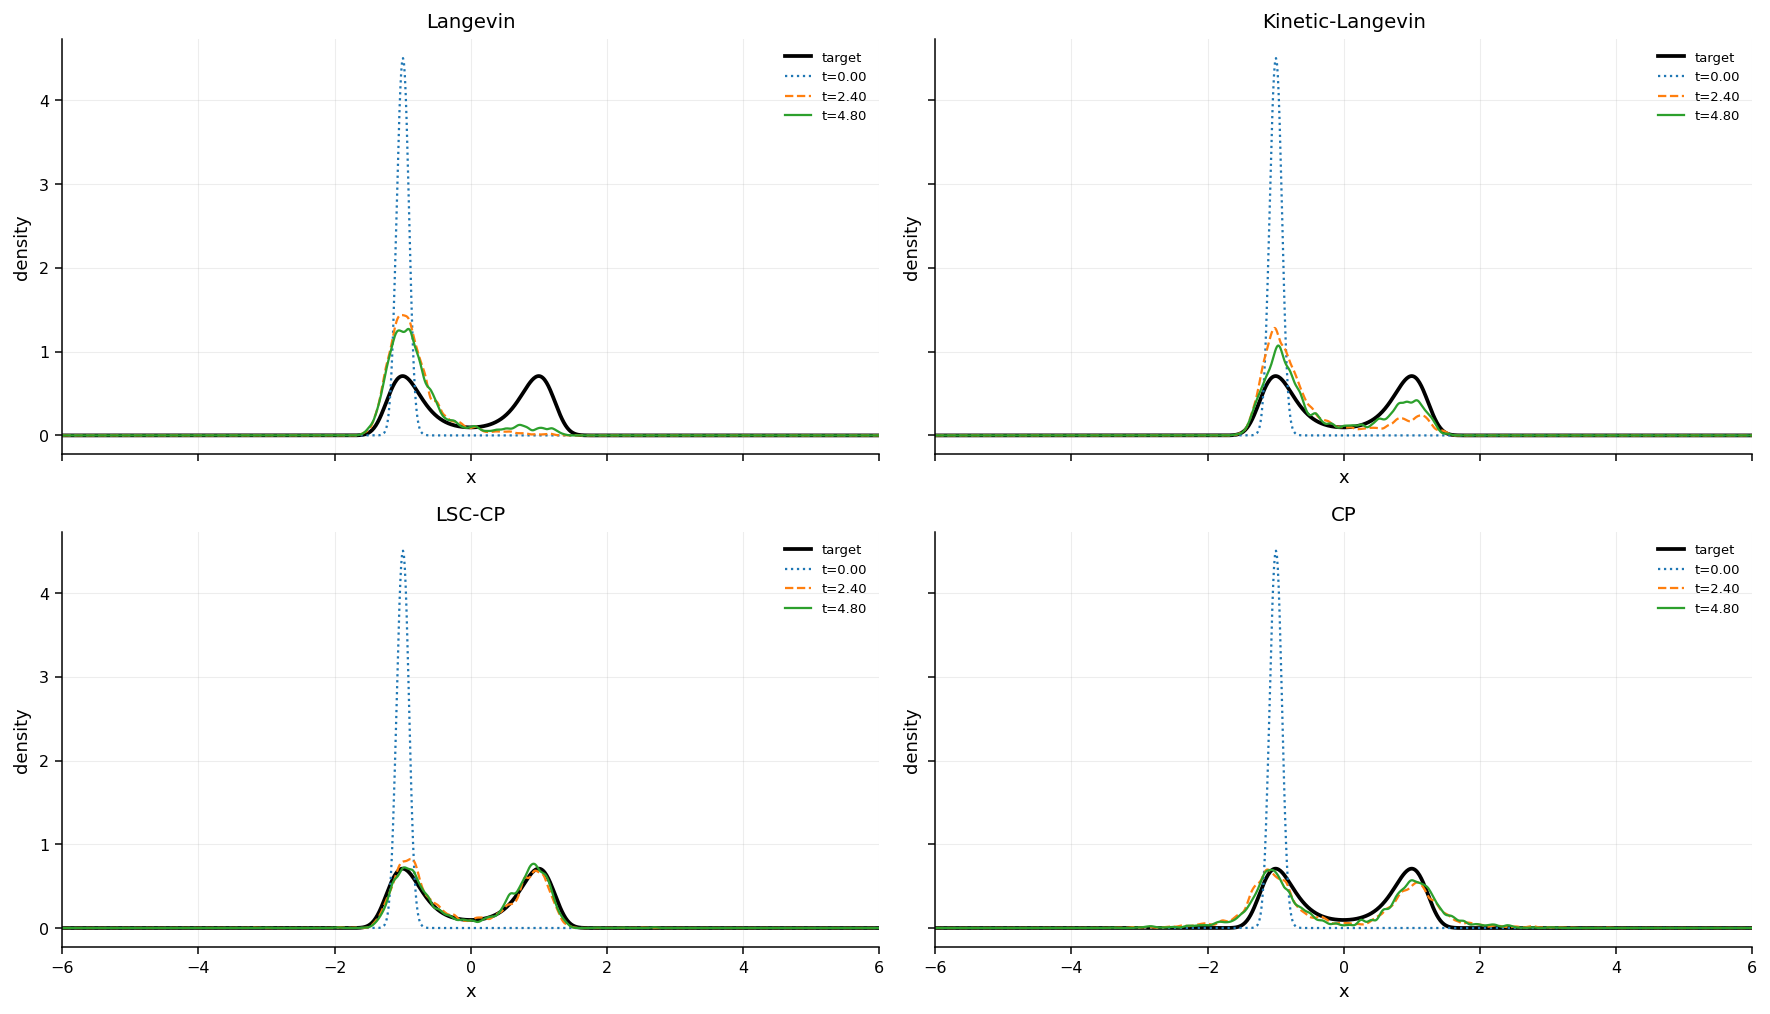

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig06b_l2_density_error.pdf


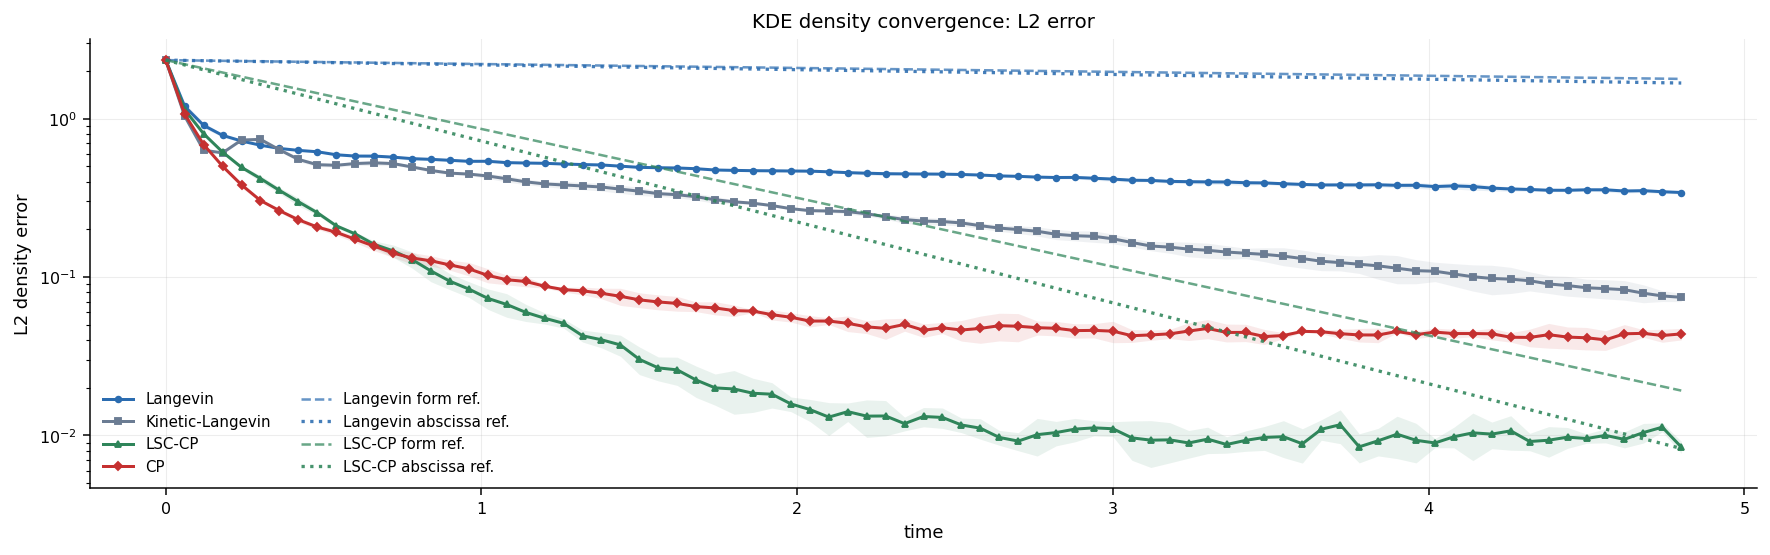

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig06c_truncated_kde_chi2.pdf


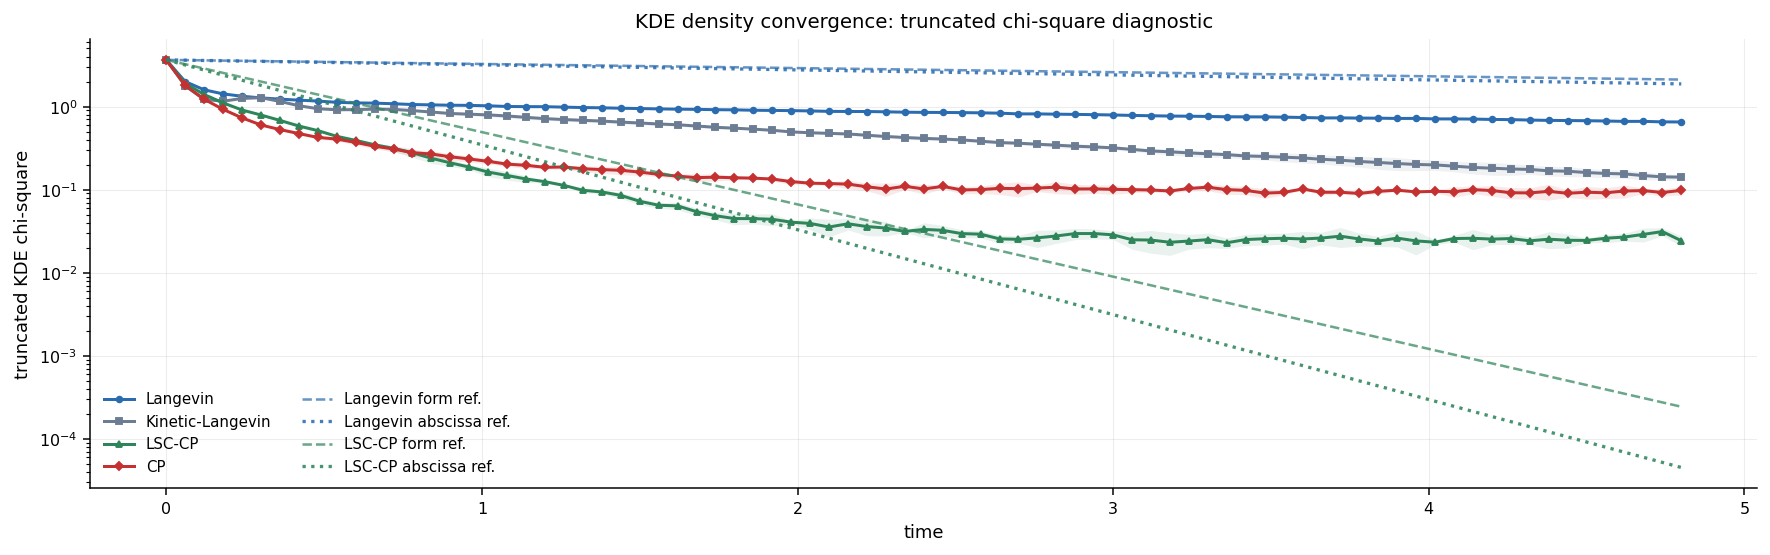

saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig06d_bandwidth_sensitivity.pdf


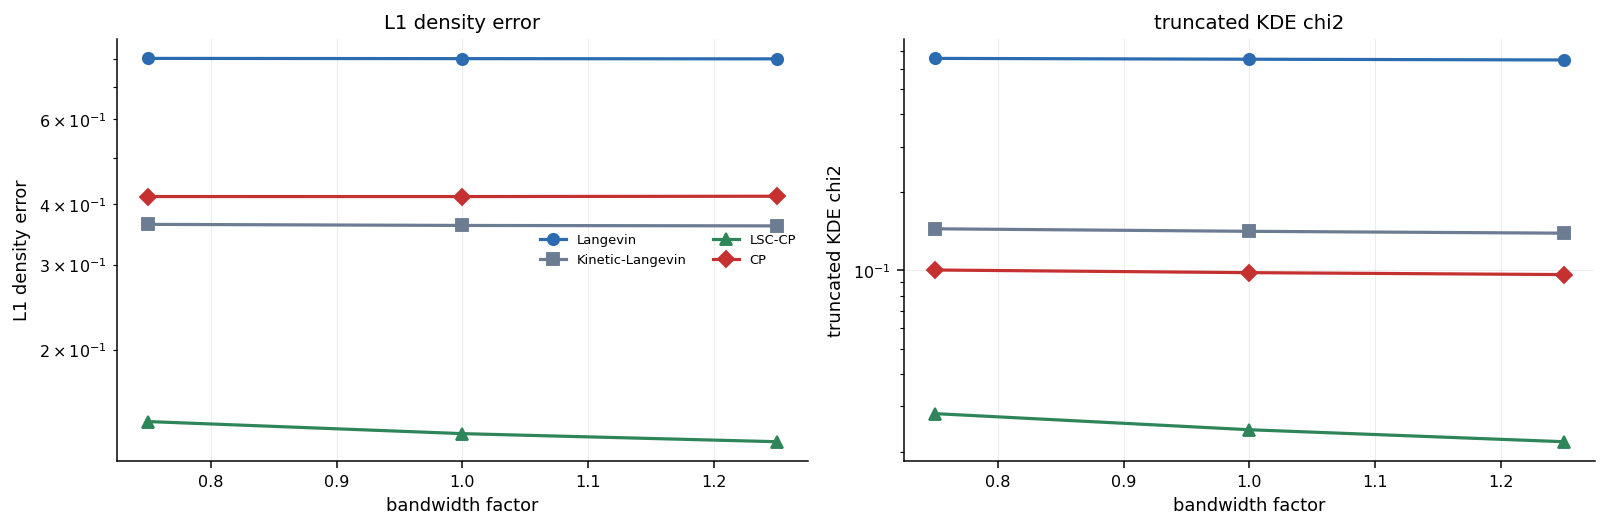

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig06e_drift_fields.pdf


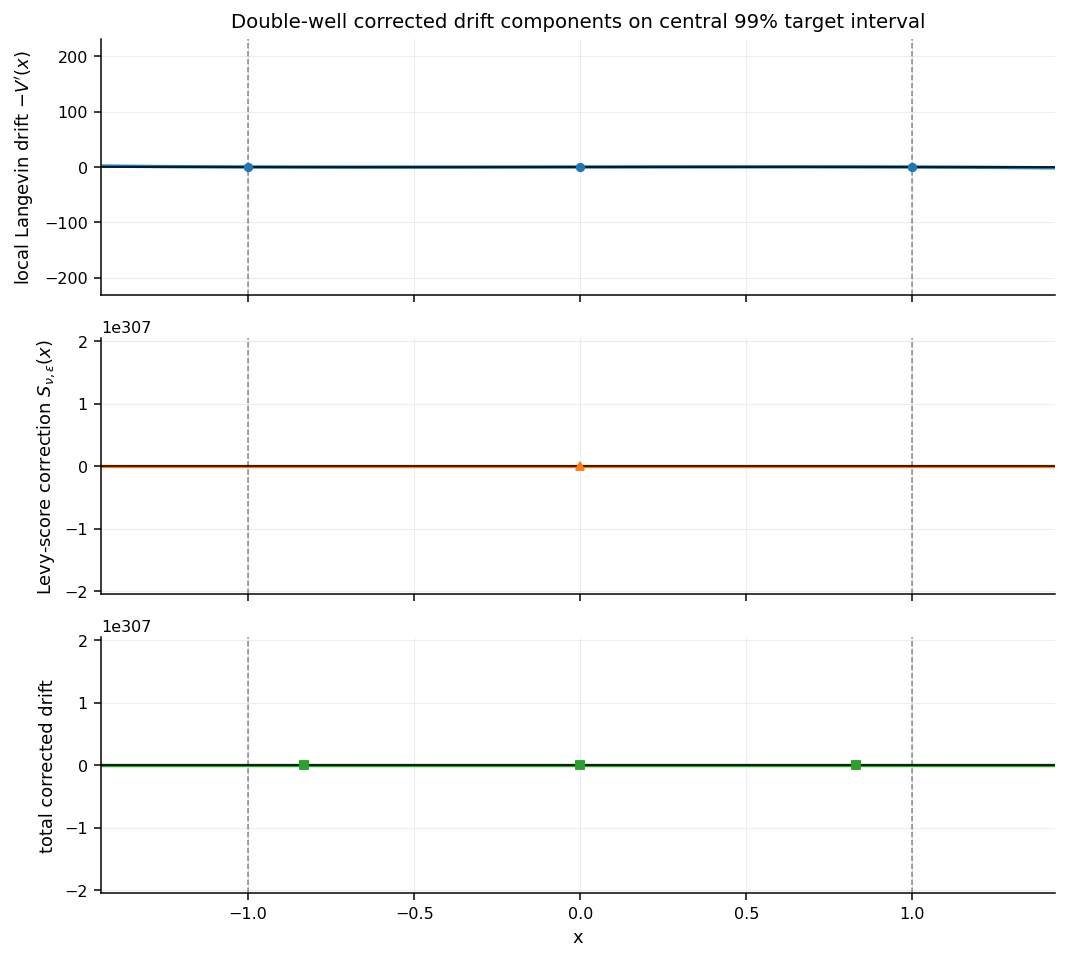

In [10]:
# ---------------------------------------------------------------------
# Phase17H density-level convergence, KDE/CDF, histogram-bin, and drift diagnostics.
# ---------------------------------------------------------------------
density_bandwidth = target_local_scott_bandwidth(target_grid, p_grid, CFG["n_particles"])
chi_lo, chi_hi, chi_omitted = central_interval_from_cdf(target_grid, cdf_grid, mass=0.98)
chi_mask = (target_grid >= chi_lo) & (target_grid <= chi_hi)
density_config = DensityDiagnosticConfig(
    bandwidth=float(density_bandwidth),
    chi_interval=(float(chi_lo), float(chi_hi)),
    chi_omitted_mass=float(chi_omitted),
    chi_target_min=float(np.min(p_grid[chi_mask])),
)

density_meta = pd.DataFrame([dict(
    experiment="double-well",
    grid_left=float(target_grid[0]),
    grid_right=float(target_grid[-1]),
    grid_N=int(len(target_grid)),
    target_integral=float(np.sum(p_grid * dxw_grid)),
    target_cdf_endpoint=float(cdf_grid[-1]),
    omitted_tail_mass_note="not estimated; displayed grid is the simulation clipping domain",
    KDE_bandwidth=float(density_bandwidth),
    bandwidth_rule="target-local Scott rule on high-density connected components, floored at two grid spacings",
    chi_interval_left=float(chi_lo),
    chi_interval_right=float(chi_hi),
    chi_omitted_target_mass=float(chi_omitted),
    chi_target_density_min=float(np.min(p_grid[chi_mask])),
    quadrature=density_config.quadrature,
)])
bias_floor_rows = estimate_kde_bias_floor(
    target_grid, p_grid, density_bandwidth, CFG["n_particles"], density_config,
    n_replicates=12 if PROFILE != "smoke" else 3, seed=GLOBAL_SEED + 1708,
)
density_bias_floor_df = pd.DataFrame(bias_floor_rows)
density_bias_floor_summary = density_bias_floor_df.drop(columns=["replicate"]).agg(["mean", "std", "max"]).reset_index().rename(columns={"index": "summary"})
density_bias_floor_df.to_csv(TABDIR / "doublewell_kde_bias_floor_by_reference_sample.csv", index=False)
density_bias_floor_summary.to_csv(TABDIR / "doublewell_kde_bias_floor_summary.csv", index=False)
density_meta["KDE_bias_floor_chi2_mean"] = float(density_bias_floor_df["truncated_KDE_chi2"].mean())
density_meta["KDE_bias_floor_chi2_max"] = float(density_bias_floor_df["truncated_KDE_chi2"].max())
density_meta.to_csv(TABDIR / "doublewell_density_diagnostic_metadata.csv", index=False)

density_rows = []
hist_edges = np.linspace(float(target_grid[0]), float(target_grid[-1]), 65)
kde_hist_rows = []
for r in all_runs:
    for t, xs in zip(r["times"], r["samples"]):
        kde, kde_diag = binned_gaussian_kde_on_grid_with_diagnostics(xs, target_grid, density_bandwidth)
        metric_bundle = density_metric_bundle(kde, p_grid, target_grid, density_config, samples=xs)
        density_rows.append(dict(
            experiment="double-well",
            method=r["method"],
            seed=r["seed"],
            time=float(t),
            KDE_bandwidth=float(density_bandwidth),
            KDE_integral=float(kde_diag["integral"]),
            KDE_integral_before_grid_renormalization=float(kde_diag["integral_before_grid_renormalization"]),
            KDE_tail_mass_outside_plot=float(kde_diag["tail_mass_outside_grid"]),
            **{k: float(v) for k, v in metric_bundle.items()},
            chi_interval_left=float(chi_lo),
            chi_interval_right=float(chi_hi),
            chi_omitted_target_mass=float(chi_omitted),
            chi_target_density_min=float(np.min(p_grid[chi_mask])),
            quadrature=density_config.quadrature,
        ))
        comp = kde_histogram_bin_mass_l1(xs, target_grid, density_bandwidth, hist_edges)
        kde_hist_rows.append(dict(
            experiment="double-well",
            method=r["method"],
            seed=r["seed"],
            time=float(t),
            KDE_bandwidth=float(density_bandwidth),
            **comp,
        ))
density_df = pd.DataFrame(density_rows)
assert np.all(np.isfinite(density_df[["KDE_integral", "KDE_tail_mass_outside_plot", "L1_density_error", "L2_density_error", "truncated_KDE_chi2", "KDE_CDF_sup_error"]].to_numpy()))
assert float(density_df["L2_density_error"].min()) >= -1e-14
assert float(density_df["truncated_KDE_chi2"].min()) >= -1e-14
assert density_df.groupby(["method", "seed", "time"])["KDE_bandwidth"].nunique().max() == 1
density_df.to_csv(TABDIR / "doublewell_density_convergence_by_seed.csv", index=False)
density_summary_df = summarize_density_diagnostics(density_rows)
density_summary_df.to_csv(TABDIR / "doublewell_density_convergence_summary.csv", index=False)

kde_hist_df = pd.DataFrame(kde_hist_rows)
assert np.all(np.isfinite(kde_hist_df[["histogram_integral", "KDE_integral", "KDE_tail_mass_outside_plot", "KDE_vs_histogram_bin_mass_L1"]].to_numpy()))
assert np.allclose(kde_hist_df["histogram_integral"], 1.0, atol=1e-12)
assert np.allclose(kde_hist_df["KDE_integral"], 1.0, atol=5e-3)
kde_hist_df.to_csv(TABDIR / "doublewell_kde_histogram_diagnostics.csv", index=False)
display(kde_hist_df.groupby("method")[["KDE_tail_mass_outside_plot", "KDE_vs_histogram_bin_mass_L1"]].mean().reset_index())

rep_seed = sorted(metrics["seed"].unique())[0]
snapshot_times = np.array([metrics.time.min(), 0.5*(metrics.time.min()+metrics.time.max()), metrics.time.max()])
fig, axes = plt.subplots(2, 2, figsize=(13.2, 7.6), sharex=True, sharey=True)
axes = axes.ravel()
for ax, m in zip(axes, methods):
    run0 = next(r for r in all_runs if r["method"] == m and r["seed"] == rep_seed)
    ts = run0["times"]
    ax.plot(target_grid, p_grid, color="black", lw=2.0, label="target")
    for tt, ls in zip(snapshot_times, [":", "--", "-"]):
        idx = int(np.argmin(np.abs(ts - tt)))
        kde, _ = binned_gaussian_kde_on_grid_with_diagnostics(run0["samples"][idx], target_grid, density_bandwidth)
        ax.plot(target_grid, kde, lw=1.2, ls=ls, label=f"t={ts[idx]:.2f}")
    ax.set_title(m)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_xlim(x_clip)
    ax.legend(fontsize=7)
savefig(fig, FIGDIR, "fig06_density_kde_snapshots")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_ROW)
for m in methods:
    sub = density_summary_df[density_summary_df.method == m]
    y = np.maximum(sub["L2_density_error_mean"].to_numpy(dtype=float), 1e-14)
    se = sub["L2_density_error_se"].fillna(0.0).to_numpy(dtype=float)
    t = sub["time"].to_numpy(dtype=float)
    ax.semilogy(t, y, marker=method_marker(m), color=method_color(m), lw=1.6, ms=3, label=m)
    ax.fill_between(t, np.maximum(y-2*se, 1e-14), y+2*se, color=method_color(m), alpha=0.10, linewidth=0)

for m in ['Langevin', 'LSC-CP']:
    density_reference_df = density_summary_df[["method", "time", "L2_density_error_mean"]].rename(
        columns={"L2_density_error_mean": "L2_density_error"}
    )
    add_rate_reference_lines(
        ax,
        density_reference_df,
        "L2_density_error",
        m,
        form_rate=gap_main.get(m, np.nan),
        abscissa_rate=globals().get("abscissa_main", {}).get(m, np.nan),
        logy=True,
    )

ax.set_xlabel("time"); ax.set_ylabel("L2 density error")
ax.set_title("KDE density convergence: L2 error")
ax.legend(fontsize=8, ncol=2)
savefig(fig, FIGDIR, "fig06b_l2_density_error")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_ROW)
for m in methods:
    sub = density_summary_df[density_summary_df.method == m]
    y = np.maximum(sub["truncated_KDE_chi2_mean"].to_numpy(dtype=float), 1e-14)
    se = sub["truncated_KDE_chi2_se"].fillna(0.0).to_numpy(dtype=float)
    t = sub["time"].to_numpy(dtype=float)
    ax.semilogy(t, y, marker=method_marker(m), color=method_color(m), lw=1.6, ms=3, label=m)
    ax.fill_between(t, np.maximum(y-2*se, 1e-14), y+2*se, color=method_color(m), alpha=0.10, linewidth=0)

for m in ['Langevin', 'LSC-CP']:
    density_reference_df = density_summary_df[["method", "time", "truncated_KDE_chi2_mean"]].rename(
        columns={"truncated_KDE_chi2_mean": "truncated_KDE_chi2"}
    )
    add_rate_reference_lines(
        ax,
        density_reference_df,
        "truncated_KDE_chi2",
        m,
        form_rate=gap_main.get(m, np.nan),
        abscissa_rate=globals().get("abscissa_main", {}).get(m, np.nan),
        logy=True,
    )

ax.set_xlabel("time"); ax.set_ylabel("truncated KDE chi-square")
ax.set_title("KDE density convergence: truncated chi-square diagnostic")
ax.legend(fontsize=8, ncol=2)
savefig(fig, FIGDIR, "fig06c_truncated_kde_chi2")
plt.show()

sens_rows = []
for factor in [0.75, 1.00, 1.25]:
    h = factor * density_bandwidth
    cfg_s = DensityDiagnosticConfig(
        bandwidth=float(h),
        chi_interval=density_config.chi_interval,
        chi_omitted_mass=density_config.chi_omitted_mass,
        chi_target_min=density_config.chi_target_min,
    )
    for r in all_runs:
        xs = r["samples"][-1]
        kde, kde_diag = binned_gaussian_kde_on_grid_with_diagnostics(xs, target_grid, h)
        metric_bundle = density_metric_bundle(kde, p_grid, target_grid, cfg_s, samples=xs)
        sens_rows.append(dict(experiment="double-well", method=r["method"], seed=r["seed"],
                              time=float(r["times"][-1]), bandwidth_factor=float(factor),
                              KDE_bandwidth=float(h), KDE_integral=float(kde_diag["integral"]),
                              **{k: float(v) for k, v in metric_bundle.items()}))
density_sensitivity_df = pd.DataFrame(sens_rows)
density_sensitivity_df.to_csv(TABDIR / "doublewell_density_bandwidth_sensitivity.csv", index=False)
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.0))
for j, metric_name in enumerate(["L1_density_error", "truncated_KDE_chi2"]):
    for m in methods:
        sub = density_sensitivity_df[density_sensitivity_df.method == m].groupby("bandwidth_factor")[metric_name].mean().reset_index()
        ax[j].plot(sub["bandwidth_factor"], sub[metric_name], marker=method_marker(m), color=method_color(m), label=m)
    ax[j].set_yscale("log")
    ax[j].set_xlabel("bandwidth factor")
    ax[j].set_ylabel(metric_name.replace("_", " "))
    ax[j].set_title(metric_name.replace("_", " "))
ax[0].legend(fontsize=7, ncol=2)
savefig(fig, FIGDIR, "fig06d_bandwidth_sensitivity")
plt.show()

drift_grid = score_cache["LSC-CP"][0]
score_vals = score_cache["LSC-CP"][1]
local_drift = eps * grad_logp(drift_grid)
total_drift = local_drift + score_vals
assert np.allclose(total_drift, eps * grad_logp(drift_grid) + score_vals)

def zero_crossings(x, y):
    x = np.asarray(x); y = np.asarray(y)
    ids = np.where(np.signbit(y[:-1]) != np.signbit(y[1:]))[0]
    out = []
    for i in ids:
        denom = y[i+1] - y[i]
        out.append(float(x[i] - y[i]*(x[i+1]-x[i])/denom) if denom != 0 else float(x[i]))
    return out

drift_df = pd.DataFrame(dict(
    experiment="double-well",
    x=drift_grid,
    local_Langevin_drift=local_drift,
    Levy_score_correction=score_vals,
    total_LSC_drift=total_drift,
    jump_shell_center_positive=float(jump_main.a),
    jump_shell_center_negative=float(-jump_main.a),
))
drift_df.to_csv(TABDIR / "doublewell_drift_grid.csv", index=False)
drift_lo, drift_hi, drift_omitted = central_interval_from_cdf(target_grid, cdf_grid, mass=0.99)
drift_meta = pd.DataFrame([dict(
    experiment="double-well",
    plotted_interval_left=float(drift_lo),
    plotted_interval_right=float(drift_hi),
    omitted_target_mass=float(drift_omitted),
    full_domain_left=float(drift_grid[0]),
    full_domain_right=float(drift_grid[-1]),
    presentation="separate signed panels with shared x-axis",
)])
drift_meta.to_csv(TABDIR / "doublewell_drift_figure_metadata.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(8.0, 7.2), sharex=True)
series = [
    ("local Langevin drift $-V'(x)$", local_drift, "tab:blue", "o"),
    ("Levy-score correction $S_{\\nu,\\varepsilon}(x)$", score_vals, "tab:orange", "^"),
    ("total corrected drift", total_drift, "tab:green", "s"),
]
for ax, (label, vals, color, marker) in zip(axes, series):
    ax.plot(drift_grid, vals, color=color, lw=1.8)
    ax.axhline(0.0, color="black", lw=0.8)
    for xx in [-1.0, 1.0]:
        ax.axvline(xx, color="black", ls="--", lw=0.8, alpha=0.45)
    for rr in [-jump_main.a, jump_main.a]:
        ax.axvline(rr, color="tab:gray", ls=":", lw=0.9, alpha=0.55)
    for xx in zero_crossings(drift_grid, vals):
        if drift_lo <= xx <= drift_hi:
            ax.plot(xx, 0.0, marker=marker, ms=4, color=color)
    ax.set_xlim(drift_lo, drift_hi)
    ax.set_ylabel(label)
axes[-1].set_xlabel("x")
axes[0].set_title("Double-well corrected drift components on central 99% target interval")
savefig(fig, FIGDIR, "fig06e_drift_fields")
plt.show()


## Diagnostic: richer sampling metrics and weak observable errors

This block only adds extra metrics.  The form-gap and abscissa protocol above is unchanged.  We add W2, MMD, and weak errors for several test functions, all computed seed-wise so confidence bands remain meaningful.


,x,x2,x4,cos_pi_x_over_2
target_expectation,0.0,0.852136,0.977136,0.171215


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig04d_rich_metrics_weak_errors.pdf


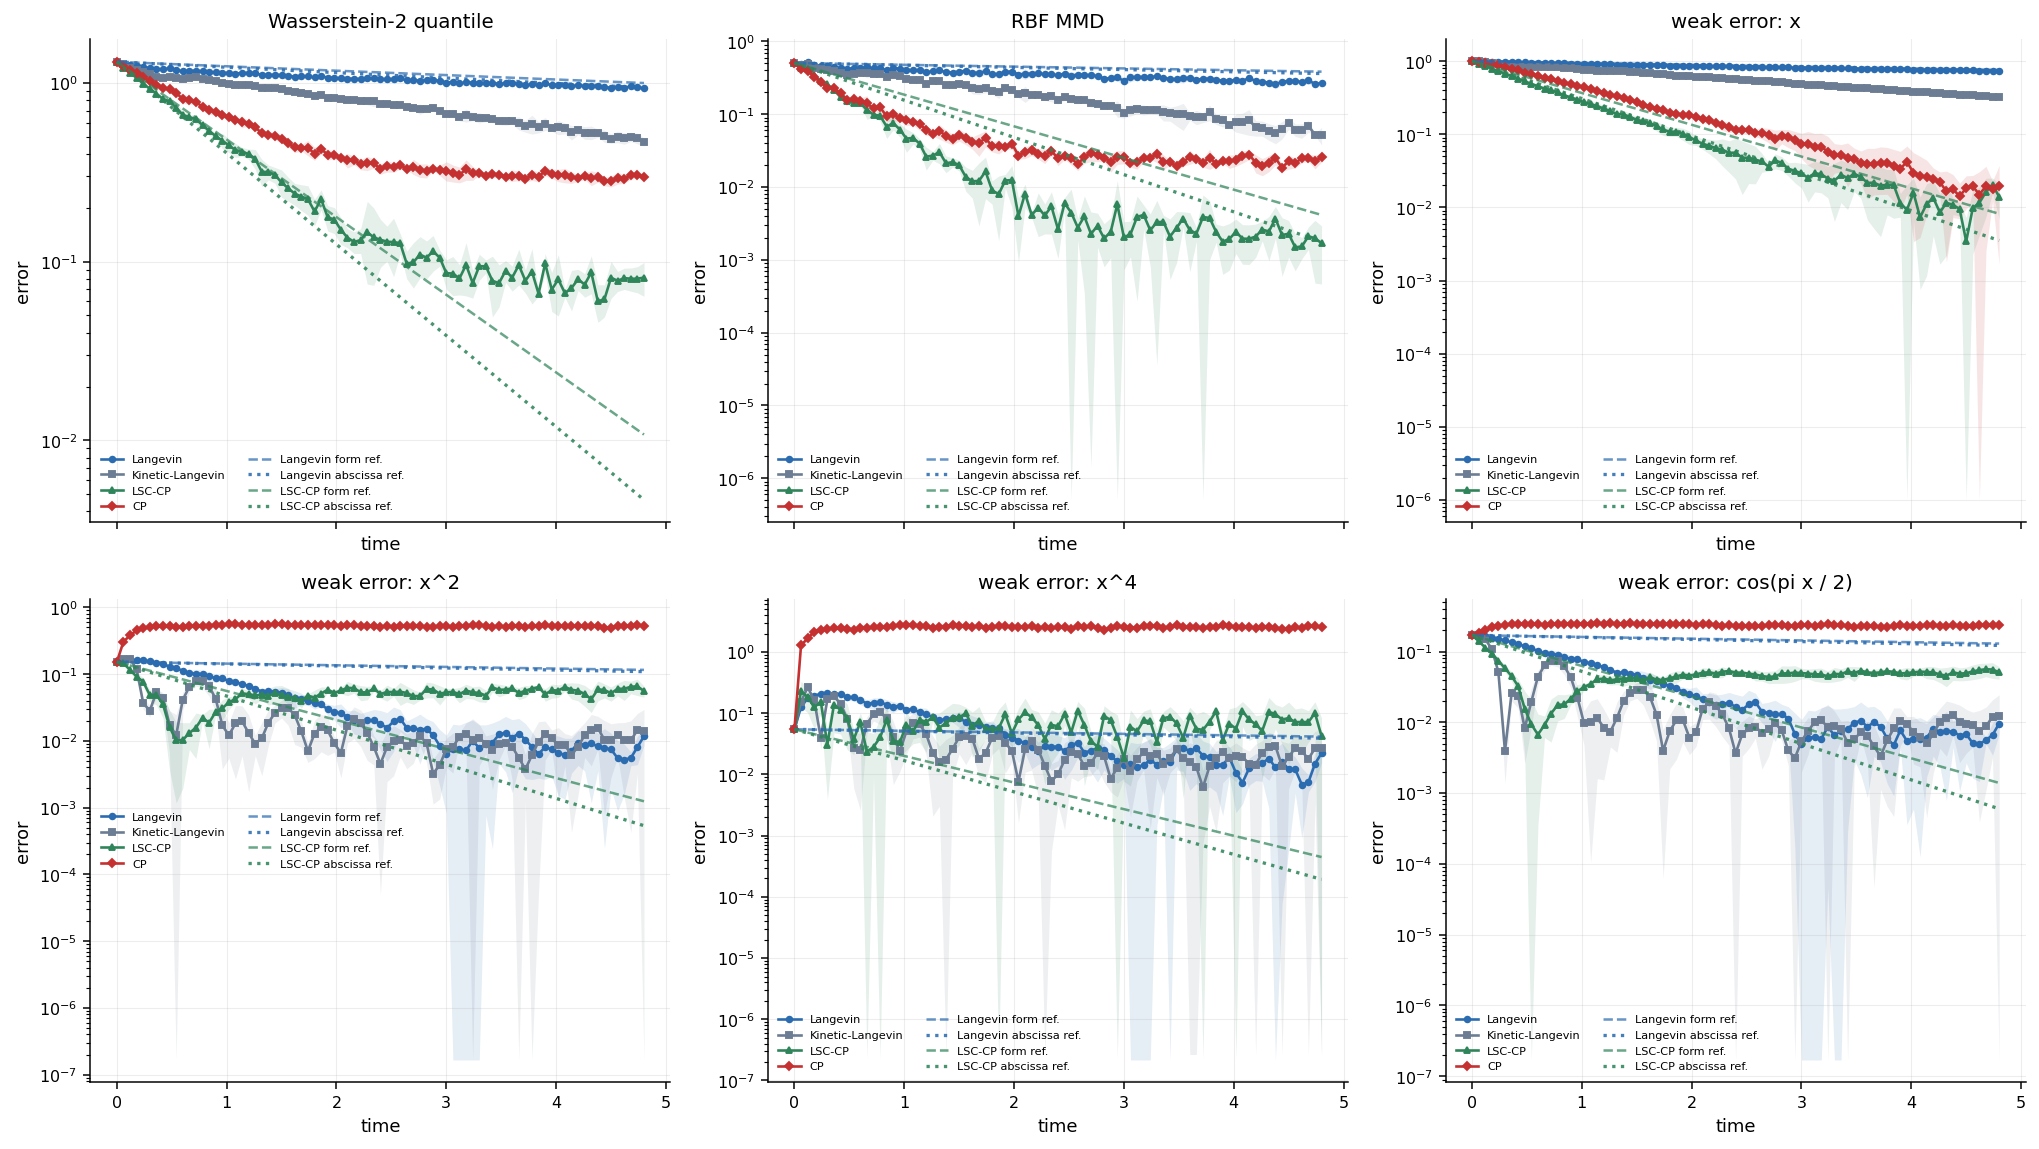

In [11]:
def w2_distance_1d_quantile(x, y, max_points=5000, rng=None):
    rng = np.random.default_rng(777) if rng is None else rng
    x = np.asarray(x); y = np.asarray(y)
    n = int(min(len(x), len(y), max_points))
    if len(x) > n:
        x = rng.choice(x, size=n, replace=False)
    if len(y) > n:
        y = rng.choice(y, size=n, replace=False)
    xs = np.sort(x); ys = np.sort(y)
    return float(np.sqrt(np.mean((xs - ys)**2)))

def weak_observable_table_1d(all_runs, target_grid, p_grid, dxw_grid, target_samples, methods, label_prefix):
    weak_fns = {
        "x": lambda z: z,
        "x2": lambda z: z**2,
        "x4": lambda z: z**4,
        "cos_pi_x_over_2": lambda z: np.cos(0.5*np.pi*z),
    }
    target_vals = {name: float(np.sum(fn(target_grid)*p_grid*dxw_grid)) for name, fn in weak_fns.items()}
    rows=[]
    for r in all_runs:
        for t, xs in zip(r["times"], r["samples"]):
            row = dict(method=r["method"], seed=r["seed"], time=float(t))
            row["W2"] = w2_distance_1d_quantile(xs, target_samples, rng=np.random.default_rng(make_rng_seed(GLOBAL_SEED, 601, r["seed"], int(1000*t))))
            row["MMD"] = mmd_rbf_1d(xs, target_samples, bandwidth=0.65, max_points=900 if PROFILE != "paper" else 1600,
                                     rng=np.random.default_rng(make_rng_seed(GLOBAL_SEED, 602, r["seed"], int(1000*t))))
            for name, fn in weak_fns.items():
                row[f"weak_{name}"] = abs(float(np.mean(fn(xs))) - target_vals[name])
            rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(TABDIR / f"{label_prefix}_rich_metrics_weak_errors.csv", index=False)
    display(pd.DataFrame([target_vals], index=["target_expectation"]))

    fig, ax = plt.subplots(2, 3, figsize=FIGSIZE_GRID, sharex=True)
    ax = ax.ravel()
    panels = [
        ("W2", "Wasserstein-2 quantile"),
        ("MMD", "RBF MMD"),
        ("weak_x", "weak error: x"),
        ("weak_x2", "weak error: x^2"),
        ("weak_x4", "weak error: x^4"),
        ("weak_cos_pi_x_over_2", "weak error: cos(pi x / 2)"),
    ]
    for j, (metric, title) in enumerate(panels):
        for m in methods:
            plot_metric_with_ci(ax[j], df, m, metric, logy=True, lw=1.4)
        for m in [mm for mm in ["Langevin", "LSC-CP"] if mm in methods]:
            add_rate_reference_lines(ax[j], df, metric, m,
                                     form_rate=gap_main.get(m, np.nan),
                                     abscissa_rate=globals().get("abscissa_main", {}).get(m, np.nan),
                                     logy=True)
        ax[j].set_title(title)
        ax[j].set_xlabel("time"); ax[j].set_ylabel("error")
        ax[j].legend(fontsize=6, ncol=2)
    savefig(fig, FIGDIR, f"{label_prefix}_fig04d_rich_metrics_weak_errors")
    plt.show()
    return df

double_rich_metrics = weak_observable_table_1d(all_runs, target_grid, p_grid, dxw_grid, target_samples, methods, "doublewell")


## Diagnostic: observed exponential decay-rate fit

The form-gap and abscissa lines are visual rate references.  This cell fits a simple log-linear decay rate from empirical mean curves on a middle-time window.  The reported standard error is an ordinary regression diagnostic and does not include all Monte Carlo uncertainty, time correlation, or reference-sample noise.  The seed-level confidence bands above remain the primary uncertainty visualization.


In [12]:
rate_fit_df = fit_observed_decay_rates(
    metrics, methods, ["W1", "CDF_sup", "well_TV", "L1_pdf"],
    t_min_frac=0.25, t_max_frac=0.85
)
rate_fit_df.to_csv(TABDIR/"doublewell_observed_decay_rate_fits.csv", index=False)
display(rate_fit_df)


seed_rate_summary_df, seed_rate_by_seed_df = fit_seed_level_decay_rates(
    metrics, methods, ["W1", "CDF_sup", "well_TV", "L1_pdf"],
    t_min_frac=0.25, t_max_frac=0.85
)
seed_rate_summary_df.to_csv(TABDIR/"doublewell_observed_decay_rate_seed_level_summary.csv", index=False)
seed_rate_by_seed_df.to_csv(TABDIR/"doublewell_observed_decay_rate_seed_level_by_seed.csv", index=False)
print("Seed-level decay-rate summary.  Its SE is across fitted seed-level slopes; NaN when only one seed is available.")
display(seed_rate_summary_df)


,method,metric,r_obs,r_obs_se,n_fit,t_min,t_max
0,Langevin,W1,0.058571,0.000431,49,1.2,4.08
1,Langevin,CDF_sup,0.057741,0.000338,49,1.2,4.08
2,Langevin,well_TV,0.055015,0.000378,49,1.2,4.08
3,Langevin,L1_pdf,0.055221,0.000473,49,1.2,4.08
4,Kinetic-Langevin,W1,0.239108,0.001205,49,1.2,4.08
5,Kinetic-Langevin,CDF_sup,0.235769,0.000542,49,1.2,4.08
6,Kinetic-Langevin,well_TV,0.236164,0.000531,49,1.2,4.08
7,Kinetic-Langevin,L1_pdf,0.207015,0.001094,49,1.2,4.08
8,LSC-CP,W1,0.556982,0.025615,49,1.2,4.08
9,LSC-CP,CDF_sup,0.416161,0.038345,49,1.2,4.08


Seed-level decay-rate summary.  Its SE is across fitted seed-level slopes; NaN when only one seed is available.


,method,metric,r_obs,r_obs_se,r_obs_seed_std,n_seed_fit,t_min,t_max
0,Langevin,W1,0.058616,0.003409,0.006818,4,1.2,4.08
1,Langevin,CDF_sup,0.057795,0.002691,0.005382,4,1.2,4.08
2,Langevin,well_TV,0.055063,0.002607,0.005215,4,1.2,4.08
3,Langevin,L1_pdf,0.055260,0.002354,0.004709,4,1.2,4.08
4,Kinetic-Langevin,W1,0.240154,0.013234,0.026467,4,1.2,4.08
5,Kinetic-Langevin,CDF_sup,0.236633,0.011591,0.023183,4,1.2,4.08
6,Kinetic-Langevin,well_TV,0.236995,0.011322,0.022645,4,1.2,4.08
7,Kinetic-Langevin,L1_pdf,0.207520,0.008159,0.016319,4,1.2,4.08
8,LSC-CP,W1,0.558626,0.041973,0.083946,4,1.2,4.08
9,LSC-CP,CDF_sup,0.417629,0.028556,0.057112,4,1.2,4.08


## Diagnostic: compact rate comparison table

This table puts three different rate quantities side by side: the form-gap reference rate, the finite-dimensional generator-abscissa diagnostic, and the fitted observed decay rate from the selected Monte Carlo metric.  They are intentionally shown together, but they are not the same mathematical object.

The form gap is a conservative $$L^2(\mu)$$ reference rate for the diagonal form.  The abscissa is a finite-dimensional nonreversible-generator diagnostic with its own stationarity checks.  The observed fit is metric-dependent and finite-time; it is not a theorem-level bound.

Note: in the bar chart below, colors encode rate type rather than sampler identity; sampler identity is on the x-axis.  This avoids duplicating the method-color convention used in trajectory and density panels.

When seed-level fits are available, the reported observed-rate SE is computed across seed-level fitted slopes rather than from time-point OLS residuals.



,method,primary_metric,form_gap,generator_abscissa,r_obs,r_obs_se,n_seed_fit,fit_t_min,fit_t_max
0,Langevin,well_TV,0.056863,0.069358,0.055063,0.002607,4,1.2,4.08
1,Kinetic-Langevin,well_TV,NaN,NaN,0.236995,0.011322,4,1.2,4.08
2,LSC-CP,well_TV,1.001094,1.176482,0.999211,0.155552,4,1.2,4.08
3,CP,well_TV,NaN,NaN,1.037393,0.265580,4,1.2,4.08


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig03b_rate_comparison_table.pdf


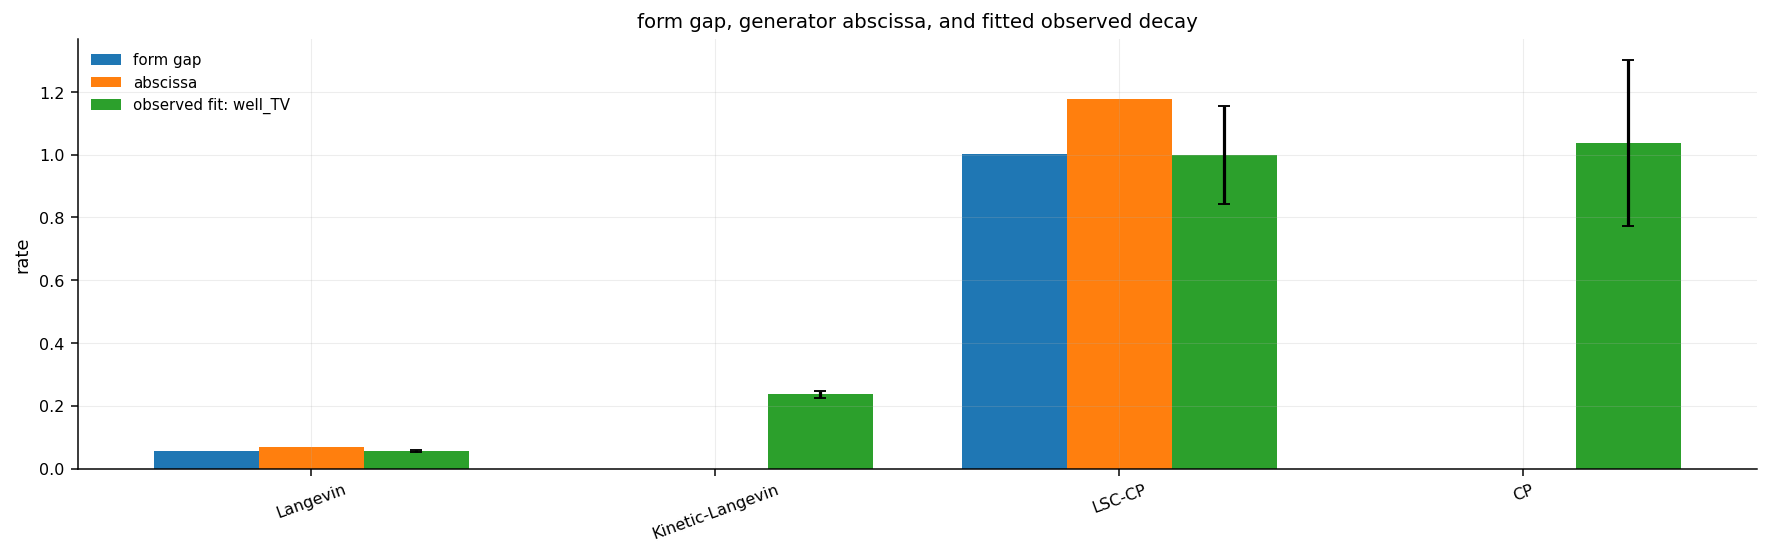

In [13]:

PRIMARY_RATE_METRIC = "well_TV"
rows = []
for m in methods:
    rate_source_df = seed_rate_summary_df if "seed_rate_summary_df" in globals() else rate_fit_df
    sub = rate_source_df[(rate_source_df.method == m) & (rate_source_df.metric == PRIMARY_RATE_METRIC)]
    rows.append(dict(
        method=m,
        primary_metric=PRIMARY_RATE_METRIC,
        form_gap=float(gap_main.get(m, np.nan)),
        generator_abscissa=float(abscissa_main.get(m, np.nan)) if 'abscissa_main' in globals() else np.nan,
        r_obs=float(sub.r_obs.iloc[0]) if len(sub) else np.nan,
        r_obs_se=float(sub.r_obs_se.iloc[0]) if len(sub) else np.nan,
        n_seed_fit=int(sub.n_seed_fit.iloc[0]) if len(sub) and "n_seed_fit" in sub.columns and np.isfinite(sub.n_seed_fit.iloc[0]) else np.nan,
        fit_t_min=float(sub.t_min.iloc[0]) if len(sub) and 't_min' in sub.columns else np.nan,
        fit_t_max=float(sub.t_max.iloc[0]) if len(sub) and 't_max' in sub.columns else np.nan,
    ))
rate_comparison_df = pd.DataFrame(rows)
rate_comparison_df.to_csv(TABDIR / "doublewell_rate_comparison.csv", index=False)
display(rate_comparison_df)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_ROW)
x = np.arange(len(rate_comparison_df))
w = 0.26
ax.bar(x - w, rate_comparison_df.form_gap, width=w, label="form gap")
ax.bar(x, rate_comparison_df.generator_abscissa, width=w, label="abscissa")
ax.bar(x + w, rate_comparison_df.r_obs, width=w, yerr=rate_comparison_df.r_obs_se, capsize=3, label=f"observed fit: {PRIMARY_RATE_METRIC}")
ax.set_xticks(x); ax.set_xticklabels(rate_comparison_df.method, rotation=20)
ax.set_ylabel("rate")
ax.set_title("form gap, generator abscissa, and fitted observed decay")
ax.legend(fontsize=8)
savefig(fig, FIGDIR, "fig03b_rate_comparison_table")
plt.show()


## Diagnostic: time-step sensitivity for observed decay

This cell checks whether the observed Monte Carlo decay is stable under a small sweep of the Euler time step.  It uses fewer particles and only the main diagnostic observables, so it is not a replacement for the main simulation; it is a discretization-bias sanity check.


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig04c_dt_sensitivity.pdf


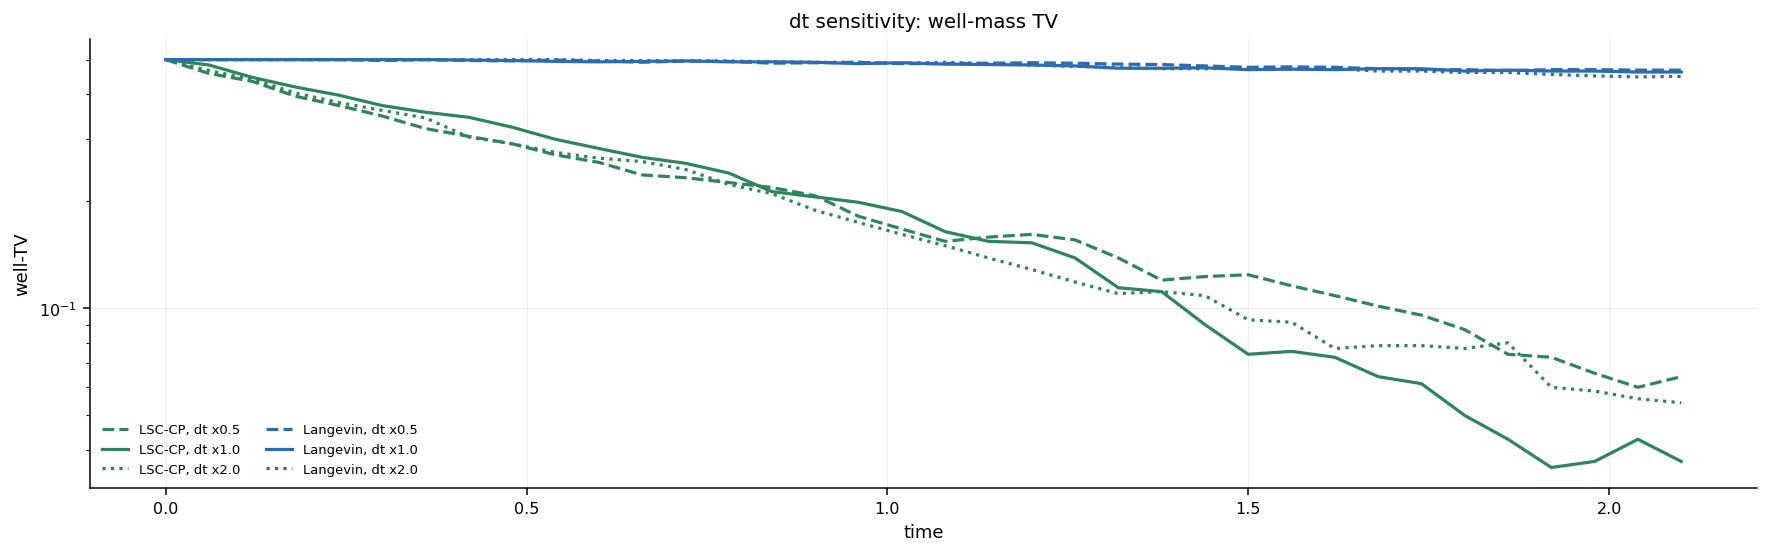

,method,dt,dt_scale,time,well_TV
35,Langevin,0.0015,0.5,2.1,0.467143
71,LSC-CP,0.0015,0.5,2.1,0.064286
107,Langevin,0.0030,1.0,2.1,0.461429
143,LSC-CP,0.0030,1.0,2.1,0.037143
179,Langevin,0.0060,2.0,2.1,0.448571
215,LSC-CP,0.0060,2.0,2.1,0.054286


In [14]:
def run_dt_sensitivity_double():
    if PROFILE == "smoke":
        dt_scales = [1.0]
        n_particles = min(40, CFG["n_particles"])
        base_steps = min(20, CFG["n_steps"])
    else:
        dt_scales = [0.5, 1.0, 2.0]
        n_particles = min(700, CFG["n_particles"])
        base_steps = min(700, CFG["n_steps"])
    rows=[]
    rng=np.random.default_rng(GLOBAL_SEED+909)
    x0_base=make_initial_cloud_1d(rng, center=-1.0, scale=0.075, n=n_particles, clip=x_clip)
    for scale in dt_scales:
        dt=float(CFG["dt"]*scale)
        n_steps=max(4, int(round(base_steps/scale)))
        rec=max(1, int(round(CFG["record_every"]/scale)))
        for m in ["Langevin", "LSC-CP"]:
            rr=simulate_method(m, make_rng_seed(GLOBAL_SEED, 909, int(scale*1000), 0 if m=="Langevin" else 1),
                               x0_base.copy(), seed_id=f"dt{scale}", jump=jump_main, score_cache=score_cache,
                               dt_override=dt, n_steps_override=n_steps, rec_override=rec)
            for t,xs in zip(rr["times"], rr["samples"]):
                wm=well_masses_2well(xs)
                rows.append(dict(method=m, dt=dt, dt_scale=scale, time=t,
                                 well_TV=0.5*np.sum(np.abs(wm-target_well))))
    sens=pd.DataFrame(rows)
    sens.to_csv(TABDIR/"doublewell_dt_sensitivity.csv", index=False)
    fig,ax=plt.subplots(1,1,figsize=FIGSIZE_ROW)
    for (m,scale),sub in sens.groupby(["method","dt_scale"]):
        c=method_color(m)
        ls="-" if scale==1.0 else ("--" if scale<1 else ":")
        ax.semilogy(sub.time, np.maximum(sub.well_TV,1e-12), ls=ls, color=c, lw=1.7, label=f"{m}, dt x{scale}")
    ax.set_title("dt sensitivity: well-mass TV")
    ax.set_xlabel("time"); ax.set_ylabel("well-TV")
    ax.legend(fontsize=7, ncol=2)
    savefig(fig, FIGDIR, "fig04c_dt_sensitivity")
    plt.show()
    display(sens.groupby(["method","dt_scale"]).tail(1))
    return sens

dt_sensitivity_df = run_dt_sensitivity_double()


## 4a. Low-temperature epsilon sweep

The epsilon sweep is the central double-well result.  It compares the
barrier-limited local dynamics with the target-compatible corrected jump as
the Gibbs temperature decreases.  The tables record target well masses,
well-TV trajectories, form gaps, generator abscissae, clipping diagnostics,
and reached or censored mixing times.  The figure uses only direct rates,
times, and well-TV thresholds.


,eps,method,lambda0,deltaV,mixing_tol,mixing_time,mixing_time_reached,chi2_mixing_tol,chi2_mixing_time,chi2_mixing_time_reached,...,form_gap,generator_abscissa,stationary_residual_l1,row_sum_abs_max,stationary_bias_l1,negative_stationary_mass,arrhenius_ref_rate,poly_ref_rate,arrhenius_ref_time,poly_ref_time
14,0.300,LSC-CP,1.0,0.25,0.1,1.26,True,0.055667,1.44,True,...,1.292462,1.449773,1.219894,1.818989e-12,0.029232,0.000000e+00,0.434598,0.547723,2.300976,1.825742
12,0.240,LSC-CP,1.0,0.25,0.1,1.26,True,0.068335,1.26,True,...,1.207477,1.372538,1.282131,1.818989e-12,0.032363,0.000000e+00,0.352866,0.489898,2.833936,2.041241
10,0.200,LSC-CP,1.0,0.25,0.1,1.44,True,0.058309,1.62,True,...,1.142440,1.312323,1.330446,2.040146e-12,0.035173,0.000000e+00,0.286505,0.447214,3.490343,2.236068
8,0.160,LSC-CP,1.0,0.25,0.1,1.62,True,0.064518,1.62,True,...,1.069822,1.242933,1.387993,1.950440e-12,0.038749,0.000000e+00,0.209611,0.400000,4.770733,2.500000
6,0.125,LSC-CP,1.0,0.25,0.1,1.44,True,0.074466,1.62,True,...,1.001465,1.173413,1.452076,1.818989e-12,0.043092,0.000000e+00,0.135335,0.353553,7.389056,2.828427
4,0.100,LSC-CP,1.0,0.25,0.1,1.62,True,0.066952,1.98,True,...,0.954556,1.119254,1.511081,9.094947e-13,0.046157,0.000000e+00,0.082085,0.316228,12.182494,3.162278
2,0.080,LSC-CP,1.0,0.25,0.1,1.80,True,0.079595,2.16,True,...,0.923053,1.075078,1.596582,9.094947e-13,0.049824,0.000000e+00,0.043937,0.282843,22.759895,3.535534
0,0.065,LSC-CP,1.0,0.25,0.1,1.80,True,0.121315,1.80,True,...,0.910099,1.044108,1.704659,1.818989e-12,0.053216,0.000000e+00,0.021362,0.254951,46.812668,3.922323
15,0.300,Langevin,1.0,0.25,0.1,7.02,True,0.055667,6.84,True,...,0.238086,0.249603,0.391564,2.273737e-13,0.021615,1.272997e-15,0.434598,0.547723,2.300976,1.825742
13,0.240,Langevin,1.0,0.25,0.1,10.08,True,0.068335,9.54,True,...,0.176872,0.188127,0.412980,1.136868e-13,0.025182,8.900464e-15,0.352866,0.489898,2.833936,2.041241


,method,quantity,fit_family,model,n,prefactor,barrier,r2_log,equation,exponent
0,Langevin,form_gap,arrhenius,arrhenius,8,0.535953,0.272147,0.997446,0.536 e^{-0.272/eps},NaN
1,Langevin,form_gap,polynomial,polynomial,8,3.853222,NaN,0.975587,3.85 eps^{2.12},2.123621
2,Langevin,mixing_time,arrhenius,arrhenius,8,3.126006,0.264979,0.998282,3.13 e^{0.265/eps},NaN
3,Langevin,mixing_time,polynomial,polynomial,8,0.469040,NaN,0.964976,0.469 eps^{-2.06},2.055550
4,Langevin,chi2_mixing_time,arrhenius,arrhenius,8,3.411067,0.241140,0.994010,3.41 e^{0.241/eps},NaN
5,Langevin,chi2_mixing_time,polynomial,polynomial,8,0.588689,NaN,0.976973,0.589 eps^{-1.89},1.886255
6,LSC-CP,form_gap,arrhenius,arrhenius,8,1.327284,0.028447,0.870041,1.33 e^{-0.0284/eps},NaN
7,LSC-CP,form_gap,polynomial,polynomial,8,1.681591,NaN,0.973824,1.68 eps^{0.237},0.237460
8,LSC-CP,mixing_time,arrhenius,arrhenius,8,1.192797,0.029729,0.794995,1.19 e^{0.0297/eps},NaN
9,LSC-CP,mixing_time,polynomial,polynomial,8,0.943046,NaN,0.845381,0.943 eps^{-0.242},0.241886


/var/folders/b4/vldg5wlj5ngdmvfy9djxzsx00000gn/T/ipykernel_65038/2322747899.py:91: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig04a_epsilon_sweep_scaling_summary.pdf


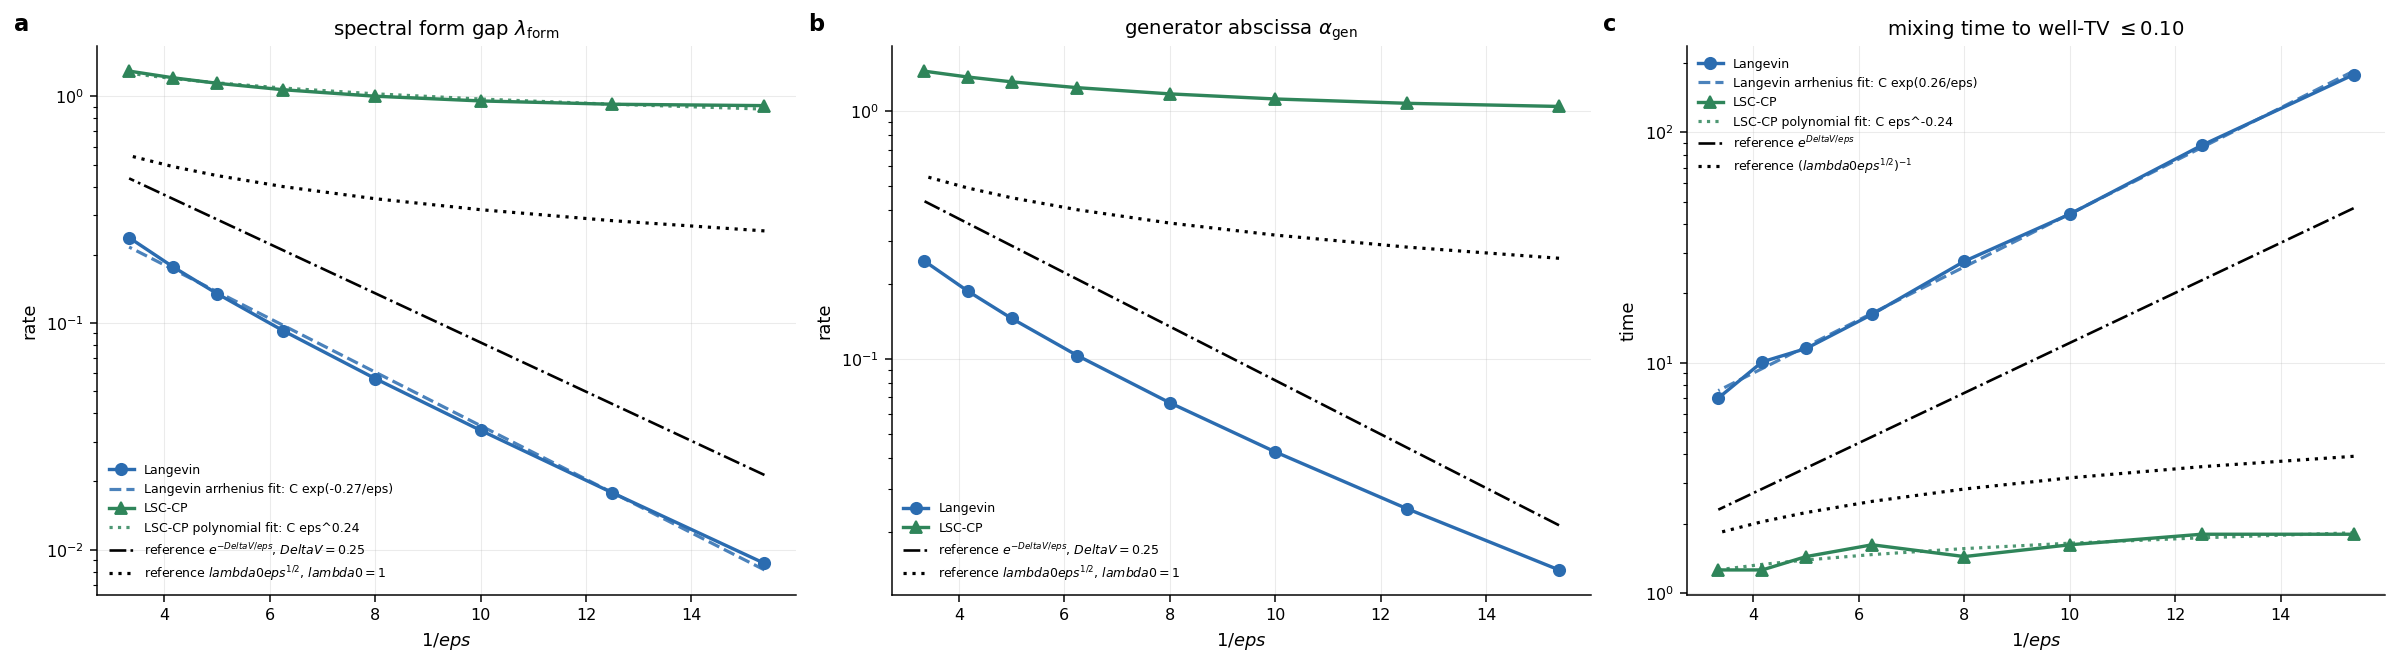

In [15]:

# ---------------------------------------------------------------------
# Epsilon sweep for Example 1 only: form gap, generator abscissa,
# and empirical mixing time.  The plotting is intentionally simple:
# one panel per quantity, with fitted scaling laws.
# ---------------------------------------------------------------------
DOUBLEWELL_BARRIER = 0.25  # V(0)-V(-1)=1/4 for V=x^4/4-x^2/2.
DOUBLEWELL_LAMBDA0 = float(jump_main.lam)

if PROFILE == "smoke":
    EPS_SWEEP_CFG = dict(
        eps_values=[0.28, 0.16],
        gap_N=80, gen_N=55, score_grid_N=260,
        n_particles=120, n_seeds=1, dt=0.006,
        t_min=3.0, t_max_cap=10.0, record_dt=0.06,
        theta_n=4, quad_r=3,
        horizon_arrhenius_prefactor=4.0,
        horizon_poly_prefactor=3.0,
        mixing_tol=0.10,
    )
elif PROFILE == "paperlite":
    EPS_SWEEP_CFG = dict(
        eps_values=[0.30, 0.24, 0.20, 0.16, 0.125, 0.10, 0.08, 0.065],
        gap_N=260, gen_N=150, score_grid_N=700,
        n_particles=900, n_seeds=2, dt=0.005,
        t_min=22.0, t_max_cap=180.0, record_dt=0.18,
        theta_n=14, quad_r=7,
        horizon_arrhenius_prefactor=7.0,
        horizon_poly_prefactor=5.0,
        mixing_tol=0.10,
    )
else:
    EPS_SWEEP_CFG = dict(
        eps_values=[0.34, 0.30, 0.26, 0.22, 0.18, 0.15, 0.125, 0.10, 0.08, 0.065],
        gap_N=420, gen_N=220, score_grid_N=1000,
        n_particles=2200, n_seeds=5, dt=0.0045,
        t_min=32.0, t_max_cap=260.0, record_dt=0.24,
        theta_n=20, quad_r=9,
        horizon_arrhenius_prefactor=8.0,
        horizon_poly_prefactor=6.0,
        mixing_tol=0.10,
    )


def make_eps_logp_functions(eps_val):
    def _logp_eps(x):
        return -V(np.asarray(x)) / eps_val
    def _grad_logp_eps(x):
        return -dV(np.asarray(x)) / eps_val
    return _logp_eps, _grad_logp_eps


def target_objects_for_eps(eps_val, grid_N=None):
    grid_N = EPS_SWEEP_CFG["score_grid_N"] if grid_N is None else int(grid_N)
    grid = np.linspace(x_clip[0], x_clip[1], grid_N)
    logp_e, gradlogp_e = make_eps_logp_functions(eps_val)
    p_e, w_e, _ = normalize_pdf_grid(grid, logp_e(grid))
    cdf_e = cdf_from_pdf(grid, p_e)
    target_well_e = np.array([
        np.sum((grid < 0) * p_e * w_e),
        np.sum((grid >= 0) * p_e * w_e),
    ])
    density_bandwidth_e = target_local_scott_bandwidth(grid, p_e, EPS_SWEEP_CFG["n_particles"])
    chi_lo_e, chi_hi_e, chi_omitted_e = central_interval_from_cdf(grid, cdf_e, mass=0.98)
    chi_mask_e = (grid >= chi_lo_e) & (grid <= chi_hi_e)
    density_config_e = DensityDiagnosticConfig(
        bandwidth=float(density_bandwidth_e),
        chi_interval=(float(chi_lo_e), float(chi_hi_e)),
        chi_omitted_mass=float(chi_omitted_e),
        chi_target_min=float(np.min(p_e[chi_mask_e])),
    )
    return grid, p_e, w_e, cdf_e, target_well_e, logp_e, gradlogp_e, density_bandwidth_e, density_config_e


def first_crossing_time(times, values, tol):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    ok = np.isfinite(values) & (values <= tol)
    if not np.any(ok):
        return np.nan, False
    ids = np.where(ok)[0]
    for idx in ids:
        # Require persistence for one more recorded point when possible.
        if idx + 1 < len(values):
            if np.all(values[idx:min(len(values), idx+2)] <= tol):
                return float(times[idx]), True
        else:
            return float(times[idx]), True
    return float(times[ids[0]]), True


def mixing_horizon_for_eps(eps_val):
    arr_guess = EPS_SWEEP_CFG["horizon_arrhenius_prefactor"] * np.exp(DOUBLEWELL_BARRIER / eps_val)
    poly_guess = EPS_SWEEP_CFG["horizon_poly_prefactor"] / max(DOUBLEWELL_LAMBDA0 * np.sqrt(eps_val), 1e-12)
    return float(min(EPS_SWEEP_CFG["t_max_cap"], max(EPS_SWEEP_CFG["t_min"], arr_guess, poly_guess)))


def simulate_eps_sweep_method(
    method,
    eps_val,
    rng_seed,
    x0,
    logp_e,
    gradlogp_e,
    target_well_e,
    score_grid_e,
    grid_e,
    p_e,
    density_bandwidth_e,
    density_config_e,
    chi2_mixing_tol_e,
    chi2_bias_floor_mean_e,
    chi2_bias_floor_max_e,
):
    rng = np.random.default_rng(rng_seed)
    x = np.asarray(x0, dtype=float).copy()
    dt = float(EPS_SWEEP_CFG["dt"])
    t_max = mixing_horizon_for_eps(eps_val)
    n_steps = int(round(t_max / dt))
    rec = max(1, int(round(EPS_SWEEP_CFG["record_dt"] / dt)))
    jump = ShellJump1D(a=jump_main.a, h=jump_main.h, lam=jump_main.lam,
                       quad_r=EPS_SWEEP_CFG["quad_r"], name="eps-sweep-shell")
    if method == "LSC-CP":
        sg, sv = score_grid_e
    rows = []
    clip_sum = 0.0; clip_count = 0; clip_max = 0.0
    for k in range(n_steps+1):
        if k % rec == 0:
            wm = well_masses_2well(x)
            kde, _ = binned_gaussian_kde_on_grid_with_diagnostics(x, grid_e, density_bandwidth_e)
            density_metrics = density_metric_bundle(kde, p_e, grid_e, density_config_e, samples=x)
            rows.append(dict(
                time=float(k*dt),
                well_TV=float(0.5*np.sum(np.abs(wm-target_well_e))),
                left_mass=float(wm[0]),
                right_mass=float(wm[1]),
                t_max=t_max,
                target_left_mass=float(target_well_e[0]),
                target_right_mass=float(target_well_e[1]),
                chi2_mixing_tol=float(chi2_mixing_tol_e),
                chi2_bias_floor_mean=float(chi2_bias_floor_mean_e),
                chi2_bias_floor_max=float(chi2_bias_floor_max_e),
                **{k_: float(v_) for k_, v_ in density_metrics.items()},
            ))
        if k == n_steps:
            break
        if method == "Langevin":
            drift = eps_val * gradlogp_e(x)
            x = x + dt*drift + np.sqrt(2*eps_val*dt)*rng.standard_normal(x.shape)
        elif method == "LSC-CP":
            S = np.interp(np.clip(x, sg[0], sg[-1]), sg, sv)
            drift = eps_val * gradlogp_e(x) + S
            x = x + dt*drift/(1.0 + dt*np.abs(drift)) + np.sqrt(2*eps_val*dt)*rng.standard_normal(x.shape)
            x, _ = apply_compound_poisson_jumps_1d(x, jump, rng, dt)
        else:
            raise ValueError(method)
        x, cfrac = safety_clip_1d(x, method, x_clip)
        clip_sum += cfrac; clip_max = max(clip_max, cfrac); clip_count += 1
    out = pd.DataFrame(rows)
    out["method"] = method
    out["eps"] = float(eps_val)
    out["rng_seed"] = int(rng_seed)
    out["clip_fraction_mean"] = float(clip_sum/max(1, clip_count))
    out["clip_fraction_max"] = float(clip_max)
    return out


def _log_linear_fit(z, log_y):
    z = np.asarray(z, dtype=float)
    log_y = np.asarray(log_y, dtype=float)
    X = np.column_stack([np.ones_like(z), z])
    beta, *_ = np.linalg.lstsq(X, log_y, rcond=None)
    pred = X @ beta
    ss_res = float(np.sum((log_y - pred)**2))
    ss_tot = float(np.sum((log_y - np.mean(log_y))**2))
    r2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return beta, pred, r2


def fit_scaling_models(eps_arr, y_arr, *, kind):
    eps_arr = np.asarray(eps_arr, dtype=float)
    y_arr = np.asarray(y_arr, dtype=float)
    mask = np.isfinite(eps_arr) & np.isfinite(y_arr) & (eps_arr > 0) & (y_arr > 0)
    eps_use = eps_arr[mask]
    y_use = y_arr[mask]
    if len(eps_use) < 3:
        return None, None
    logy = np.log(y_use)

    if kind == "rate":
        beta_arr, pred_arr, r2_arr = _log_linear_fit(1.0/eps_use, logy)
        beta_poly, pred_poly, r2_poly = _log_linear_fit(np.log(eps_use), logy)
        arr_fit = dict(model="arrhenius", n=len(eps_use), prefactor=float(np.exp(beta_arr[0])),
                       barrier=float(-beta_arr[1]), r2_log=float(r2_arr),
                       equation=rf"{np.exp(beta_arr[0]):.3g} e^{{-{(-beta_arr[1]):.3g}/eps}}")
        poly_fit = dict(model="polynomial", n=len(eps_use), prefactor=float(np.exp(beta_poly[0])),
                        exponent=float(beta_poly[1]), r2_log=float(r2_poly),
                        equation=rf"{np.exp(beta_poly[0]):.3g} eps^{{{beta_poly[1]:.3g}}}")
        return arr_fit, poly_fit
    elif kind == "time":
        beta_arr, pred_arr, r2_arr = _log_linear_fit(1.0/eps_use, logy)
        beta_poly, pred_poly, r2_poly = _log_linear_fit(np.log(eps_use), logy)
        arr_fit = dict(model="arrhenius", n=len(eps_use), prefactor=float(np.exp(beta_arr[0])),
                       barrier=float(beta_arr[1]), r2_log=float(r2_arr),
                       equation=rf"{np.exp(beta_arr[0]):.3g} e^{{{beta_arr[1]:.3g}/eps}}")
        poly_fit = dict(model="polynomial", n=len(eps_use), prefactor=float(np.exp(beta_poly[0])),
                        exponent=float(-beta_poly[1]), r2_log=float(r2_poly),
                        equation=rf"{np.exp(beta_poly[0]):.3g} eps^{{{beta_poly[1]:.3g}}}")
        return arr_fit, poly_fit
    else:
        raise ValueError(kind)


def eval_fit_curve(eps_grid, fit_dict, *, kind):
    eps_grid = np.asarray(eps_grid, dtype=float)
    if fit_dict is None:
        return np.full_like(eps_grid, np.nan, dtype=float)
    if fit_dict["model"] == "arrhenius":
        sign = -1.0 if kind == "rate" else 1.0
        return fit_dict["prefactor"] * np.exp(sign * fit_dict["barrier"] / eps_grid)
    if fit_dict["model"] == "polynomial":
        exponent = fit_dict.get("exponent", 0.0)
        if kind == "rate":
            return fit_dict["prefactor"] * eps_grid**exponent
        return fit_dict["prefactor"] * eps_grid**(-exponent)
    raise ValueError(fit_dict)


def build_fit_table(summary):
    rows = []
    quantities = [
        ("form_gap", "rate"),
        ("mixing_time", "time"),
        ("chi2_mixing_time", "time"),
    ]
    for method in ["Langevin", "LSC-CP"]:
        for quantity, kind in quantities:
            sub = summary[(summary.method == method) & np.isfinite(summary[quantity]) & (summary[quantity] > 0)].copy()
            if quantity == "mixing_time":
                sub = sub[sub.mixing_time_reached]
            if quantity == "chi2_mixing_time":
                sub = sub[sub.chi2_mixing_time_reached]
            arr_fit, poly_fit = fit_scaling_models(sub["eps"].to_numpy(), sub[quantity].to_numpy(), kind=kind)
            if arr_fit is not None:
                rows.append(dict(method=method, quantity=quantity, fit_family="arrhenius", **arr_fit))
            else:
                rows.append(dict(method=method, quantity=quantity, fit_family="arrhenius", n=len(sub), prefactor=np.nan, barrier=np.nan, r2_log=np.nan, equation=""))
            if poly_fit is not None:
                rows.append(dict(method=method, quantity=quantity, fit_family="polynomial", **poly_fit))
            else:
                rows.append(dict(method=method, quantity=quantity, fit_family="polynomial", n=len(sub), prefactor=np.nan, exponent=np.nan, r2_log=np.nan, equation=""))
    fit_df = pd.DataFrame(rows)
    fit_df.to_csv(TABDIR/"doublewell_epsilon_sweep_model_fits.csv", index=False)
    return fit_df


def fit_lookup(fit_df, method, quantity, fit_family):
    sub = fit_df[(fit_df.method == method) & (fit_df.quantity == quantity) & (fit_df.fit_family == fit_family)]
    if len(sub) == 0:
        return None
    row = sub.iloc[0].to_dict()
    if fit_family == "arrhenius":
        return dict(model="arrhenius", prefactor=float(row.get("prefactor", np.nan)),
                    barrier=float(row.get("barrier", np.nan)), r2_log=float(row.get("r2_log", np.nan)),
                    equation=row.get("equation", ""))
    return dict(model="polynomial", prefactor=float(row.get("prefactor", np.nan)),
                exponent=float(row.get("exponent", np.nan)), r2_log=float(row.get("r2_log", np.nan)),
                equation=row.get("equation", ""))


def run_doublewell_epsilon_sweep():
    eps_values = [float(e) for e in EPS_SWEEP_CFG["eps_values"]]
    methods_sweep = ["Langevin", "LSC-CP"]
    gap_rows, gen_rows, sim_parts, chi2_bias_rows = [], [], [], []
    rng_init = np.random.default_rng(GLOBAL_SEED + 53001)
    for eps_val in eps_values:
        grid_e, p_e, w_e, cdf_e, target_well_e, logp_e, gradlogp_e, density_bandwidth_e, density_config_e = target_objects_for_eps(eps_val)
        bias_rows_e = estimate_kde_bias_floor(
            grid_e, p_e, density_bandwidth_e, EPS_SWEEP_CFG["n_particles"], density_config_e,
            n_replicates=6 if PROFILE != "smoke" else 3,
            seed=GLOBAL_SEED + 65000 + int(round(10000*eps_val)),
        )
        bias_df_e = pd.DataFrame(bias_rows_e)
        chi2_bias_floor_mean_e = float(bias_df_e["truncated_KDE_chi2"].mean())
        chi2_bias_floor_max_e = float(bias_df_e["truncated_KDE_chi2"].max())
        chi2_mixing_tol_e = float(max(0.05, 3.0 * chi2_bias_floor_max_e))
        chi2_bias_rows.append(dict(
            eps=float(eps_val), KDE_bandwidth=float(density_bandwidth_e),
            chi2_bias_floor_mean=chi2_bias_floor_mean_e,
            chi2_bias_floor_max=chi2_bias_floor_max_e,
            chi2_mixing_tol=chi2_mixing_tol_e,
            threshold_above_bias_floor=bool(chi2_mixing_tol_e > chi2_bias_floor_max_e),
        ))
        jump_e = ShellJump1D(a=jump_main.a, h=jump_main.h, lam=jump_main.lam,
                             quad_r=EPS_SWEEP_CFG["quad_r"], name="eps-sweep-shell")
        score_vals_e, score_diag_e = levy_score_1d_grid(
            grid_e, logp_e, jump_e, theta_n=EPS_SWEEP_CFG["theta_n"],
            log_clip=None, score_clip=None,
        )
        score_grid_e = (grid_e, score_vals_e)
        for method, jump in [("Langevin", None), ("LSC-CP", jump_e)]:
            gap, diag, *_ = full_gap_1d_form(
                logp_e, eps_val, CFG["gap_interval"][0], CFG["gap_interval"][1],
                N=int(EPS_SWEEP_CFG["gap_N"]), jump=jump,
            )
            gap_rows.append(dict(method=method, eps=eps_val, form_gap=float(gap),
                                 **{f"gap_{k}": v for k, v in diag.items() if k in ["N_active", "residual", "boundary_jump_mass_proxy", "retained_mass_before_renorm"]}))
            A, xg, mug, dxwg, score_diag = build_fd_generator_1d(
                logp_e, gradlogp_e, eps_val, CFG["gap_interval"][0], CFG["gap_interval"][1],
                int(EPS_SWEEP_CFG["gen_N"]), jump=jump,
                theta_n=max(4, min(int(EPS_SWEEP_CFG["theta_n"]), 14)),
            )
            absc, _ = generator_abscissa_from_A(A)
            ptilde, bias_l1, zero_eval, stat_diag = stationary_bias_from_generator(A, mug)
            gen_rows.append(dict(
                method=method, eps=eps_val, generator_abscissa=float(absc),
                row_sum_abs_max=float(np.max(np.abs(A.sum(axis=1)))),
                stationary_residual_l1=float(np.sum(np.abs(mug @ A))),
                stationary_residual_linf=float(np.max(np.abs(mug @ A))),
                stationary_bias_l1=float(bias_l1) if np.isfinite(bias_l1) else np.nan,
                negative_stationary_mass=float(stat_diag.get("stationary_vector_negative_mass", np.nan)),
                stationary_vector_min=float(stat_diag.get("stationary_vector_min", np.nan)),
                stationary_vector_warning=bool(stat_diag.get("stationary_vector_warning", False)),
                score_clip_fraction=float(score_diag.get("score_clip_fraction", 0.0)),
                logratio_clip_fraction=float(score_diag.get("logratio_clip_fraction", 0.0)),
            ))
        for s in range(int(EPS_SWEEP_CFG["n_seeds"])):
            x0 = make_initial_cloud_1d(rng_init, center=-1.0, scale=0.075,
                                       n=int(EPS_SWEEP_CFG["n_particles"]), clip=x_clip)
            for mi, method in enumerate(methods_sweep):
                seed = GLOBAL_SEED + 54100 + 1000*s + 10*mi + int(round(10000*eps_val))
                sim_parts.append(simulate_eps_sweep_method(
                    method, eps_val, seed, x0, logp_e, gradlogp_e, target_well_e, score_grid_e,
                    grid_e, p_e, density_bandwidth_e, density_config_e,
                    chi2_mixing_tol_e, chi2_bias_floor_mean_e, chi2_bias_floor_max_e,
                ))

    gap_df = pd.DataFrame(gap_rows)
    gen_df = pd.DataFrame(gen_rows)
    sim_df = pd.concat(sim_parts, ignore_index=True) if sim_parts else pd.DataFrame()
    gap_df.to_csv(TABDIR/"doublewell_epsilon_sweep_form_gaps.csv", index=False)
    gen_df.to_csv(TABDIR/"doublewell_epsilon_sweep_generator_abscissa.csv", index=False)
    sim_df.to_csv(TABDIR/"doublewell_epsilon_sweep_mixing_timeseries.csv", index=False)
    chi2_bias_df = pd.DataFrame(chi2_bias_rows)
    chi2_bias_df.to_csv(TABDIR/"doublewell_epsilon_sweep_chi2_bias_floor.csv", index=False)

    summary_rows = []
    for (eps_val, method), sub in sim_df.groupby(["eps", "method"]):
        mean_curve = sub.groupby("time")["well_TV"].mean().reset_index()
        chi_curve = sub.groupby("time")["truncated_KDE_chi2"].mean().reset_index()
        tmix, reached = first_crossing_time(mean_curve.time, mean_curve.well_TV, EPS_SWEEP_CFG["mixing_tol"])
        chi2_tol = float(sub["chi2_mixing_tol"].iloc[0])
        tmix_chi2, reached_chi2 = first_crossing_time(chi_curve.time, chi_curve.truncated_KDE_chi2, chi2_tol)
        tmax_used = float(sub["t_max"].iloc[0])
        summary_rows.append(dict(
            eps=float(eps_val), method=method,
            lambda0=DOUBLEWELL_LAMBDA0,
            deltaV=DOUBLEWELL_BARRIER,
            mixing_tol=float(EPS_SWEEP_CFG["mixing_tol"]),
            mixing_time=float(tmix) if np.isfinite(tmix) else np.nan,
            mixing_time_reached=bool(reached),
            chi2_mixing_tol=chi2_tol,
            chi2_mixing_time=float(tmix_chi2) if np.isfinite(tmix_chi2) else np.nan,
            chi2_mixing_time_reached=bool(reached_chi2),
            chi2_bias_floor_mean=float(sub["chi2_bias_floor_mean"].iloc[0]),
            chi2_bias_floor_max=float(sub["chi2_bias_floor_max"].iloc[0]),
            censoring_time=tmax_used,
            time_max=float(mean_curve.time.max()),
            terminal_well_TV=float(mean_curve.well_TV.iloc[-1]),
            terminal_truncated_KDE_chi2=float(chi_curve.truncated_KDE_chi2.iloc[-1]),
            initial_well_TV=float(mean_curve.well_TV.iloc[0]),
            initial_truncated_KDE_chi2=float(chi_curve.truncated_KDE_chi2.iloc[0]),
            target_left_mass=float(sub["target_left_mass"].iloc[0]),
            target_right_mass=float(sub["target_right_mass"].iloc[0]),
            clip_fraction_mean=float(sub["clip_fraction_mean"].mean()),
            clip_fraction_max=float(sub["clip_fraction_max"].max()),
        ))
    summary = pd.DataFrame(summary_rows)
    summary = summary.merge(gap_df[["eps", "method", "form_gap"]], on=["eps", "method"], how="left")
    summary = summary.merge(gen_df[["eps", "method", "generator_abscissa", "stationary_residual_l1", "row_sum_abs_max", "stationary_bias_l1", "negative_stationary_mass"]], on=["eps", "method"], how="left")
    summary["arrhenius_ref_rate"] = np.exp(-DOUBLEWELL_BARRIER / summary["eps"])
    summary["poly_ref_rate"] = DOUBLEWELL_LAMBDA0 * np.sqrt(summary["eps"])
    summary["arrhenius_ref_time"] = np.exp(DOUBLEWELL_BARRIER / summary["eps"])
    summary["poly_ref_time"] = 1.0 / np.maximum(DOUBLEWELL_LAMBDA0 * np.sqrt(summary["eps"]), 1e-12)
    summary.to_csv(TABDIR/"doublewell_epsilon_sweep_summary.csv", index=False)

    fit_df = build_fit_table(summary)
    display(summary.sort_values(["method", "eps"], ascending=[True, False]))
    display(fit_df)

    # Compact figure: one panel each for form gap, abscissa, and mixing time.
    fig, axes = plt.subplots(1, 3, figsize=(17.8, 5.0), constrained_layout=True)
    panel_specs = [
        ("form_gap", r"spectral form gap $\lambda_{\mathrm{form}}$", "rate"),
        ("generator_abscissa", r"generator abscissa $\alpha_{\mathrm{gen}}$", "rate"),
        ("mixing_time", rf"mixing time to well-TV $\leq {EPS_SWEEP_CFG['mixing_tol']:.2f}$", "time"),
    ]
    eps_plot = np.array(sorted(summary["eps"].unique()), dtype=float)
    inv_plot = 1.0 / eps_plot

    for ax, (quantity, title, kind) in zip(axes, panel_specs):
        for method in methods_sweep:
            sub = summary[summary.method == method].sort_values("eps")
            eps_sub = sub["eps"].to_numpy(dtype=float)
            inv_sub = 1.0 / eps_sub
            y = sub[quantity].to_numpy(dtype=float)
            if quantity == "mixing_time":
                reached = sub["mixing_time_reached"].to_numpy(dtype=bool)
                # Plot reached values with filled markers; censored values, if any, with open markers.
                if np.any(reached & np.isfinite(y) & (y > 0)):
                    mask = reached & np.isfinite(y) & (y > 0)
                    ax.semilogy(inv_sub[mask], y[mask], marker=method_marker(method), lw=1.8,
                                color=method_color(method), label=f"{method}")
                if np.any(~reached):
                    ycen = sub["censoring_time"].to_numpy(dtype=float)
                    mask = ~reached & np.isfinite(ycen) & (ycen > 0)
                    ax.semilogy(inv_sub[mask], ycen[mask], marker=method_marker(method), mfc="none", ls="none",
                                color=method_color(method), label=f"{method} (censored)")
            else:
                mask = np.isfinite(y) & (y > 0)
                ax.semilogy(inv_sub[mask], y[mask], marker=method_marker(method), lw=1.8,
                            color=method_color(method), label=f"{method}")

            # Add the scaling fit expected for each method.
            fit_family = "arrhenius" if method == "Langevin" else "polynomial"
            fit = fit_lookup(fit_df, method, quantity, fit_family)
            if fit is not None and np.isfinite(fit.get("prefactor", np.nan)):
                yy = eval_fit_curve(eps_plot, fit, kind=kind)
                lbl = f"{method} {fit_family} fit"
                # Plain-text labels avoid Matplotlib/mathtext PDF parse errors from
                # dynamically formatted epsilon strings on some backends.
                if fit_family == "arrhenius":
                    if kind == "rate":
                        lbl += f": C exp(-{fit['barrier']:.2f}/eps)"
                    else:
                        lbl += f": C exp({fit['barrier']:.2f}/eps)"
                else:
                    signpow = fit['exponent'] if kind == 'rate' else -fit['exponent']
                    lbl += f": C eps^{signpow:.2f}"
                ax.semilogy(inv_plot, yy, ls="--" if fit_family == "arrhenius" else ":", lw=1.7,
                            color=method_color(method), alpha=0.85, label=lbl)

        # Add direct theory reference curves.
        if kind == "rate":
            ax.semilogy(inv_plot, np.exp(-DOUBLEWELL_BARRIER / eps_plot), color="black", ls="-.", lw=1.4,
                        label=rf"reference $e^{{-DeltaV/eps}}$, $DeltaV={DOUBLEWELL_BARRIER:g}$")
            ax.semilogy(inv_plot, DOUBLEWELL_LAMBDA0 * np.sqrt(eps_plot), color="black", ls=(0, (1.0, 1.8)), lw=1.7,
                        label=rf"reference $lambda0eps^{{1/2}}$, $lambda0={DOUBLEWELL_LAMBDA0:g}$")
        else:
            ax.semilogy(inv_plot, np.exp(DOUBLEWELL_BARRIER / eps_plot), color="black", ls="-.", lw=1.4,
                        label=rf"reference $e^{{DeltaV/eps}}$")
            ax.semilogy(inv_plot, 1.0 / np.maximum(DOUBLEWELL_LAMBDA0 * np.sqrt(eps_plot), 1e-12), color="black", ls=(0, (1.0, 1.8)), lw=1.7,
                        label=rf"reference $(lambda0eps^{{1/2}})^{{-1}}$")
        ax.set_xlabel(r"$1/eps$")
        ax.set_title(title)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("rate")
    axes[1].set_ylabel("rate")
    axes[2].set_ylabel("time")
    for j, ax in enumerate(axes):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=6.7, frameon=False, loc="best")
        panel_label(ax, "abc"[j])

    savefig(fig, FIGDIR, "fig04a_epsilon_sweep_scaling_summary")
    plt.show()
    return summary, fit_df, sim_df, gap_df, gen_df


epsilon_sweep_summary, epsilon_sweep_model_fits, epsilon_sweep_timeseries, epsilon_sweep_gaps, epsilon_sweep_generator = run_doublewell_epsilon_sweep()


## Definitive low-temperature rate and mixing-time study

This block implements the pre-registered study in `review_reports/phase17m_definitive_scaling_plan.md`. It compares the structure-preserving diagonal-form gap, validated finite-dimensional generator abscissa, equal-target-mass bin and KDE chi-square decay rates, and persistent particle mixing times. The theorem-scale $\varepsilon^{-1/2}$ curve remains a conservative inverse graph-channel reference rather than a fitted exponent.


In [16]:
from levy.doublewell_definitive import run_phase17m_definitive_study

phase17m_profile = os.environ.get(
    "LEVY_PHASE17M_PROFILE", "smoke" if PROFILE == "smoke" else "production"
)
phase17m_results = run_phase17m_definitive_study(
    RELEASE_TABLE_DIR / "canonical_release",
    MAIN_FIG_DIR,
    APPENDIX_FIG_DIR,
    profile=phase17m_profile,
)
print("Phase17M profile:", phase17m_profile)
print("Phase17M runtime seconds:", phase17m_results["runtime_seconds"])
print("Selected main chi-square metric:", phase17m_results["selected_metric"])
display(phase17m_results["acceptance"])
display(
    phase17m_results["selections"][
        phase17m_results["selections"]["metric"] == phase17m_results["selected_metric"]
    ]
)


Phase17M epsilon=0.4: 1.3s, M80 censored=0/16


Phase17M epsilon=0.35: 1.3s, M80 censored=0/16


Phase17M epsilon=0.3: 1.5s, M80 censored=0/16


Phase17M epsilon=0.26: 1.4s, M80 censored=0/16


Phase17M epsilon=0.22: 1.3s, M80 censored=0/16


...

Phase17M epsilon=0.045: 1.4s, M80 censored=0/16


Phase17M epsilon=0.04: 1.4s, M80 censored=0/16


Phase17M profile: production
Phase17M runtime seconds: 385.748979333
Selected main chi-square metric: bin_chi2_M80


,claim,supported,selected_metric,estimate,bootstrap_ci_low,bootstrap_ci_high,selection_summary,accepted_low8_rate_windows,n_censored,bin_count_robustness,focused_particle_robustness
0,"Langevin Arrhenius gap, abscissa, rate, and mi...",False,bin_chi2_M80,0.265590,0.264677,0.266443,stable family required on four of five subsets,NaN,NaN,NaN,NaN
1,"LSC-CP polynomial gap, abscissa, rate, and mix...",False,bin_chi2_M80,0.132482,0.126643,0.137534,stable family required across deterministic an...,8.0,0.0,True,False
2,strong cross-diagnostic scaling separation,False,bin_chi2_M80,NaN,NaN,NaN,both method-specific acceptance rules,NaN,NaN,NaN,NaN


,method,quantity,metric,estimator,epsilon_subset,preferred_AIC,preferred_BIC,preferred_LOO,selected_family,arrhenius_votes,polynomial_votes,delta_AIC_poly_minus_arr,delta_BIC_poly_minus_arr,delta_LOO_poly_minus_arr
56,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,all,arrhenius,arrhenius,arrhenius,arrhenius,3,0,68.728498,68.728498,0.297047
57,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,exclude_largest_2,arrhenius,arrhenius,arrhenius,arrhenius,3,0,67.873762,67.873762,0.248020
58,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,lowest_12,arrhenius,arrhenius,arrhenius,arrhenius,3,0,37.048257,37.048257,0.129055
59,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,lowest_10,arrhenius,arrhenius,arrhenius,arrhenius,3,0,25.881303,25.881303,0.098269
60,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,lowest_8,arrhenius,arrhenius,arrhenius,arrhenius,3,0,17.443704,17.443704,0.082995
61,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,uncensored_only,arrhenius,arrhenius,arrhenius,arrhenius,3,0,68.728498,68.728498,0.297047
62,Langevin,chi2_effective_rate,bin_chi2_M80,seed_mean_window,reliable_rate_window_only,arrhenius,arrhenius,arrhenius,arrhenius,3,0,68.728498,68.728498,0.297047
63,Langevin,mixing_time,bin_chi2_M80,particle_threshold,all,arrhenius,arrhenius,arrhenius,arrhenius,3,0,556.213541,556.213541,1.878687
64,Langevin,mixing_time,bin_chi2_M80,particle_threshold,exclude_largest_2,arrhenius,arrhenius,arrhenius,arrhenius,3,0,531.646903,531.646903,1.902745
65,Langevin,mixing_time,bin_chi2_M80,particle_threshold,lowest_12,arrhenius,arrhenius,arrhenius,arrhenius,3,0,273.637065,273.637065,0.403034


## 4b. Particle trajectory visualization

These trajectory panels use the **same representative initial cloud** and show a fixed subset of particle indices through time.  They are meant to reveal whether transitions are produced by diffusive barrier crossing, Metropolis correction, raw jumps, or Lévy-score corrected jumps.


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig04b_particle_trajectories.pdf


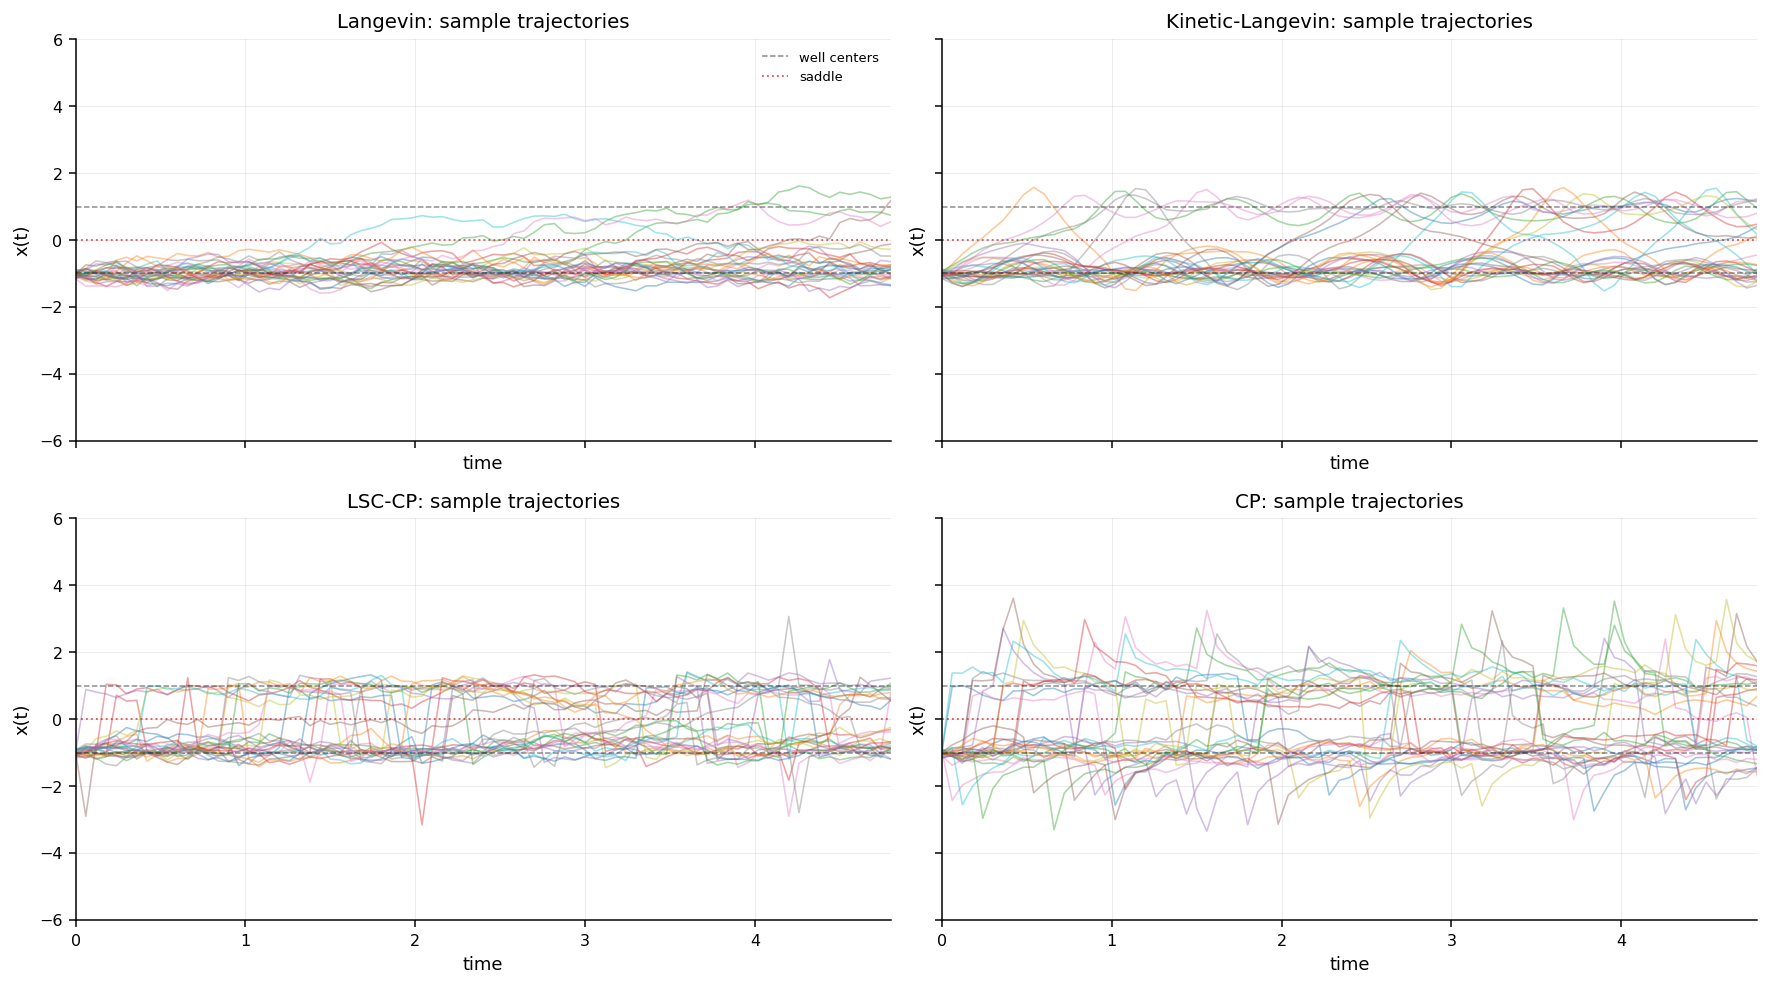

In [17]:

# Particle trajectory visualization: fixed particle indices, one representative seed.
rep_seed = sorted(metrics["seed"].unique())[0]
n_traj = 28 if PROFILE != "smoke" else 10
fig, axes = plt.subplots(2, 2, figsize=(13.2, 7.4), sharex=True, sharey=True)
axes = axes.ravel()
for ax, m in zip(axes, methods):
    run0 = next(r for r in all_runs if r["method"] == m and r["seed"] == rep_seed)
    ts = run0["times"]
    Xtraj = np.vstack(run0["samples"])  # (n_record_times, n_particles)
    ids = np.linspace(0, Xtraj.shape[1]-1, min(n_traj, Xtraj.shape[1]), dtype=int)
    for pid in ids:
        ax.plot(ts, Xtraj[:, pid], lw=0.85, alpha=0.42)
    ax.axhline(-1.0, color="k", ls="--", lw=0.8, alpha=0.45, label="well centers" if m == methods[0] else None)
    ax.axhline( 1.0, color="k", ls="--", lw=0.8, alpha=0.45)
    ax.axhline( 0.0, color="tab:red", ls=":", lw=1.0, alpha=0.75, label="saddle" if m == methods[0] else None)
    ax.set_title(f"{m}: sample trajectories")
    ax.set_xlabel("time")
    ax.set_ylabel("x(t)")
    ax.set_xlim(metrics.time.min(), metrics.time.max())
    ax.set_ylim(xlim_pdf)
    if m == methods[0]:
        ax.legend(fontsize=7, loc="upper right")
savefig(fig, FIGDIR, "fig04b_particle_trajectories")
plt.show()


## 5. Ablations: jump radius, width, and rate

,kind,value,gap,h,lam
0,radius,0.80,0.292313,0.22,1.00
1,radius,1.20,0.560931,0.22,1.00
2,radius,1.60,0.871017,0.22,1.00
3,radius,2.00,1.001094,0.22,1.00
4,radius,2.40,0.592795,0.22,1.00
5,radius,2.80,0.353941,0.22,1.00
6,radius,3.40,0.513934,0.22,1.00
7,width,0.10,1.004081,0.10,1.00
8,width,0.16,1.002743,0.16,1.00
9,width,0.22,1.001094,0.22,1.00


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig05_gap_ablations.pdf


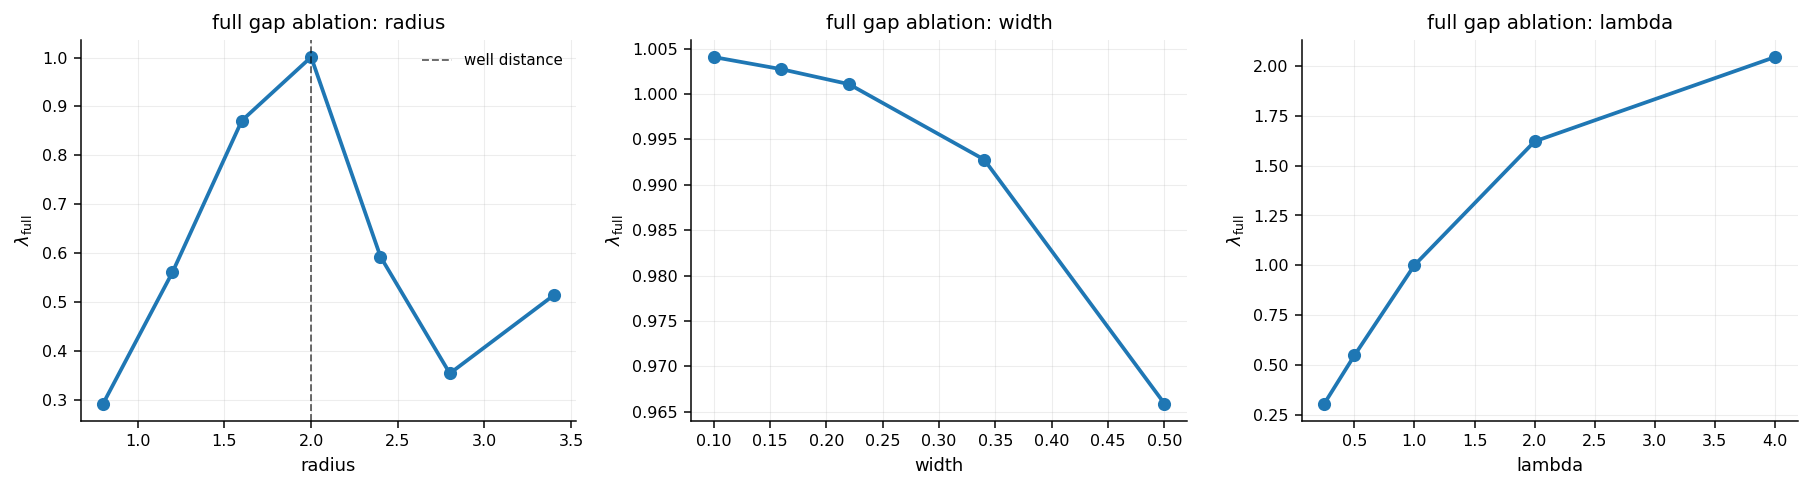

In [18]:
def terminal_mixing_time_from_metrics(metric_df, method, metric="well_TV", tol=0.05):
    sub = metric_df[metric_df.method==method].groupby("time")[metric].mean()
    below = sub[sub <= tol]
    return float(below.index[0]) if len(below) else np.nan

# Gap-only ablations are fast and directly tied to the theory.
if PROFILE == "smoke":
    radius_grid = [2.0]
    h_grid = [0.22]
    lam_grid = [1.0]
else:
    radius_grid = [0.8,1.2,1.6,2.0,2.4,2.8,3.4]
    h_grid = [0.10,0.16,0.22,0.34,0.50]
    lam_grid = [0.25,0.5,1.0,2.0,4.0]

abl_rows = []
Nabl = CFG["gap_Ns"][-1] if PROFILE!="paper" else CFG["gap_Ns"][-2]
for a in radius_grid:
    j = ShellJump1D(a=a,h=jump_main.h,lam=jump_main.lam,quad_r=CFG["quad_r"],name=f"a={a}")
    gap, diag, *_ = full_gap_1d_form(logp, eps, CFG["gap_interval"][0], CFG["gap_interval"][1], N=Nabl, jump=j)
    abl_rows.append(dict(kind="radius", value=a, gap=gap, h=j.h, lam=j.lam))
for h0 in h_grid:
    j = ShellJump1D(a=jump_main.a,h=h0,lam=jump_main.lam,quad_r=CFG["quad_r"],name=f"h={h0}")
    gap, diag, *_ = full_gap_1d_form(logp, eps, CFG["gap_interval"][0], CFG["gap_interval"][1], N=Nabl, jump=j)
    abl_rows.append(dict(kind="width", value=h0, gap=gap, h=h0, lam=j.lam))
for lam0 in lam_grid:
    j = ShellJump1D(a=jump_main.a,h=jump_main.h,lam=lam0,quad_r=CFG["quad_r"],name=f"lam={lam0}")
    gap, diag, *_ = full_gap_1d_form(logp, eps, CFG["gap_interval"][0], CFG["gap_interval"][1], N=Nabl, jump=j)
    abl_rows.append(dict(kind="lambda", value=lam0, gap=gap, h=j.h, lam=lam0))
abl = pd.DataFrame(abl_rows)
abl.to_csv(TABDIR/"doublewell_gap_ablations.csv", index=False)
display(abl)

fig, ax = plt.subplots(1,3,figsize=(13.5,3.7))
for k, kind in enumerate(["radius","width","lambda"]):
    sub=abl[abl.kind==kind].sort_values("value")
    ax[k].plot(sub.value, sub.gap, marker="o", lw=2)
    ax[k].set_title(f"full gap ablation: {kind}")
    ax[k].set_xlabel(kind)
    ax[k].set_ylabel(r"$\lambda_{\rm full}$")
    if kind=="radius":
        ax[k].axvline(2.0, color="k", ls="--", lw=1, alpha=0.6, label="well distance")
        ax[k].legend()
savefig(fig, FIGDIR, "fig05_gap_ablations")
plt.show()


## Diagnostic: jump-event geometry versus continuous trajectory interpolation

The particle trajectories connect recorded positions by straight lines, so a
line segment may visually suggest a small jump even when the actual compound
Poisson increment is large.  The following event-level diagnostic samples the
jump law directly and classifies where an ideal jump from each well center
would land.  This separates the jump mechanism from the continuous diffusion
and drift occurring between recorded times.


saved manuscript_clean_active/figures/four_experiment_release/diagnostics/doublewell_fig07_jump_event_diagnostics.pdf


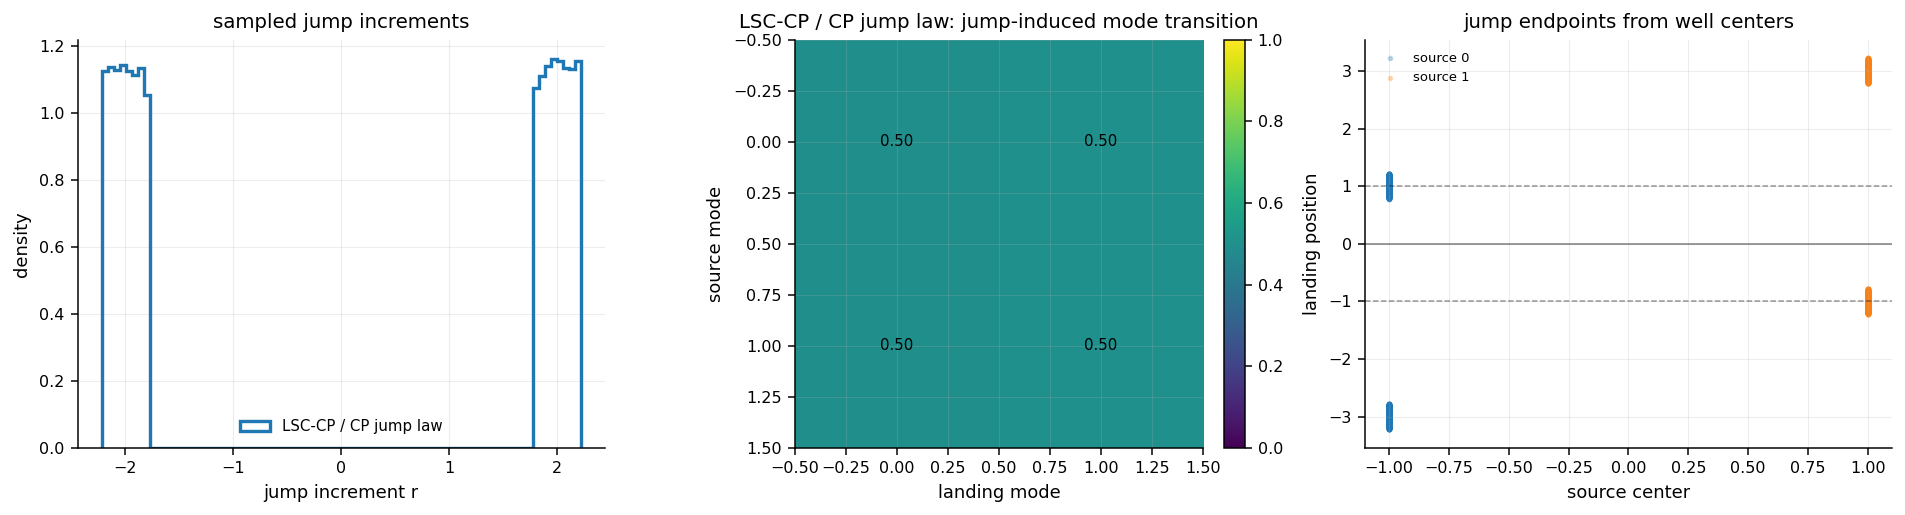

In [19]:

def jump_event_diagnostics_1d(jump_map, centers, classifier, label_prefix=''):
    rng = np.random.default_rng(GLOBAL_SEED + 8844)
    rgrid = np.linspace(-4.0, 4.0, 1000)
    fig, ax = plt.subplots(1, 3, figsize=(14.2, 3.9))
    for name, jump in jump_map.items():
        if jump is None:
            continue
        inc = jump.sample_jumps(rng, 60000 if PROFILE != 'smoke' else 5000)
        ax[0].hist(inc, bins=80, density=True, histtype='step', lw=1.8, label=name)
        trans = np.zeros((len(centers), len(centers)))
        for i, c in enumerate(centers):
            y = c + inc
            labs = classifier(y)
            for j in range(len(centers)):
                trans[i,j] = np.mean(labs == j)
        im = ax[1].imshow(trans, vmin=0, vmax=1)
        ax[1].set_title(f'{name}: jump-induced mode transition')
        ax[1].set_xlabel('landing mode'); ax[1].set_ylabel('source mode')
        for i in range(trans.shape[0]):
            for j in range(trans.shape[1]):
                ax[1].text(j, i, f'{trans[i,j]:.2f}', ha='center', va='center', fontsize=8)
        break
    ax[0].set_title('sampled jump increments')
    ax[0].set_xlabel('jump increment r'); ax[0].set_ylabel('density'); ax[0].legend(fontsize=8)
    # Endpoint scatter from centers for all jumps.
    for i, c in enumerate(centers):
        inc = list(jump_map.values())[-1].sample_jumps(rng, 1000 if PROFILE!='smoke' else 200)
        ax[2].scatter(np.full_like(inc, c), c+inc, s=4, alpha=0.25, label=f'source {i}')
    ax[2].axhline(0, color='k', lw=0.8, alpha=0.5)
    for c in centers: ax[2].axhline(c, color='k', ls='--', lw=0.8, alpha=0.4)
    ax[2].set_title('jump endpoints from well centers')
    ax[2].set_xlabel('source center'); ax[2].set_ylabel('landing position')
    ax[2].legend(fontsize=7)
    fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    try:
        fig.tight_layout()
    except Exception:
        pass
    savefig(fig, FIGDIR, f'{label_prefix}fig07_jump_event_diagnostics')
    plt.show()

jump_event_diagnostics_1d({'LSC-CP / CP jump law': jump_main}, np.array([-1.0,1.0]),
                          lambda y: (np.asarray(y) >= 0).astype(int), label_prefix='doublewell_')


## Output registry

In [20]:
# Phase17C output registry and run summary.
from datetime import datetime
import json

table_files = sorted(str(p.relative_to(PROJECT_ROOT)) for p in (RELEASE_TABLE_DIR / "01_double_well").glob("*.csv"))
figure_files = sorted(str(p.relative_to(PROJECT_ROOT)) for p in DIAGNOSTIC_FIG_DIR.glob(f"{FIG_PREFIX}*.pdf"))
registry = {
    "experiment": "1D double-well",
    "table_directory": str((RELEASE_TABLE_DIR / "01_double_well").relative_to(PROJECT_ROOT)),
    "figure_directory": str(DIAGNOSTIC_FIG_DIR.relative_to(PROJECT_ROOT)),
    "tables": table_files,
    "figures": figure_files,
    "created_utc_like": datetime.utcnow().isoformat(timespec="seconds") + "Z",
}
registry_path = RELEASE_LOG_DIR / "01_double_well_output_registry.json"
registry_path.write_text(json.dumps(registry, indent=2) + "\n", encoding="utf-8")
pd.DataFrame([{"experiment": "1D double-well", "n_tables": len(table_files), "n_figures": len(figure_files)}]).to_csv(
    RELEASE_TABLE_DIR / "01_double_well_summary.csv", index=False
)
print("Phase17C registry written:", registry_path.relative_to(PROJECT_ROOT))
print("tables:", len(table_files), "figures:", len(figure_files))


Phase17C registry written: manuscript_clean_active/numerics/four_experiment_release/logs/01_double_well_output_registry.json
tables: 31 figures: 18


In [21]:
write_reference_registry(
    SPECTRAL_REFERENCE_RECORDS,
    TABDIR / "doublewell_spectral_reference_lines.csv",
)
SCRIPTS_DIR = RELEASE_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from generate_canonical_release_figures import generate_doublewell_release
generate_doublewell_release()